Presentación en PDF del Proyecto Final: https://drive.google.com/file/d/1eZL6mZR3BeXL_byLi4z_-e1GFZwtEup0/view?usp=drive_link

# Operational performance analysis to identify ineffective operators

## Paso 1. Acceso a los datos y lectura de información general

### 1.1. Importación de librerías

Se importarán las librerías necesarias para desarrollar el análisis. Se incluirán herramientas para manipulación de datos, visualización y pruebas estadísticas. El objetivo es dejar preparado el entorno de trabajo desde el inicio para que el flujo del proyecto sea ordenado y reproducible.

In [1]:
# Carga de todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

### 1.2. Acceso a los datos

Se cargarán los archivos proporcionados y se realizará una revisión general de su contenido. Se verificará que los datasets se hayan leído correctamente y que las variables incluidas coincidan con la descripción del proyecto. Esto permitirá confirmar que se cuenta con la información necesaria para el análisis posterior.

In [2]:
# Cargamos el dataset de clientes en el DataFrame clients
clients = pd.read_csv('/datasets/telecom_clients.csv')

# Cargamos el dataset de llamadas en el DataFrame calls
calls = pd.read_csv('/datasets/telecom_dataset_us.csv')

In [3]:
# Mostramos las primeras filas del dataframe de clientes para verificar la carga correcta
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [4]:
# Mostramos las primeras filas del dataframe de llamadas para verificar la carga correcta
calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [5]:
# Revisamos el tamaño de ambos dataframes
print('Dimensiones del dataframe clients:', clients.shape)
print('Dimensiones del dataframe calls:', calls.shape)

Dimensiones del dataframe clients: (732, 3)
Dimensiones del dataframe calls: (53902, 9)


## Paso 2. Análisis exploratorio de datos (EDA)

### 2.1. Verificación de los nombres de las columnas

Se revisarán los nombres de las columnas para confirmar que sean consistentes, entendibles y adecuados para trabajar con ellas durante el análisis. Si fuera necesario, se corregirán nombres para mejorar la legibilidad del código y evitar confusiones posteriores.

In [6]:
# Mostramos información general del dataframe clients
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [7]:
# Mostramos información general del dataframe calls
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [8]:
# Mostramos estadísticas descriptivas del dataframe clients
clients.describe(include='all')

,user_id,tariff_plan,date_start
count,732.000000,732,732
unique,NaN,3,73
top,NaN,C,2019-09-24
freq,NaN,395,24
mean,167431.927596,NaN,NaN
std,633.810383,NaN,NaN
min,166373.000000,NaN,NaN
25%,166900.750000,NaN,NaN
50%,167432.000000,NaN,NaN
75%,167973.000000,NaN,NaN


In [9]:
# Mostramos estadísticas descriptivas del dataframe calls
calls.describe(include='all')

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
count,53902.000000,53902,53902,53785,45730.000000,53902,53902.000000,53902.000000,53902.000000
unique,NaN,119,2,2,NaN,2,NaN,NaN,NaN
top,NaN,2019-11-25 00:00:00+03:00,out,False,NaN,False,NaN,NaN,NaN
freq,NaN,1220,31917,47621,NaN,30334,NaN,NaN,NaN
mean,167295.344477,NaN,NaN,NaN,916535.993002,NaN,16.451245,866.684427,1157.133297
std,598.883775,NaN,NaN,NaN,21254.123136,NaN,62.917170,3731.791202,4403.468763
min,166377.000000,NaN,NaN,NaN,879896.000000,NaN,1.000000,0.000000,0.000000
25%,166782.000000,NaN,NaN,NaN,900788.000000,NaN,1.000000,0.000000,47.000000
50%,167162.000000,NaN,NaN,NaN,913938.000000,NaN,4.000000,38.000000,210.000000
75%,167819.000000,NaN,NaN,NaN,937708.000000,NaN,12.000000,572.000000,902.000000


### 2.2. Comprobación del tipo de datos y valores ausentes

#### 2.2.1. Tipos de datos

Se revisará el tipo de dato de cada columna para verificar que sea coherente con la información que representa. En caso de detectar columnas con tipos incorrectos, se realizará la conversión correspondiente para permitir un análisis adecuado.

In [10]:
# Revisamos los tipos de datos de cada columna del dataframe clients
clients.dtypes

user_id         int64
tariff_plan    object
date_start     object
dtype: object

Encontramos coherente que user_id tenga un tipo de dato int64 debido a que dicho user_id de los clientes posee sólo valores numéricos enteros.

In [11]:
# Revisamos los nombres de los planes tarifarios de los clientes
clients['tariff_plan'].unique()

array(['A', 'C', 'B'], dtype=object)

Existen sólo 3 planes tarifarios para clientes, los cuales son identificados por una letra en específico; por lo que es coherente que tariff_plan tenga una asignación de object como tipo de dato.

A continuación, vemos que la columna date_start posee la fecha de inicio del plan tarifario de cada cliente, por lo que debería tener un tipo de dato temporal; el cual será diferente del tipo de dato actual object asignado.

In [12]:
# Convertimos la columna de fecha al formato datetime en el dataframe clients
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Verificamos el cambio realizado sobre los tipos de datos de cada columna del dataframe clients
clients.dtypes

user_id                 int64
tariff_plan            object
date_start     datetime64[ns]
dtype: object

In [13]:
# Revisamos los tipos de datos de cada columna del dataframe calls
calls.dtypes

user_id                  int64
date                    object
direction               object
internal                object
operator_id            float64
is_missed_call            bool
calls_count              int64
call_duration            int64
total_call_duration      int64
dtype: object

Encontramos coherente que user_id tenga un tipo de dato int64 debido a que dicho user_id de los clientes posee sólo valores numéricos enteros.

A continuación, encontramos que la columna date posee la fecha del registro de cada llamada, por lo que debería tener un tipo de dato temporal, el cual será diferente del tipo de dato actual object asignado. Recordemos que se observó la descripción de la zona horaria para la columna date del dataframe calls, lo cual podría generar conflicto cuando se ejecuten algunos códigos para análisis temporales; y dado que no es alcance del proyecto cruzar información temporal de diferentes zonas horarias (análisis horario cruzado) ni se está comparando timestamps exactos entre tablas; es decir, nos limitaremos a trabajar a nivel de día, semana y mes.

In [14]:
# Convertimos la columna de fecha al formato datetime en el dataframe calls
calls['date'] = pd.to_datetime(calls['date']).dt.tz_localize(None)

# Verificamos el cambio realizado sobre los tipos de datos de cada columna del dataframe calls
calls.dtypes

user_id                         int64
date                   datetime64[ns]
direction                      object
internal                       object
operator_id                   float64
is_missed_call                   bool
calls_count                     int64
call_duration                   int64
total_call_duration             int64
dtype: object

In [15]:
# Revisamos los nombres de las direcciones (planteado como o entrada o salida) del dataframe calls
calls['direction'].unique()

array(['in', 'out'], dtype=object)

Además de verificar que sólo existen 2 posibles nombres para la dirección de la llamada ('in' para entrante y 'out' para saliente), encontramos que son compatibles con el tipo de dato asignado.

In [16]:
# Revisamos los nombres de la columna internal del dataframe calls
calls['internal'].unique()

array([False, True, nan], dtype=object)

Encontramos que la columna internal posee la veracidad o falsedad sobre si la llamada fue interna; por lo que dicha columna debería tener una asignación de tipo de dato booleano en lugar de uno general tipo object.

In [17]:
# Visualizamos la cantidad de llamadas externas (internal = False) e internas (internal = True)
calls.groupby('internal')['user_id'].count()

internal
False    47621
True      6164
Name: user_id, dtype: int64

In [18]:
# Cuantificamos la cantidad de valores nulos en la columna internal del dataframe calls
len(calls[calls['internal'].isna()])

117

In [19]:
# Visualizamos 15 filas el dataframe calls donde la columna internal tenga valores nulos NaN para encontrar alguna relación respecto alguna otra columna 
calls[calls['internal'].isna()].head(15)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1007,166405,2019-09-18,in,NaN,NaN,True,1,0,59
1090,166405,2019-10-01,in,NaN,NaN,True,1,0,1
1864,166406,2019-08-20,in,NaN,NaN,True,1,0,36
1924,166406,2019-09-02,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26,in,NaN,908960.0,False,1,393,423
6216,166541,2019-09-26,in,NaN,908958.0,False,2,547,612
7523,166604,2019-10-31,in,NaN,NaN,True,1,0,5
7528,166604,2019-11-01,in,NaN,893402.0,False,1,94,117
8650,166658,2019-09-24,in,NaN,890404.0,False,1,150,157
9080,166658,2019-10-15,in,NaN,890404.0,False,1,51,57


Hemos encontrado que la mayoría de llamadas son externas en el dataframe calls (internal= False), por lo que es más posible que las filas donde la columna internal tiene valores nulos NaN hayan sido llamadas externas (internal = False) ya que proporcionalmente hay más llamadas externas que internas; además de que es lógico que existan más casos donde los clientes hayan intentado contactarse con los operadores respecto de los casos donde los operadores intentaron comunicarse entre sí.

Sin embargo, esta aseveración es una posibilidad mas no una verdad absoluta, por lo que se considera más adecuado asignar un tipo de dato boolean que permita conservar valores nulos en dichas filas para la columna internal debido a la falta de certeza (y así evitar posibles sesgos en el análisis). Observar también que la cantidad de registros con valores nulos para internal es sólo 117 respecto de las 53901 filas del dataframe de calls, lo cual representa menos del 1 % (0.22 % para ser más preciso), por lo que la decisión de mantener los valores nulos (para evitar un sesgo accidental) no tendrá un impacto apreciable en los resultados.

In [20]:
# Convertimos la columna de internal al formato boolean en el dataframe calls
calls['internal'] = calls['internal'].astype("boolean")

# Verificamos el cambio realizado sobre los tipos de datos de cada columna del dataframe calls
calls.dtypes

user_id                         int64
date                   datetime64[ns]
direction                      object
internal                      boolean
operator_id                   float64
is_missed_call                   bool
calls_count                     int64
call_duration                   int64
total_call_duration             int64
dtype: object

A continuación, encontramos peculiar que la columna operator_id tenga un tipo de dato float64 en lugar de int64, estudiamos a continuación el motivo de dicha asignación.

In [21]:
# Filtramos filas del dataframe calls donde operator_id no sea un número entero y obtenemos dichos valores que no sean números enteros 
calls['operator_id'][calls['operator_id'] % 1 != 0].unique()

array([nan])

Encontramos que todos los valores de la columna operator_id del dataframe calls tienen valores numéricos enteros, con excepción de los valores nulos NaN, motivo por el cual se asignó automáticamente float64 como tipo de dato a dicha columna, ya que int64 no puede almacenar valores nulos NaN. Se puede optar por cambiar al tipo de dato Int64 de pandas que sí puede almacenar valores nulos NaN y permitirá tener claridad sobre la naturaleza estándar de los datos dicha columna (números enteros).

In [22]:
# Convertimos la columna de internal al formato boolean en el dataframe calls
calls['operator_id'] = calls['operator_id'].astype("Int64")

# Verificamos el cambio realizado sobre los tipos de datos de cada columna del dataframe calls
calls.dtypes

user_id                         int64
date                   datetime64[ns]
direction                      object
internal                      boolean
operator_id                     Int64
is_missed_call                   bool
calls_count                     int64
call_duration                   int64
total_call_duration             int64
dtype: object

A continuación, verificamos si es adecuado la asignación del tipo de dato bool a la columna is_missed_call.

In [23]:
# Revisamos los nombres de la columna is_missed_call del dataframe calls
calls['is_missed_call'].unique()

array([ True, False])

Encontramos que sólo existen valores de veracidad o falsedad en la columna is_missed_call del dataframe calls, por lo que se considera adecuado la asignación de dicho tipo de dato bool. 

A continuación, ya que calls_count, call_duration y total_call_duration contienen la cantidad de llamadas, duración de la llamada (sin incluir tiempo de espera) y duración de la llamada (incluido el tiempo de espera), encontramos coherente que las 3 columnas tengan asignado el tipo de dato int64 (número entero).

Finalmente, se verificará también que no existan casos donde:
- Se haya perdido la llamada y exista una cantidad mayor a cero de duración de la llamada (sin incluir el tiempo de espera)
- No se haya perdido la llamada y exista una cantidad igual a cero de duración de la llamada (sin incluir el tiempo de espera)

In [24]:
# Calculamos la cantidad de casos donde se ha perdido la llamada pero se haya registrado una cantidad no nula de tiempo en la llamada
len(calls[(calls['is_missed_call'] == True) & (calls['call_duration'] > 0)])

325

In [25]:
# Calculamos la cantidad de casos donde no se ha perdido la llamada pero se haya registrado una cantidad nula de tiempo en la llamada
len(calls[(calls['is_missed_call'] == False) & (calls['call_duration'] == 0)])

20

En ambos casos estamos encontrando inconsistencias entre la veracidad sobre si la llamada no fue atendida respecto de la duración que conceptualmente debería tener:
- Duración mayor a cero si la llamada no fue perdida (296 casos)
- Duración igual a cero si la llamada sí fue perdida (17 casos)

Lo primero podría deberse a particularidades operativas del sistema telefónico, como conexiones parciales o llamadas abandonadas después de iniciarse. Dado que no existe evidencia suficiente para asumir un error de registro, estos casos fueron conservados en el análisis.

Lo segundo sí podría haber ocurrido por un error en el registro de atención de la llamada; sin embargo, debido a que estos casos representan una proporción mínima del total de registros, se decidió conservarlos para evitar alterar los datos originales del sistema.

#### 2.2.2. Valores duplicados

Se identificarán registros duplicados para evaluar si representan observaciones repetidas de manera incorrecta. Si se detectan duplicados que no aporten información adicional, se eliminarán para evitar distorsiones en los resultados.

In [26]:
# Calculamos la cantidad de filas duplicadas explícitas en el dataframe clients
clients.duplicated().sum()

0

In [27]:
# Verificamos que los usuarios del dataframe clients no tengan registro repetido
print("Cantidad de clientes", len(clients))
print("Cantidad de clientes únicos", clients['user_id'].nunique())

Cantidad de clientes 732
Cantidad de clientes únicos 732


No existen duplicados explícitos en el registro de los clientes en el dataframe clients

In [28]:
# Calculamos la cantidad de filas duplicadas explícitas en el dataframe calls
calls.duplicated().sum()

4900

In [29]:
# Mostramos ejemplos de filas duplicadas en el dataframe calls en caso existan
calls[calls.duplicated()].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05,out,False,880020,True,8,0,50
28,166377,2019-08-12,in,False,<NA>,True,2,0,34
44,166377,2019-08-14,out,False,880026,False,10,1567,1654
45,166377,2019-08-14,in,False,<NA>,True,1,0,3
51,166377,2019-08-15,out,False,880026,False,11,1413,1473


Se identificaron 4900 filas duplicadas explícitas en el dataframe calls. Dado que el dataframe contiene 9 columnas y los registros duplicados coinciden exactamente en todos sus valores, se considera poco probable que representen llamadas distintas registradas con la misma información. Por ello, se decidió eliminar estos duplicados para evitar sobreestimar métricas como número de llamadas, duración total, llamadas perdidas y tiempos de espera.

In [30]:
# Eliminamos filas duplicadas explícitas del dataframe calls por coincidir en todas las columnas y así evitar sobreestimar las métricas de llamadas
calls = calls.drop_duplicates().reset_index(drop = True)

In [31]:
# Verificamos que la cantidad de filas duplicadas explícitas en el dataframe calls sea nula
calls.duplicated().sum()

0

In [32]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              49002 non-null  int64         
 1   date                 49002 non-null  datetime64[ns]
 2   direction            49002 non-null  object        
 3   internal             48892 non-null  boolean       
 4   operator_id          41546 non-null  Int64         
 5   is_missed_call       49002 non-null  bool          
 6   calls_count          49002 non-null  int64         
 7   call_duration        49002 non-null  int64         
 8   total_call_duration  49002 non-null  int64         
dtypes: Int64(1), bool(1), boolean(1), datetime64[ns](1), int64(4), object(1)
memory usage: 2.8+ MB


#### 2.2.3. Valores ausentes

Se revisará la presencia de valores ausentes en cada variable. Si existen, se evaluará su magnitud y relevancia para decidir si conviene eliminarlos, mantenerlos o tratarlos de alguna forma específica, siempre considerando el impacto que podrían tener en el análisis.

In [33]:
# Calculamos la cantidad de valores ausentes por columna en el dataframe clients
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

No hemos encontrado valores nulos en ninguna de las columnas del dataframe clients por tratar.

In [34]:
# Calculamos la cantidad de valores ausentes por columna en el dataframe calls
calls.isna().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [35]:
# Visualizamos la cantidad de llamadas externas (internal = False) e internas (internal = True)
calls.groupby('internal')['user_id'].count()

internal
False    43239
True      5653
Name: user_id, dtype: int64

In [36]:
# Cuantificamos la cantidad de valores nulos en la columna internal del dataframe calls
len(calls[calls['internal'].isna()])

110

In [37]:
# Revisamos las filas donde internal del dataframe calls es nulo
calls[calls['internal'].isna()].head(15)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18,in,<NA>,<NA>,True,1,0,59
996,166405,2019-10-01,in,<NA>,<NA>,True,1,0,1
1705,166406,2019-08-20,in,<NA>,<NA>,True,1,0,36
1761,166406,2019-09-02,in,<NA>,879898,False,1,2,9
5645,166541,2019-09-26,in,<NA>,908960,False,1,393,423
5651,166541,2019-09-26,in,<NA>,908958,False,2,547,612
6841,166604,2019-10-31,in,<NA>,<NA>,True,1,0,5
6846,166604,2019-11-01,in,<NA>,893402,False,1,94,117
7862,166658,2019-09-24,in,<NA>,890404,False,1,150,157
8245,166658,2019-10-15,in,<NA>,890404,False,1,51,57


Luego de la eliminación de duplicados explícitos, hemos encontrado y vuelto a verificar que la mayoría de llamadas son externas en el dataframe calls (internal= False), por lo que es más posible que las filas donde la columna internal tiene valores nulos NaN hayan sido llamadas externas (internal = False) ya que proporcionalmente hay más llamadas externas que internas; además de que es lógico que existan más casos donde los clientes hayan intentado contactarse con los operadores respecto de los casos donde los operadores intentaron comunicarse entre sí.

Sin embargo, esta aseveración es una posibilidad mas no una verdad absoluta, por lo que se considera más adecuado asignar un tipo de dato boolean que permita conservar valores nulos en dichas filas para la columna internal debido a la falta de certeza (y así evitar posibles sesgos en el análisis). Observar también que la cantidad de registros con valores nulos para internal es sólo 110 respecto de las 49002 filas del dataframe de calls, lo cual representa menos del 1 % (0.22 % para ser más preciso), por lo que la decisión de mantener los valores nulos (para evitar un sesgo accidental) no tendrá un impacto apreciable en los resultados.

In [38]:
# Revisamos las filas donde operator_id del dataframe calls es nulo
calls[calls['operator_id'].isna()].head(15)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,<NA>,True,2,0,4
7,166377,2019-08-05,in,False,<NA>,True,6,0,35
8,166377,2019-08-06,in,False,<NA>,True,4,0,62
16,166377,2019-08-07,in,False,<NA>,True,2,0,24
26,166377,2019-08-12,in,False,<NA>,True,2,0,34
28,166377,2019-08-13,in,False,<NA>,True,7,0,128
36,166377,2019-08-14,in,False,<NA>,True,1,0,3
71,166377,2019-08-22,in,False,<NA>,True,1,0,1
74,166377,2019-08-23,in,False,<NA>,True,2,0,47
79,166377,2019-08-24,in,False,<NA>,True,2,0,35


A primera vista pareciera que el valor de la columna operator_id es nulo sólo cuando:
- La llamada fue recibida (direction = in)
- La llamada fue externa (internal = False)
- La llamada no fue atendida (is_missed_call = True)

Se procederá a verificar si los casos contrarios existen en el dataframe calls para descartar o confirmar la relación de dichas columnas con la columna operator_id (en los casos de valores nulos NaN para ´la última mencionada).

In [39]:
# Verificando la cantidad de filas donde operator_id es nulo y direction es out
len(calls[(calls['direction'] == "out") & (calls['operator_id'].isna())])

186

In [40]:
# Verificando la cantidad de filas donde operator_id es nulo e internal es True
len(calls[(calls['internal'] == True) & (calls['operator_id'].isna())])

323

In [41]:
# Verificando la cantidad de filas donde operator_id es nulo e is_missed_call es True
len(calls[(calls['is_missed_call'] == True) & (calls['operator_id'].isna())])

7343

Hemos descartado las 3 posibles asunciones de relación entre la columna operator_id (cuando posee valores nulos); por lo tanto, no hay una dirección directa entre dichas columnas con estos registros específicos (filas donde operator_id posee valor nulo). Podría optarse por eliminar dichas filas al carecer de información específica de los operadores; pero:
- Se eliminarían 7456 registros del total de 49002 (15% aproximadamente)
- Dichas filas poseen información relevante como clientes atendidos, llamadas realizadas, duración de llamadas, etc., por lo que aún contienen datos que pueden usarse para otros alcances del presente análisis.

Por lo tanto, se optará por no eliminar dichos registros ni estimar quién fue el operador relacionado con dicha llamada (ya que no se tendría certeza de ello y se podría generar un sesgo si se intentase estimar equívocamente); pero sí serán reemplazados por "unknown" para efectos de los siguientes análisis. Se sabe que ello cambiará el tipo de dato de dicha columna a object, lo cual no generará inconveniente ya que no se realizarán cálculos numéricos con los valores del id de los operadores.

In [42]:
# Se retorna el tipo de dato object para operator_id
calls['operator_id'] = calls['operator_id'].astype("object")

# Se procede a cambiar los valores nulos de operator_id a "unknown"
calls['operator_id'] = calls['operator_id'].fillna('unknown')

In [43]:
# Verificamos la cantidad de valores ausentes por columna en el dataframe calls (luego de los cambios realizados)
calls.isna().sum()

user_id                  0
date                     0
direction                0
internal               110
operator_id              0
is_missed_call           0
calls_count              0
call_duration            0
total_call_duration      0
dtype: int64

### 2.3. Conversión de fechas

Se transformarán las variables temporales al formato de fecha adecuado. Esto permitirá trabajar correctamente con periodos, ordenar cronológicamente la información y realizar análisis temporales si fueran necesarios.

In [44]:
# Verificamos nuevamente los tipos de datos temporales en ambos dataframes
print('Tipo de dato de date en calls:', calls['date'].dtype)
print('Tipo de dato de date_start en clients:', clients['date_start'].dtype)

Tipo de dato de date en calls: datetime64[ns]
Tipo de dato de date_start en clients: datetime64[ns]


Ambas columnas de fechas de sus respectivas tablas poseen un tipo de dato temporal.

In [45]:
# Revisamos el rango temporal del dataframe calls
print('Fecha mínima en calls:', calls['date'].min())
print('Fecha máxima en calls:', calls['date'].max())

Fecha mínima en calls: 2019-08-02 00:00:00
Fecha máxima en calls: 2019-11-28 00:00:00


In [46]:
# Revisamos el rango temporal del dataframe clients
print('Fecha mínima en clients:', clients['date_start'].min())
print('Fecha máxima en clients:', clients['date_start'].max())

Fecha mínima en clients: 2019-08-01 00:00:00
Fecha máxima en clients: 2019-10-31 00:00:00


Encontramos que el tramo temporal del dataframe clients es ligeramente anterior al tramo temporal de calls, probablemente para asegurarse de que el registro de las llamadas de los clientes de interés para el análisis haya podido ser registrado en la tabla de calls.

In [47]:
# Creamos columnas temporales adicionales para futuros análisis por semana y mes
calls['call_week'] = calls['date'].dt.to_period('W').astype(str)
calls['call_month'] = calls['date'].dt.to_period('M').astype(str)

In [48]:
# Creamos columnas temporales en clients para analizar la antigüedad o fecha de registro de clientes
clients['start_month'] = clients['date_start'].dt.to_period('M').astype(str)

In [49]:
# Verificamos las primeras filas de calls con las nuevas variables temporales
calls[['date', 'call_week', 'call_month']].head()

,date,call_week,call_month
0,2019-08-04,2019-07-29/2019-08-04,2019-08
1,2019-08-05,2019-08-05/2019-08-11,2019-08
2,2019-08-05,2019-08-05/2019-08-11,2019-08
3,2019-08-05,2019-08-05/2019-08-11,2019-08
4,2019-08-05,2019-08-05/2019-08-11,2019-08


In [50]:
# Verificamos las primeras filas de clients con las nuevas variables temporales
clients[['date_start', 'start_month']].head()

,date_start,start_month
0,2019-08-15,2019-08
1,2019-08-23,2019-08
2,2019-10-29,2019-10
3,2019-09-01,2019-09
4,2019-10-16,2019-10


### 2.4. Creación de nuevas variables

#### 2.4.1. Tiempo de espera

Se calculará una variable que represente el tiempo de espera de las llamadas, obtenida a partir de la diferencia entre la duración total y la efectiva. Esta métrica será importante porque el objetivo del proyecto considera el tiempo de espera como uno de los indicadores de ineficiencia.

In [51]:
# Calculamos el tiempo total de espera como diferencia entre duración total y duración efectiva de la llamada
calls['waiting_time'] = calls['total_call_duration'] - calls['call_duration']

In [52]:
# Verificamos si existen tiempos de espera negativos, lo cual indicaría una inconsistencia en los datos
calls[calls['waiting_time'] < 0]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,call_week,call_month,waiting_time


No se han encontrado casos donde el tiempo de duración total de la llamada sea menor que la duración de la llamada.

In [53]:
# Calculamos el tiempo promedio de espera por llamada dentro de cada registro
calls['avg_waiting_time_per_call'] = calls['waiting_time'] / calls['calls_count']

In [54]:
# Revisamos estadísticas descriptivas de las nuevas variables de tiempo de espera
calls[['waiting_time', 'avg_waiting_time_per_call']].describe()

,waiting_time,avg_waiting_time_per_call
count,49002.000000,49002.000000
mean,290.276111,16.828400
std,1132.155291,13.878241
min,0.000000,0.000000
25%,17.000000,8.000000
50%,55.000000,14.500000
75%,200.000000,22.250000
max,46474.000000,465.000000


#### 2.4.2. Tasa de llamadas perdidas

Se construirá una métrica que permita medir la proporción de llamadas perdidas respecto al total de llamadas atendidas de cada operador o conjunto de operadores. Esta variable facilitará la comparación del desempeño entre operadores.

In [55]:
# Creamos una columna con la cantidad de llamadas perdidas por registro, si is_missed_call es True, todas las llamadas del registro se consideran perdidas
# Si is_missed_call es False, la cantidad de llamadas perdidas será cero
calls['missed_calls_count'] = np.where(calls['is_missed_call'] == True, calls['calls_count'], 0)

# Creamos una columna con la cantidad de llamadas no perdidas por registro
calls['answered_calls_count'] = np.where(calls['is_missed_call'] == False, calls['calls_count'], 0)

In [56]:
# Verificamos que la suma de llamadas perdidas y no perdidas coincida con calls_count
calls['check_calls_count'] = calls['missed_calls_count'] + calls['answered_calls_count']

# Mostramos registros donde la verificación no se cumple
calls[calls['check_calls_count'] != calls['calls_count']]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,call_week,call_month,waiting_time,avg_waiting_time_per_call,missed_calls_count,answered_calls_count,check_calls_count


No se encuentran casos donde no cumpla la verificación en la que calls_count coincida con check_calls_count

In [57]:
# Eliminamos la columna auxiliar de verificación porque ya no será necesaria
calls = calls.drop(columns='check_calls_count')

In [58]:
# Calculamos métricas generales de llamadas perdidas en todo el dataframe calls
total_calls = calls['calls_count'].sum()
total_missed_calls = calls['missed_calls_count'].sum()

general_missed_rate = total_missed_calls / total_calls

print('Total de llamadas:', total_calls)
print('Total de llamadas perdidas:', total_missed_calls)
print('Tasa general de llamadas perdidas:', round(general_missed_rate, 4))

Total de llamadas: 806709
Total de llamadas perdidas: 375918
Tasa general de llamadas perdidas: 0.466


La cantidad de llamadas perdidas representa un poco menos de la mitad de las llamadas ejecutadas en el registro general.

#### 2.4.3. Promedios por operador

Se generarán métricas promedio y agregadas a nivel de operador, como duración media de llamadas, tiempo medio de espera y volumen total de actividad. Esto servirá para construir una base de comparación entre operadores y detectar patrones de desempeño.

In [59]:
# Creamos una tabla agregada por operador incluyendo también los registros sin operador identificado
operator_metrics_all = (
    calls
    .groupby('operator_id')
    .agg(
        total_records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        answered_calls=('answered_calls_count', 'sum'),
        effective_call_duration=('call_duration', 'sum'),
        total_duration_with_wait=('total_call_duration', 'sum'),
        total_waiting_time=('waiting_time', 'sum'),
        avg_waiting_time_per_record=('waiting_time', 'mean'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean')
    ).reset_index())

In [60]:
# Calculamos la tasa de llamadas perdidas por operador
operator_metrics_all['missed_rate'] = (
    operator_metrics_all['missed_calls'] / operator_metrics_all['total_calls'])

# Calculamos la duración promedio efectiva por llamada
operator_metrics_all['avg_effective_call_duration_per_call'] = (
    operator_metrics_all['effective_call_duration'] / operator_metrics_all['total_calls'])

# Calculamos la duración promedio total por llamada, incluyendo tiempo de espera
operator_metrics_all['avg_total_duration_per_call'] = (
    operator_metrics_all['total_duration_with_wait'] / operator_metrics_all['total_calls'])

# Visualizamos las primeras filas de la tabla agregada por operador
operator_metrics_all.head()

,operator_id,total_records,total_calls,missed_calls,answered_calls,effective_call_duration,total_duration_with_wait,total_waiting_time,avg_waiting_time_per_record,avg_waiting_time_per_call,missed_rate,avg_effective_call_duration_per_call,avg_total_duration_per_call
0,879896,117,930,251,679,63862,76137,12275,104.914530,15.453409,0.269892,68.668817,81.867742
1,879898,227,7313,2360,4953,257391,361288,103897,457.696035,14.720197,0.322713,35.196363,49.403528
2,880020,20,45,22,23,2245,2525,280,14.000000,5.940000,0.488889,49.888889,56.111111
3,880022,70,197,105,92,15147,18925,3778,53.971429,13.987282,0.532995,76.888325,96.065990
4,880026,182,2232,648,1584,153326,175526,22200,121.978022,11.811898,0.290323,68.694444,78.640681


In [61]:
# Creamos una tabla específica para operadores reales, excluyendo los registros sin operador identificado
operator_metrics = operator_metrics_all[
    operator_metrics_all['operator_id'] != 'unknown'].copy()

# Revisamos las dimensiones de ambas tablas agregadas
print('Cantidad de operadores incluyendo unknown:', operator_metrics_all.shape[0])
print('Cantidad de operadores reales:', operator_metrics.shape[0])

Cantidad de operadores incluyendo unknown: 1093
Cantidad de operadores reales: 1092


Se ha verificado que difiere en 1 la cantidad de filas entre la tabla que considera a los operadores unknown respecto de la tabla que no lo considera.

In [62]:
# Revisamos estadísticas generales de las métricas por operador real
operator_metrics.describe()

,total_records,total_calls,missed_calls,answered_calls,effective_call_duration,total_duration_with_wait,total_waiting_time,avg_waiting_time_per_record,avg_waiting_time_per_call,missed_rate,avg_effective_call_duration_per_call,avg_total_duration_per_call
count,1092.000000,1092.000000,1092.000000,1092.000000,1.092000e+03,1.092000e+03,1.092000e+03,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000
mean,38.045788,642.989927,249.376374,393.613553,3.841746e+04,5.028104e+04,1.186358e+04,216.086098,16.571305,0.290822,74.084447,90.554013
std,49.206403,2889.666021,1276.239522,1694.059254,1.768318e+05,2.391585e+05,6.451050e+04,506.996689,7.969025,0.247096,78.751954,79.906676
min,1.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,10.000000,1.000000,7.000000,4.260000e+02,5.680000e+02,1.387500e+02,23.000000,11.859224,0.063497,31.189115,47.879187
50%,19.000000,72.000000,14.000000,49.000000,5.473500e+03,6.674500e+03,1.008000e+03,46.619048,15.788889,0.276480,59.250624,77.415546
75%,50.000000,493.750000,135.000000,356.750000,3.384075e+04,4.385675e+04,7.692250e+03,159.758929,20.003692,0.430864,92.831595,109.559019
max,323.000000,60221.000000,23807.000000,36414.000000,4.363953e+06,5.733237e+06,1.443002e+06,5805.027397,62.000000,1.000000,1306.000000,1338.000000


### 2.5. Descripción de los datos

#### 2.5.1. Análisis a nivel general

Se describirá el comportamiento general del servicio de telefonía en términos de volumen de llamadas, número de operadores y número de clientes. El objetivo es comprender la dimensión del problema antes de pasar a un análisis más detallado.

##### 2.5.1.1. Voluman de llamadas

Se analizará la cantidad total de llamadas registradas, observando su magnitud general y la posible distribución entre llamadas entrantes y salientes. Esto ayudará a entender la carga operativa del sistema.

In [63]:
# Calculamos métricas generales del volumen de llamadas
total_records = len(calls)
total_calls = calls['calls_count'].sum()
total_missed_calls = calls['missed_calls_count'].sum()
total_answered_calls = calls['answered_calls_count'].sum()

print('Total de registros:', total_records)
print('Total de llamadas:', total_calls)
print('Total de llamadas perdidas:', total_missed_calls)
print('Total de llamadas no perdidas:', total_answered_calls)
print('Tasa general de llamadas perdidas:', round(total_missed_calls / total_calls, 4))

Total de registros: 49002
Total de llamadas: 806709
Total de llamadas perdidas: 375918
Total de llamadas no perdidas: 430791
Tasa general de llamadas perdidas: 0.466


In [64]:
# Agrupamos el volumen de llamadas por día para analizar la evolución temporal de la actividad
calls_by_day = (
    calls
    .groupby('date')
    .agg(
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        answered_calls=('answered_calls_count', 'sum')
    ).reset_index())

calls_by_day.head()

,date,total_calls,missed_calls,answered_calls
0,2019-08-02,21,15,6
1,2019-08-03,29,10,19
2,2019-08-04,6,5,1
3,2019-08-05,192,56,136
4,2019-08-06,229,94,135


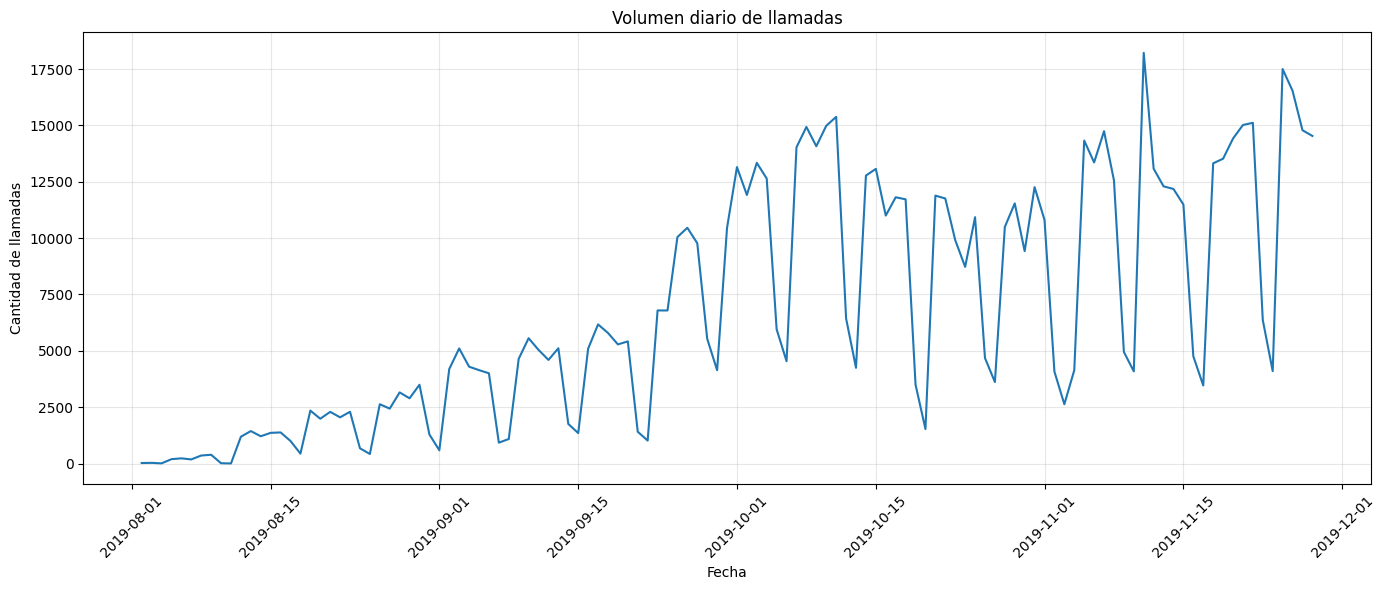

In [65]:
# Visualizamos el volumen total de llamadas por día
plt.figure(figsize=(14, 6))
sns.lineplot(data=calls_by_day, x='date', y='total_calls')

plt.title('Volumen diario de llamadas')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de llamadas')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En general se encuentra una tendencia ascendente en la cantidad de llamadas respecto del tiempo; sin embargo, se presenta una cantidad apreciable de fechas donde dicha cantidad cae fuertemente para luego reponerse a la tendencia general.

##### 2.5.1.2. Distribución de operadores

Se analizará cuántos operadores participan en el servicio y cómo se distribuye la actividad entre ellos. Esto permitirá detectar si la carga de trabajo está equilibrada o concentrada en pocos operadores.

In [66]:
# Calculamos la cantidad de operadores registrados, incluyendo y excluyendo el valor unknown
total_operators_all = calls['operator_id'].nunique()
total_operators_real = calls[calls['operator_id'] != 'unknown']['operator_id'].nunique()

print('Cantidad de operadores incluyendo unknown:', total_operators_all)
print('Cantidad de operadores reales:', total_operators_real)

Cantidad de operadores incluyendo unknown: 1093
Cantidad de operadores reales: 1092


In [67]:
# Calculamos la cantidad de registros y llamadas asociadas a operadores identificados y no identificados
operator_identification_summary = (
    calls
    .assign(operator_status=np.where(calls['operator_id'] == 'unknown', 'unknown', 'identified'))
    .groupby('operator_status')
    .agg(
        records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum')
    ).reset_index())

operator_identification_summary

,operator_status,records,total_calls,missed_calls
0,identified,41546,702145,272319
1,unknown,7456,104564,103599


Se encuentra, porcentualmente, relativamente baja la cantidad de operadores con identificación desconocida, los cuales tienen una cantidad de llamadas perdidas casi idéntica al total de llamadas que han realizado, lo cual podría sugerir una posible conexión entre la no identificación del operador y la llamada no atendida.

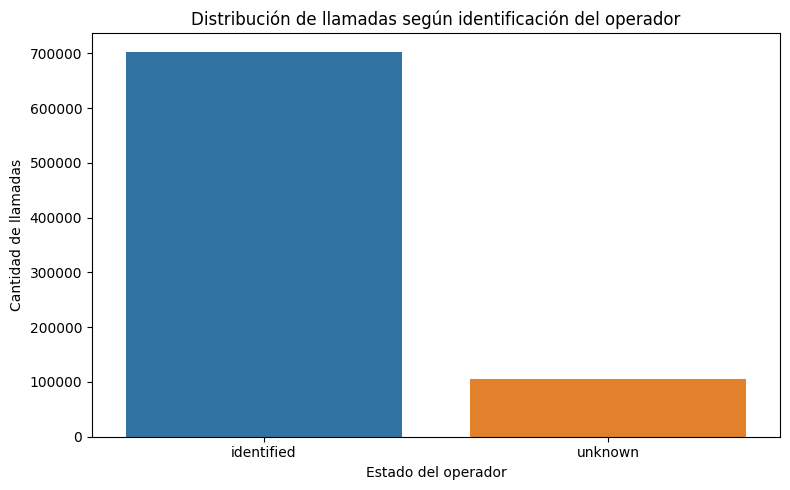

In [68]:
# Visualizamos la distribución de llamadas entre operadores identificados y registros sin operador
plt.figure(figsize=(8, 5))
sns.barplot(data=operator_identification_summary, x='operator_status', y='total_calls')

plt.title('Distribución de llamadas según identificación del operador')
plt.xlabel('Estado del operador')
plt.ylabel('Cantidad de llamadas')
plt.tight_layout()
plt.show()

Se aprecia que el volumen de llamadas reside principalmente en los operadores identificados; a pesar de que el volumen de llamadas de los operadores no identificados supera ligeramente el valor de 100000.

##### 2.5.1.3. Distribución de clientes

Se estudiará la cantidad de clientes y cómo se distribuyen las llamadas entre ellos. El objetivo es identificar si existen clientes que generan mayor volumen y que podrían influir fuertemente en el desempeño observado.

In [69]:
# Calculamos la cantidad de clientes únicos en ambos dataframes
clients_unique = clients['user_id'].nunique()
calls_clients_unique = calls['user_id'].nunique()

print('Clientes únicos en clients:', clients_unique)
print('Clientes únicos en calls:', calls_clients_unique)

Clientes únicos en clients: 732
Clientes únicos en calls: 307


Encontramos que menos de la mitad de los clientes registrados en el dataframe clients han sido encontrados en los registros del dataframe calls; lo cual sugiere que no todos los clientes que contrataron algún plan (A, B o C) usan necesariamente el servicio (o al menos durante el tramo temporal de la información disponible).

In [70]:
# Calculamos el volumen de llamadas por cliente
calls_by_client = (
    calls
    .groupby('user_id')
    .agg(
        total_records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean')
    ).reset_index())

calls_by_client.head()

,user_id,total_records,total_calls,missed_calls,avg_waiting_time_per_call
0,166377,519,5149,1880,13.817241
1,166391,20,27,21,20.508333
2,166392,93,209,107,19.424851
3,166399,20,24,11,23.925000
4,166405,962,17536,8900,19.162654


In [71]:
# Revisamos estadísticas descriptivas del volumen de llamadas por cliente
calls_by_client[['total_records', 'total_calls', 'missed_calls', 'avg_waiting_time_per_call']].describe()

,total_records,total_calls,missed_calls,avg_waiting_time_per_call
count,307.000000,307.000000,307.000000,307.000000
mean,159.615635,2627.716612,1224.488599,14.558620
std,274.479476,11463.942823,5732.911112,6.407631
min,1.000000,1.000000,0.000000,0.000000
25%,20.000000,43.000000,22.000000,10.864834
50%,61.000000,211.000000,90.000000,15.168260
75%,183.000000,1316.500000,479.500000,18.341985
max,2342.000000,144500.000000,61224.000000,40.400000


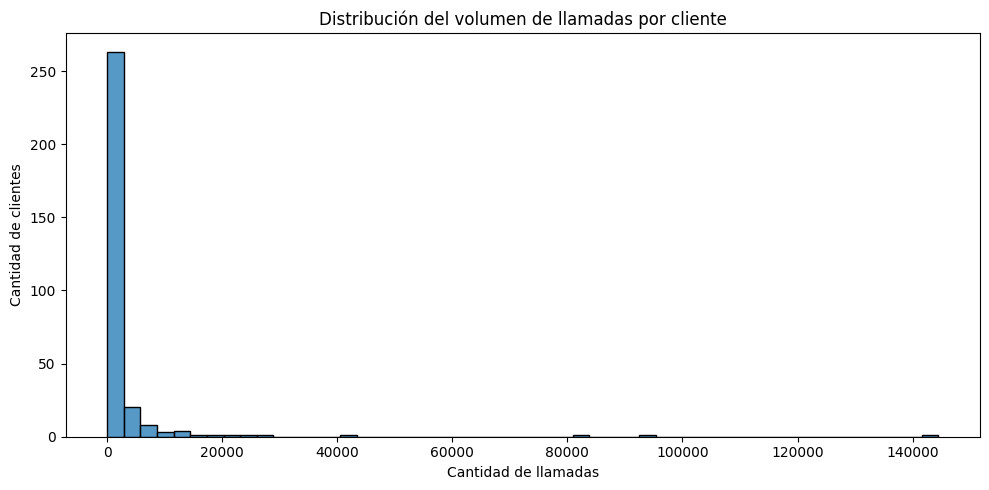

In [72]:
# Visualizamos la distribución del número de llamadas por cliente
plt.figure(figsize=(10, 5))
sns.histplot(data=calls_by_client, x='total_calls', bins=50)

plt.title('Distribución del volumen de llamadas por cliente')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

Encontramos que no hay una distribución equilibrada de las llamadas, ya que muchos de los clientes participan en pocas llamadas, mientras que pocos clientes participan en un volumen elevado de llamadas.

#### 2.5.2. Análisis a nivel por operador

Se analizará el desempeño individual de los operadores mediante métricas operativas. El objetivo es identificar diferencias claras entre ellos y empezar a reconocer posibles señales de ineficiencia.

##### 2.5.2.1. Número total de llamadas

Se calculará y comparará el número total de llamadas gestionadas por cada operador. Esto permitirá identificar operadores con alta o baja carga de trabajo.

In [73]:
# Ordenamos operadores reales según el número total de llamadas gestionadas
top_operators_by_calls = (
    operator_metrics
    .sort_values('total_calls', ascending=False)
    .head(20))

top_operators_by_calls

,operator_id,total_records,total_calls,missed_calls,answered_calls,effective_call_duration,total_duration_with_wait,total_waiting_time,avg_waiting_time_per_record,avg_waiting_time_per_call,missed_rate,avg_effective_call_duration_per_call,avg_total_duration_per_call
29,885890,253,60221,23807,36414,3340790,4783792,1443002,5703.565217,19.668533,0.395327,55.475499,79.437273
28,885876,283,59429,23330,36099,4363953,5733237,1369284,4838.459364,19.701263,0.392569,73.431372,96.472042
583,929428,65,23754,19118,4636,277118,633196,356078,5478.123077,17.993344,0.804833,11.666161,26.656395
551,925922,73,20021,9258,10763,828782,1252549,423767,5805.027397,16.995897,0.462414,41.395635,62.561760
317,908640,43,14239,8164,6075,258804,410932,152128,3537.860465,10.771327,0.573355,18.175715,28.859611
582,929426,62,11189,6347,4842,267101,474106,207005,3338.790323,18.264239,0.567254,23.871749,42.372509
1,879898,227,7313,2360,4953,257391,361288,103897,457.696035,14.720197,0.322713,35.196363,49.403528
847,945286,62,6880,3626,3254,146643,281690,135047,2178.177419,18.447608,0.527035,21.314390,40.943314
853,945302,70,6138,3184,2954,323488,458915,135427,1934.671429,21.551364,0.518736,52.702509,74.766210
108,893804,289,5846,1323,4523,282434,358580,76146,263.480969,12.635662,0.226309,48.312350,61.337667


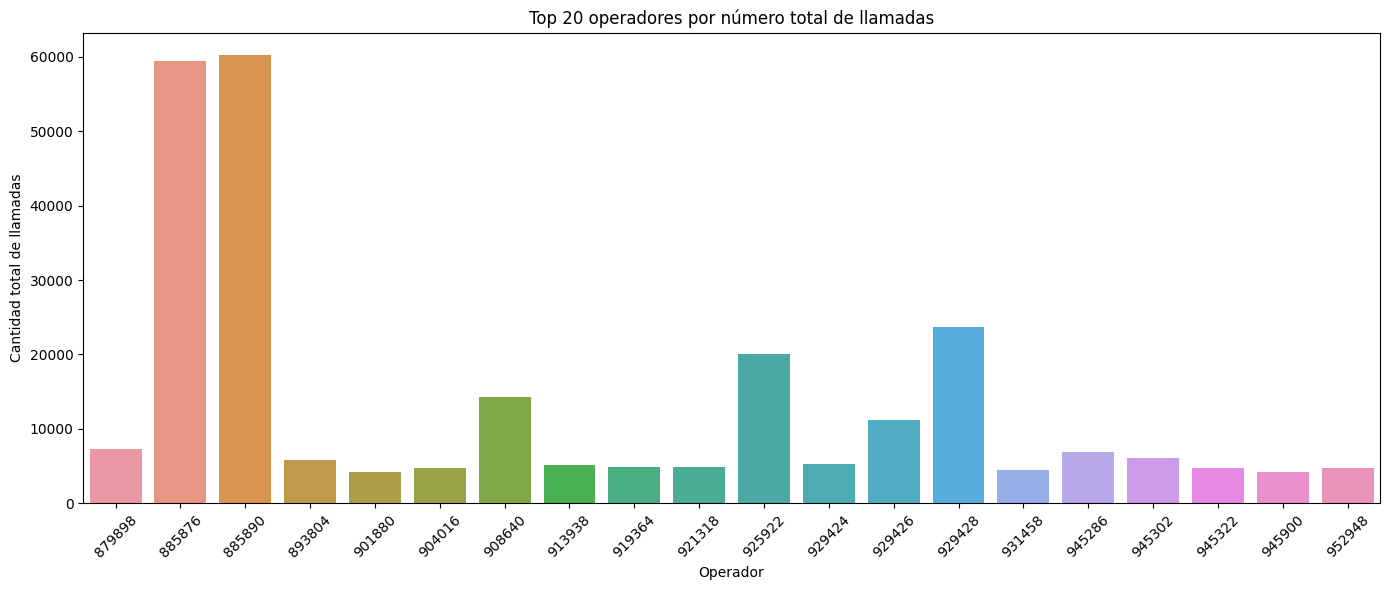

In [74]:
# Visualizamos los 20 operadores con mayor volumen de llamadas
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_operators_by_calls,
    x='operator_id',
    y='total_calls')

plt.title('Top 20 operadores por número total de llamadas')
plt.xlabel('Operador')
plt.ylabel('Cantidad total de llamadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se ha encontrado que los operadores con identificación 885890 y 885876 poseen la mayor cantidad de llamadas (y en gran medida), seguidos de los operadores con identificación 929428, 925922 y 908640. Los demás operadores del top 20 poseen una cantidad total de llamadas similar.

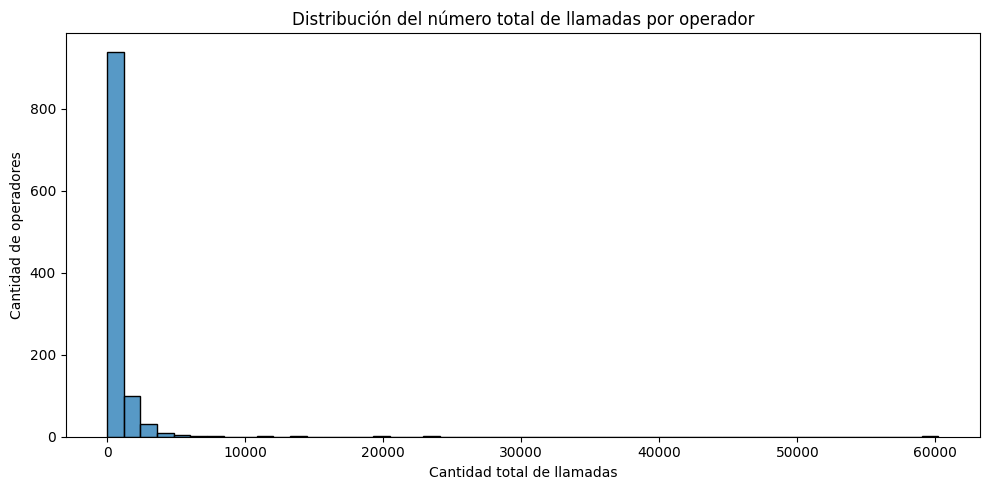

In [75]:
# Visualizamos la distribución del volumen de llamadas por operador
plt.figure(figsize=(10, 5))
sns.histplot(data=operator_metrics, x='total_calls', bins=50)

plt.title('Distribución del número total de llamadas por operador')
plt.xlabel('Cantidad total de llamadas')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Encontramos que no hay una carga equilibrada de trabajo, ya que muchos de los operadores participan en pocas llamadas, mientras que pocos operadores participan en un volumen elevado de llamadas.

##### 2.5.2.2. Proporción de llamadas perdidas

Se evaluará qué proporción de llamadas se pierde por operador. Esta métrica será central para detectar ineficiencia, ya que una gran cantidad de llamadas perdidas es uno de los criterios principales del proyecto.

In [76]:
# Ordenamos operadores reales según su tasa de llamadas perdidas
top_operators_by_missed_rate = (
    operator_metrics
    .sort_values('missed_rate', ascending=False)
    .head(20))

top_operators_by_missed_rate.head()

,operator_id,total_records,total_calls,missed_calls,answered_calls,effective_call_duration,total_duration_with_wait,total_waiting_time,avg_waiting_time_per_record,avg_waiting_time_per_call,missed_rate,avg_effective_call_duration_per_call,avg_total_duration_per_call
1041,962904,1,2,2,0,0,43,43,43.0,21.5,1.0,0.0,21.5
970,954284,1,1,1,0,0,3,3,3.0,3.0,1.0,0.0,3.0
27,885682,3,3,3,0,0,51,51,17.0,17.0,1.0,0.0,17.0
874,946454,2,13,13,0,0,0,0,0.0,0.0,1.0,0.0,0.0
1077,970250,1,1,1,0,0,8,8,8.0,8.0,1.0,0.0,8.0


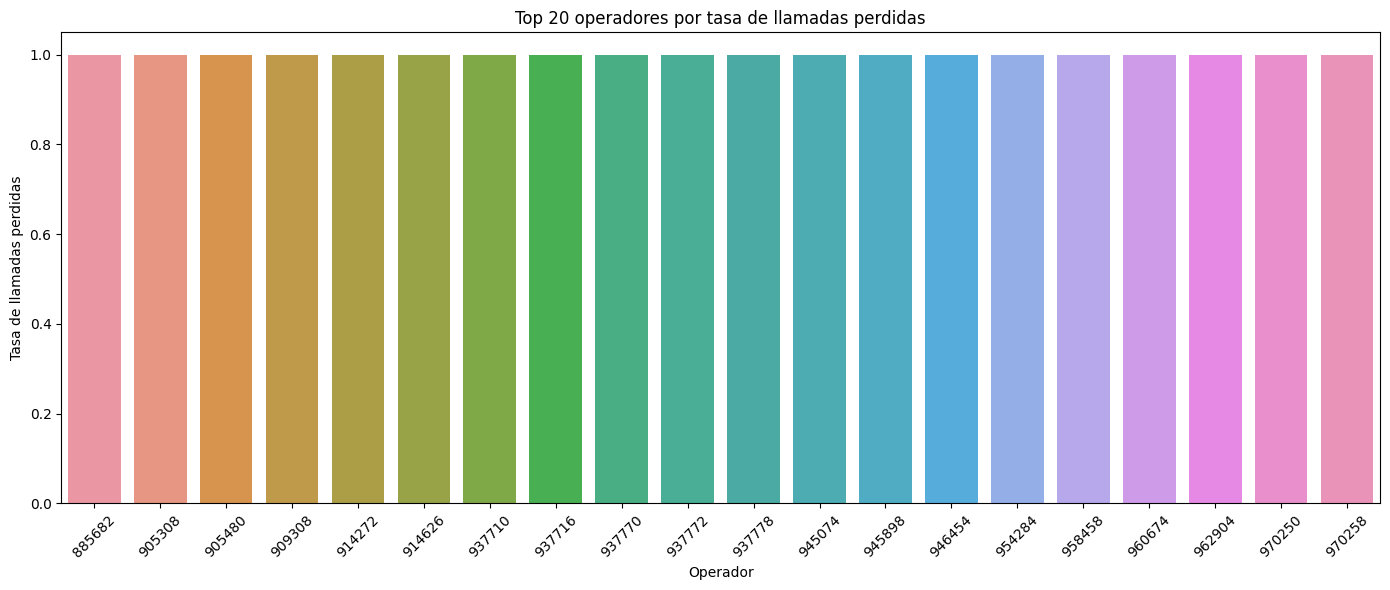

In [77]:
# Visualizamos los 20 operadores con mayor proporción de llamadas perdidas
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_operators_by_missed_rate,
    x='operator_id',
    y='missed_rate')

plt.title('Top 20 operadores por tasa de llamadas perdidas')
plt.xlabel('Operador')
plt.ylabel('Tasa de llamadas perdidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos que incluso los 20 operadores con mayor tasa de llamadas perdidas tienen un índice del 100 %, lo cual es un riesgo importante para el interés del negocio. Se procede a cuantificar la cantidad de operadores con dicha tasa del 100 % en llamadas perdidas.

In [78]:
# Cuantificando la cantidad de trabajadores con una tasa de llamadas perdidas del 100 %
len(operator_metrics[operator_metrics['missed_rate'] == 1])

34

Se ha encontrado que 34 operadores de los 1092 identificados presentan una tasa de llamadas perdidas del 100 %, lo cual representa un 3.11 % del total de operadores. Si bien representa un bajo porcentaje de operadores con dicha tasa de llamadas perdidas inadecuada, se recomienda tomar en cuenta este hallazgo para mejorar la productividad de los trabajadores.

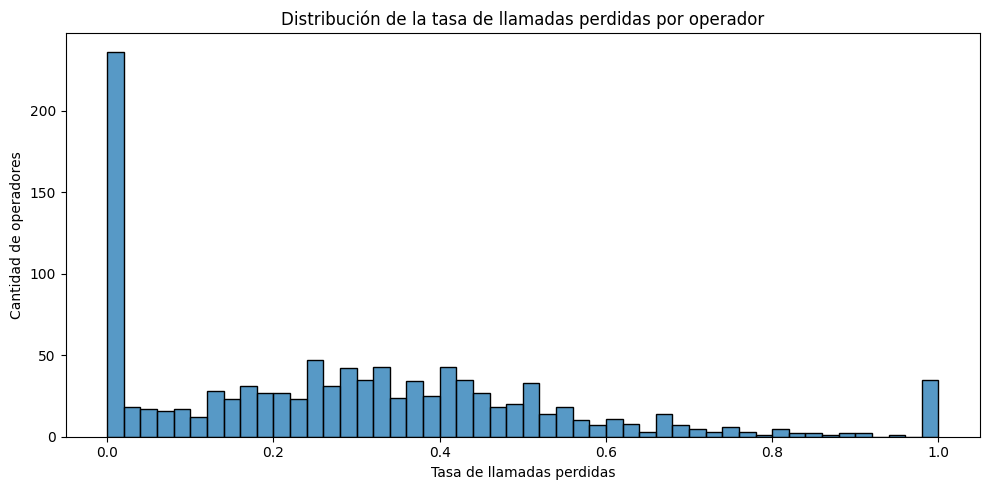

In [79]:
# Visualizamos la distribución de la tasa de llamadas perdidas por operador
plt.figure(figsize=(10, 5))
sns.histplot(data=operator_metrics, x='missed_rate', bins=50)

plt.title('Distribución de la tasa de llamadas perdidas por operador')
plt.xlabel('Tasa de llamadas perdidas')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Como ya se había comentado, se detectó una cantidad de 34 operadores que presentan una tasa de llamadas perdidas del 100 %, grupo que representa el segundo más grande según la distribución mostrada, sólo superada por el grupo de operadores con una tasa de llamadas perdidas del 0 %, la cual se procede a cuantificar a continuación.

In [80]:
# Cuantificando la cantidad de trabajadores con una tasa de llamadas perdidas del 0 %
len(operator_metrics[operator_metrics['missed_rate'] == 0])

216

Encontramos entonces que 216 operadores poseen una tasa de llamadas perdidas del 0 %, valor ideal al que se sugeriría que los operadores tratasen de acercarse como objetivo de la empresa. Exceptuando los 2 grupos predominantes (operadores con 0 % y 100 % en la tasa de llamadas perdidas), la distribución de los demás operadores se observa equilibrada y aproximadamente cercana a una distribución normal.

##### 2.5.2.3. Tiempo promedio de espera

Se analizará el tiempo promedio de espera asociado a cada operador. El objetivo es detectar operadores cuyo tiempo de espera sea particularmente alto, lo cual podría reflejar problemas de desempeño.

In [81]:
# Ordenamos operadores reales según el tiempo promedio de espera por llamada
top_operators_by_waiting_time = (
    operator_metrics
    .sort_values('avg_waiting_time_per_call', ascending=False)
    .head(20))

top_operators_by_waiting_time

,operator_id,total_records,total_calls,missed_calls,answered_calls,effective_call_duration,total_duration_with_wait,total_waiting_time,avg_waiting_time_per_record,avg_waiting_time_per_call,missed_rate,avg_effective_call_duration_per_call,avg_total_duration_per_call
489,920930,1,1,0,1,21,83,62,62.000000,62.000000,0.000000,21.000000,83.000000
617,932246,1,1,1,0,0,60,60,60.000000,60.000000,1.000000,0.000000,60.000000
348,910958,10,13,0,13,792,1501,709,70.900000,58.200000,0.000000,60.923077,115.461538
168,899900,2,2,0,2,382,498,116,58.000000,58.000000,0.000000,191.000000,249.000000
316,908300,2,3,0,3,29,198,169,84.500000,56.500000,0.000000,9.666667,66.000000
314,908162,2,3,0,3,281,440,159,79.500000,52.500000,0.000000,93.666667,146.666667
198,901498,4,5,0,5,198,463,265,66.250000,51.000000,0.000000,39.600000,92.600000
565,928092,3,5,0,5,173,409,236,78.666667,49.666667,0.000000,34.600000,81.800000
990,956080,3,5,0,5,1187,1439,252,84.000000,48.666667,0.000000,237.400000,287.800000
145,896538,11,14,1,13,2087,2752,665,60.454545,48.090909,0.071429,149.071429,196.571429


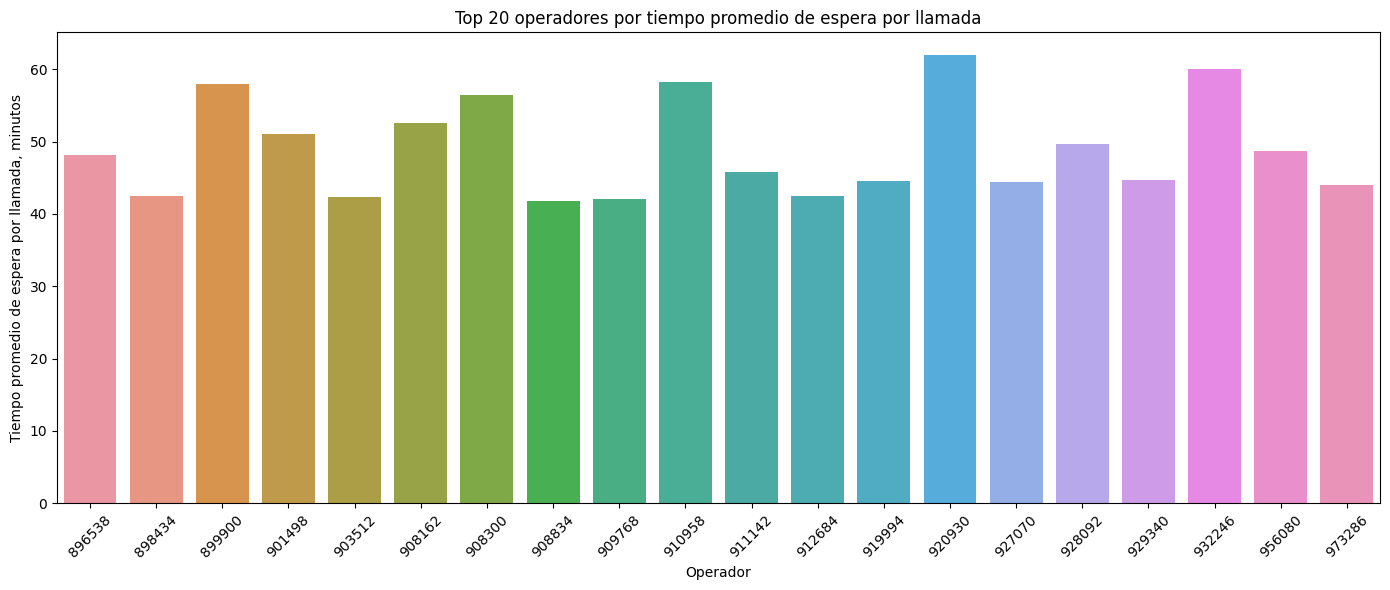

In [82]:
# Visualizamos los 20 operadores con mayor tiempo promedio de espera por llamada
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_operators_by_waiting_time,
    x='operator_id',
    y='avg_waiting_time_per_call')

plt.title('Top 20 operadores por tiempo promedio de espera por llamada')
plt.xlabel('Operador')
plt.ylabel('Tiempo promedio de espera por llamada, minutos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Encontramos que los operadores que poseen mayor tiempo promedio de espera por llamada registran un valor que se aproxima a los 55 minutos; mientras que aquello con un tiempo promedio no tan elevado generan una espera por llamada de 45 minutos aproximadamente.

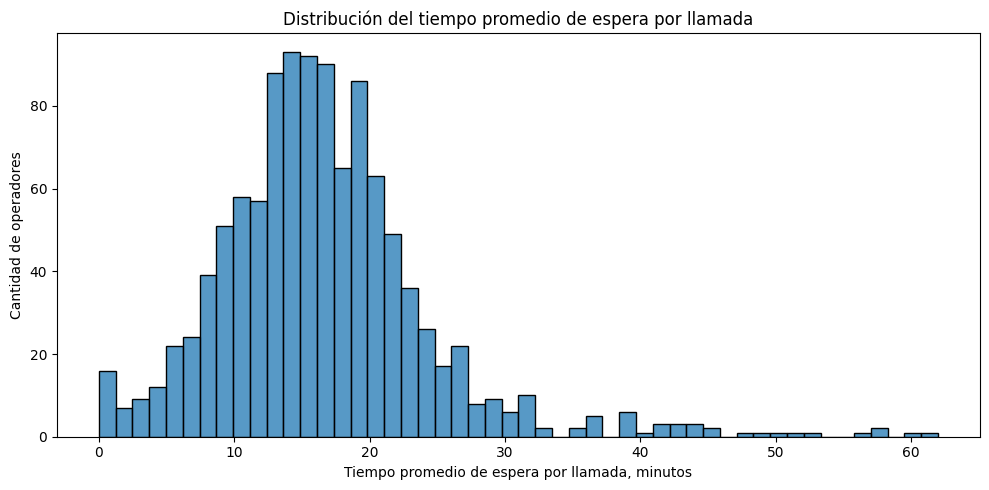

In [83]:
# Visualizamos la distribución del tiempo promedio de espera por llamada entre operadores
plt.figure(figsize=(10, 5))
sns.histplot(data=operator_metrics, x='avg_waiting_time_per_call', bins=50)

plt.title('Distribución del tiempo promedio de espera por llamada')
plt.xlabel('Tiempo promedio de espera por llamada, minutos')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Encontramos una distribución equilibrada de la cantidad de tiempo de espera por llamada respecto de la cantidad de operadores que registran dicho valor promedio (generando una distribución muy cercana a la normal). Se aprecia un pico local para el tiempo promedio de espera por llamada de 0 minutos (o cercano a 0), por lo que se procederá a cuantificar la cantidad de operadores que pertenecen a dicho pico local.

In [84]:
len(operator_metrics[operator_metrics['avg_waiting_time_per_call'] == 0])

5

Se ha encontrado que sólo 5 operadores no reportan tiempo de espera en las llamadas en las que participan, lo cual es inusual para la naturaleza del negocio y por ello es coherente esta baja cantidad respecto del total de operadores (1092). 

##### 2.5.2.4. Duración promedio de llamadas

Se calculará la duración promedio de las llamadas por operador. Esto permitirá contextualizar el resto de las métricas y evaluar si la duración de las llamadas podría estar relacionada con la eficiencia o la ineficiencia observadas.

In [85]:
# Ordenamos operadores reales según la duración efectiva promedio por llamada
top_operators_by_call_duration = (
    operator_metrics
    .sort_values('avg_effective_call_duration_per_call', ascending=False)
    .head(20))

top_operators_by_call_duration

,operator_id,total_records,total_calls,missed_calls,answered_calls,effective_call_duration,total_duration_with_wait,total_waiting_time,avg_waiting_time_per_record,avg_waiting_time_per_call,missed_rate,avg_effective_call_duration_per_call,avg_total_duration_per_call
74,891192,1,1,0,1,1306,1338,32,32.000000,32.000000,0.000000,1306.000000,1338.000000
415,917890,1,1,0,1,647,660,13,13.000000,13.000000,0.000000,647.000000,660.000000
169,899906,1,1,0,1,626,645,19,19.000000,19.000000,0.000000,626.000000,645.000000
167,899898,2,2,0,2,1180,1230,50,25.000000,25.000000,0.000000,590.000000,615.000000
149,897894,5,19,0,19,9230,9496,266,53.200000,13.400000,0.000000,485.789474,499.789474
416,918390,72,246,31,215,118018,121868,3850,53.472222,15.526347,0.126016,479.747967,495.398374
67,891154,118,528,157,371,243908,253356,9448,80.067797,19.616203,0.297348,461.946970,479.840909
302,907974,3,3,0,3,1281,1310,29,9.666667,9.666667,0.000000,427.000000,436.666667
326,909452,1,8,0,8,3394,3509,115,115.000000,14.375000,0.000000,424.250000,438.625000
1073,969600,2,19,0,19,7823,8083,260,130.000000,13.716667,0.000000,411.736842,425.421053


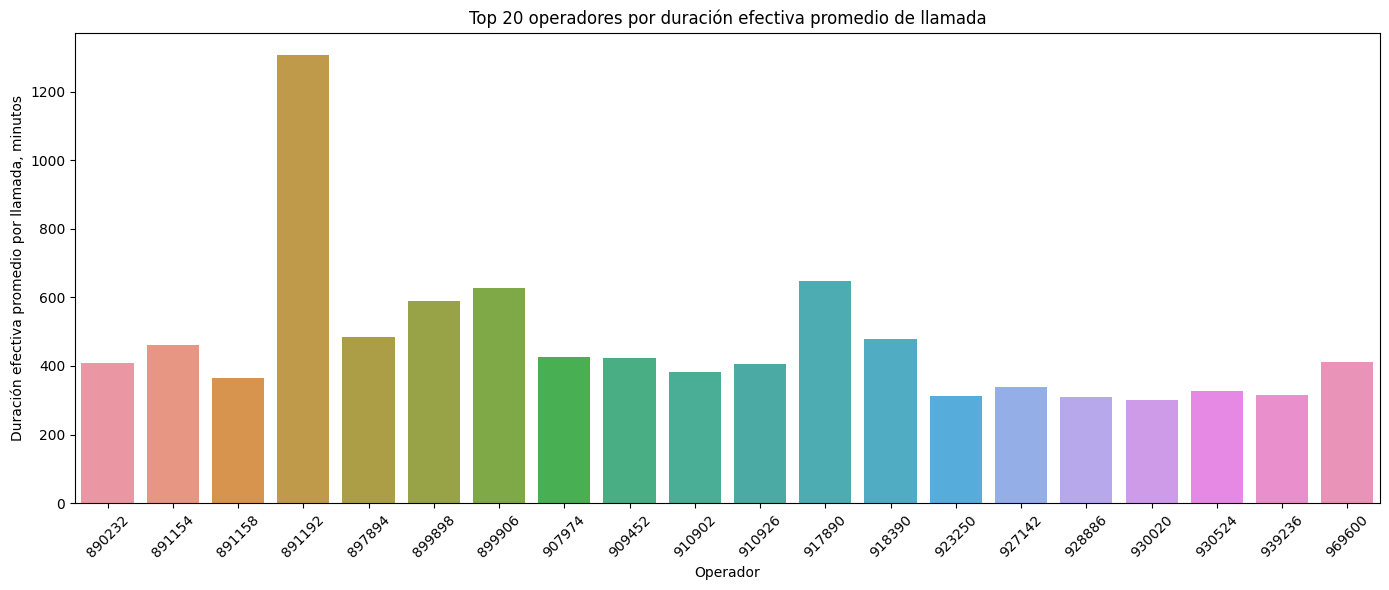

In [86]:
# Visualizamos los 20 operadores con mayor duración efectiva promedio por llamada
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_operators_by_call_duration,
    x='operator_id',
    y='avg_effective_call_duration_per_call'
)

plt.title('Top 20 operadores por duración efectiva promedio de llamada')
plt.xlabel('Operador')
plt.ylabel('Duración efectiva promedio por llamada, minutos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se ha encontrado que el operador con identificación 891192 posee (en gran medida) la mayor duración efectiva promedio por llamada, mayor a 2 horas (caso atípico), mientras que los demás operadores del top 20 poseen una duración similar.

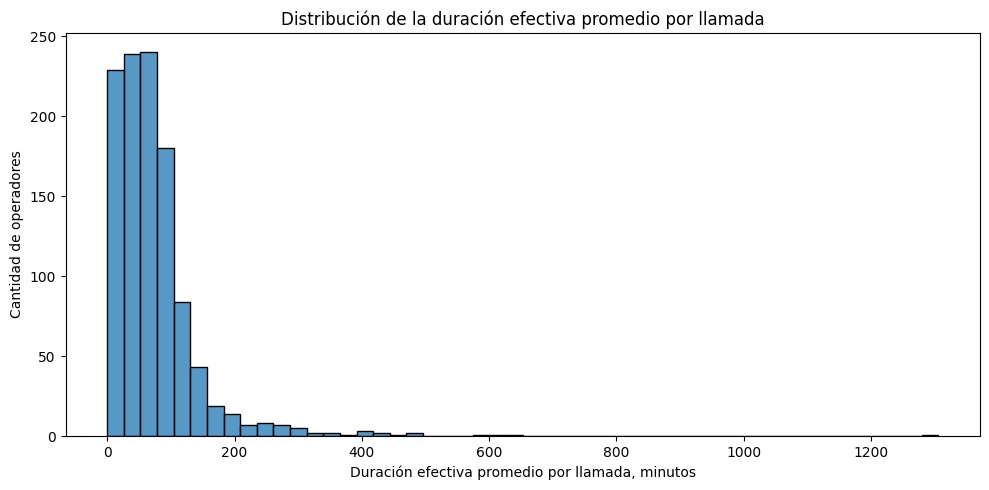

In [87]:
# Visualizamos la distribución de la duración efectiva promedio por llamada entre operadores
plt.figure(figsize=(10, 5))
sns.histplot(data=operator_metrics, x='avg_effective_call_duration_per_call', bins=50)

plt.title('Distribución de la duración efectiva promedio por llamada')
plt.xlabel('Duración efectiva promedio por llamada, minutos')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Hemos encontrado una tendencia a que la mayor cantidad de operadores generan la menor duración de llamadas efectivas; mientras que una muy menor cantidad de operadores generan la mayor cantidad de duración en llamadas efectivas.

#### 2.5.3. Segmentaciones

Se comparará el desempeño en distintos contextos de operación. Esto permitirá evaluar si la ineficiencia depende del tipo de llamada, del cliente o del plan tarifario.

##### 2.5.3.1. Por tipo de llamada

Se analizarán diferencias entre llamadas entrantes y salientes. Esto es importante porque los criterios de ineficiencia no afectan del mismo modo a ambos tipos de llamadas.

In [88]:
# Agrupamos las llamadas por dirección para comparar llamadas entrantes y salientes
calls_by_direction = (
    calls
    .groupby('direction')
    .agg(
        total_records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        answered_calls=('answered_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean'),
        avg_effective_call_duration=('call_duration', 'mean')
    )
    .reset_index())

# Calculamos la tasa de llamadas perdidas por dirección
calls_by_direction['missed_rate'] = (
    calls_by_direction['missed_calls'] / calls_by_direction['total_calls'])

calls_by_direction

,direction,total_records,total_calls,missed_calls,answered_calls,avg_waiting_time_per_call,avg_effective_call_duration,missed_rate
0,in,20003,197845,104323,93522,17.302950,492.219017,0.527297
1,out,28999,608864,271595,337269,16.501063,1124.304217,0.446068


Vemos que las llamadas salientes han sido realizadas en mayor cantidad respecto de las llamadas entrantes; y por ello es entendible por qué gran parte de los parámetros son mayores para el grupo de las llamadas salientes; a excepción de:
- Tiempo promedio por llamada, ya que en las llamadas entrantes se registra un valor ligeramente mayor respecto de las llamadas salientes.
- Ratio de pérdida de llamadas, en donde las llamadas entrantes han generado mayor porcentaje de llamadas perdidas respecto de las llamadas salientes.

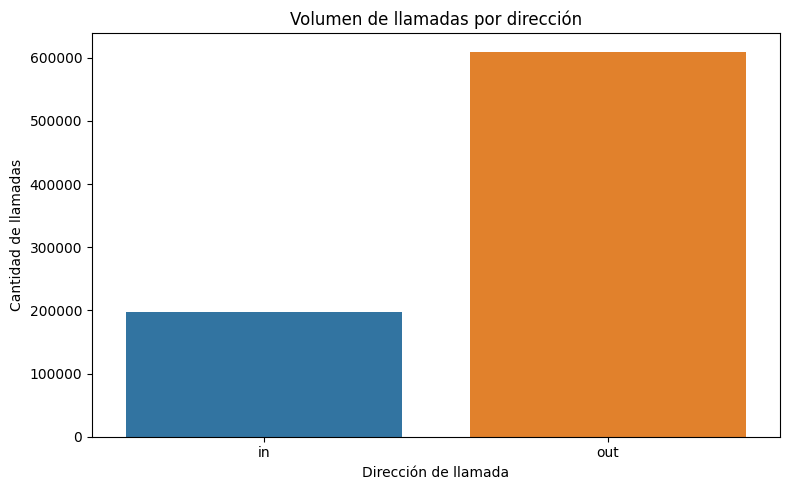

In [89]:
# Visualizamos el volumen total de llamadas por dirección
plt.figure(figsize=(8, 5))
sns.barplot(data=calls_by_direction, x='direction', y='total_calls')

plt.title('Volumen de llamadas por dirección')
plt.xlabel('Dirección de llamada')
plt.ylabel('Cantidad de llamadas')
plt.tight_layout()
plt.show()

Confirmamos que el volumen de llamadas salientes aproximadamente triplica la cantidad de llamadas entrantes, dejando clara la principal fuente de labores para los operadores; lo cual es de esperar ya que una de sus funciones más importantes es poder contactarse con los clientes de interés, las cuales usualmente se realizan como llamadas salientes del operador hacia el cliente.

##### 2.5.3.2. Por llamadas internas y externas

Se estudiará si las llamadas internas y externas presentan comportamientos distintos en términos de pérdida, espera y duración. Esto ayudará a entender mejor el contexto de trabajo de cada operador.

In [90]:
# Creamos una variable descriptiva para clasificar llamadas internas, externas y sin información
calls['internal_type'] = calls['internal'].map({
    True: 'internal',
    False: 'external'}).fillna('unknown')

# Agrupamos llamadas según sean internas, externas o sin información
calls_by_internal_type = (
    calls
    .groupby('internal_type')
    .agg(
        total_records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        answered_calls=('answered_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean'),
        avg_effective_call_duration=('call_duration', 'mean')
    ).reset_index())

# Calculamos la tasa de llamadas perdidas por tipo interno/externo
calls_by_internal_type['missed_rate'] = (
    calls_by_internal_type['missed_calls'] / calls_by_internal_type['total_calls'])

calls_by_internal_type

,internal_type,total_records,total_calls,missed_calls,answered_calls,avg_waiting_time_per_call,avg_effective_call_duration,missed_rate
0,external,43239,791829,369737,422092,17.789739,968.087375,0.466940
1,internal,5653,14655,6015,8640,9.525450,103.213692,0.410440
2,unknown,110,225,166,59,14.248716,63.254545,0.737778


En base a la tabla anterior encontramos que las llamadas externas:
- Ocupan el mayor volumen de llamadas registradas.
- Generan casi el doble del tiempo promedio de espera por llamada respecto de las llamadas internas.
- Reportan casi 9 veces la duración efectiva promedio de las llamadas respecto de las llamadas internas.
- Sin contar a los registros con internal_type sin identificar, poseen una mayor tasa de pérdida de llamadas respecto de las llamadas internas.

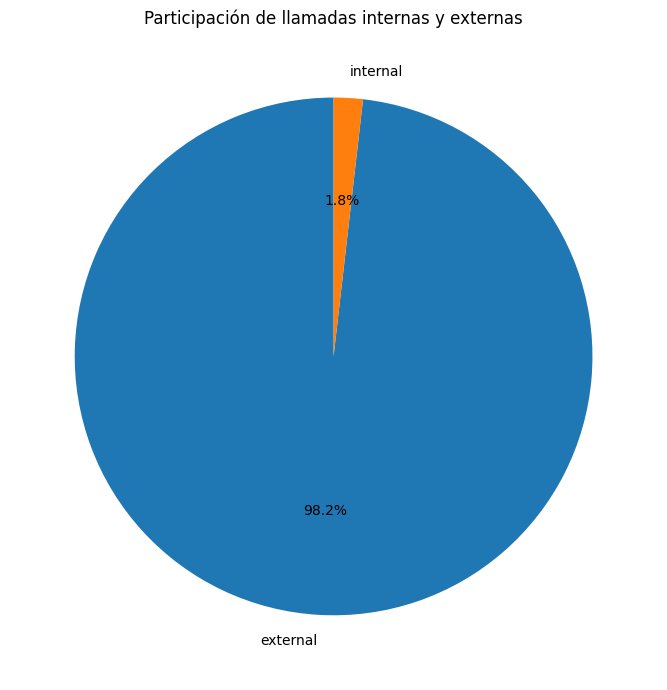

In [91]:
# Visualizamos la participación de llamadas internas y externas
plt.figure(figsize=(7, 7))
plt.pie(
    calls_by_internal_type[calls_by_internal_type['internal_type'] != 'unknown']['total_calls'],
    labels=calls_by_internal_type[calls_by_internal_type['internal_type'] != 'unknown']['internal_type'],
    autopct='%1.1f%%',
    startangle=90)

plt.title('Participación de llamadas internas y externas')
plt.tight_layout()
plt.show()

Terminamos de verificar que el volumen de llamadas es realizado casi al 100 % entre clientes y operadores por lo que sería recomendable asegurar un adecuado sistema que garantice la continuidad de dicho servicio principal del negocio.

##### 2.5.3.3. Por cliente

Se evaluará si ciertos clientes presentan sistemáticamente peores resultados operativos que otros. Esto permitirá distinguir entre problemas ligados al operador y problemas ligados al contexto del cliente.

In [92]:
# Ordenamos clientes según el volumen total de llamadas
top_clients_by_calls = (
    calls_by_client
    .sort_values('total_calls', ascending=False)
    .head(20))

top_clients_by_calls

,user_id,total_records,total_calls,missed_calls,avg_waiting_time_per_call
22,166582,720,144500,61224,17.986253
175,167626,1180,93406,54994,19.694158
284,168361,1149,82708,45447,20.500330
203,167827,300,40673,27751,14.567260
271,168252,852,26504,10651,12.502824
248,168062,1081,25357,14982,15.283487
264,168187,2342,21398,9527,18.334161
4,166405,962,17536,8900,19.162654
111,167125,540,15286,9735,18.222440
141,167285,68,14349,8274,7.119445


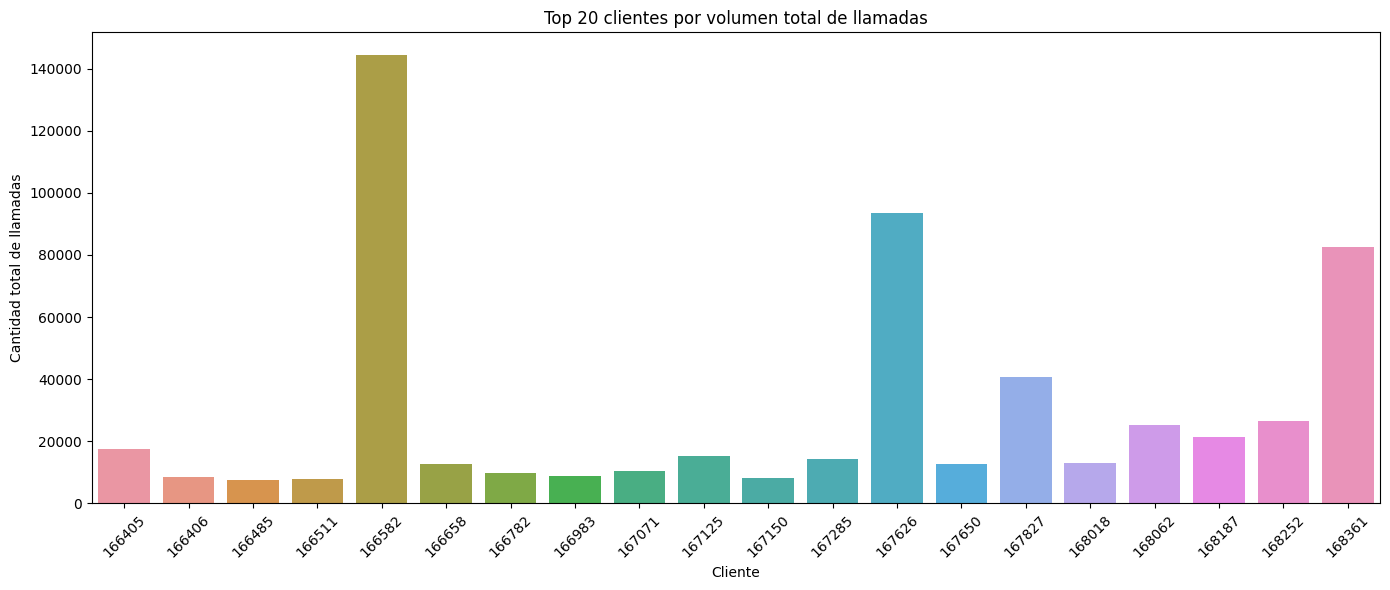

In [93]:
# Visualizamos los 20 clientes con mayor volumen de llamadas
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_clients_by_calls,
    x='user_id',
    y='total_calls')

plt.title('Top 20 clientes por volumen total de llamadas')
plt.xlabel('Cliente')
plt.ylabel('Cantidad total de llamadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos claramente que el cliente con mayor volumen de llamadas (en gran medida) es el que cuenta con el ID 166582, seguido de los identificados con 167626, 168361 y 167827. Los demás clientes del top 20 poseen un volumen de llamadas similar.

In [94]:
# Calculamos la tasa de llamadas perdidas por cliente
calls_by_client['missed_rate'] = (
    calls_by_client['missed_calls'] / calls_by_client['total_calls'])

# Revisamos clientes con mayor tasa de llamadas perdidas y volumen mínimo de llamadas
top_clients_by_missed_rate = (
    calls_by_client[calls_by_client['total_calls'] >= 50]
    .sort_values('missed_rate', ascending=False)
    .head(20))

top_clients_by_missed_rate

,user_id,total_records,total_calls,missed_calls,avg_waiting_time_per_call,missed_rate
109,167122,10,465,465,6.941409,1.000000
241,168024,32,68,68,2.116667,1.000000
177,167631,2,58,58,0.000000,1.000000
285,168366,37,246,244,4.639467,0.991870
20,166548,30,78,77,13.521032,0.987179
286,168377,19,136,134,4.708841,0.985294
8,166481,10,58,57,1.554276,0.982759
58,166837,101,966,929,9.267945,0.961698
192,167744,9,80,76,10.471496,0.950000
166,167533,24,122,112,9.437169,0.918033


Encontramos que al menos 20 de los clientes poseen tasa de pérdida de llamadas mayor al 75 %, lo cual es inadecuado ya que representa un motivo por el cual dicho cliente podría descontinuar su plan contratado con el negocio; inclusive hay algunos clientes que nunca lograron ser atendidos (tasa de pérdida de llamadas del 100 %).

<AxesSubplot:xlabel='missed_rate', ylabel='Count'>

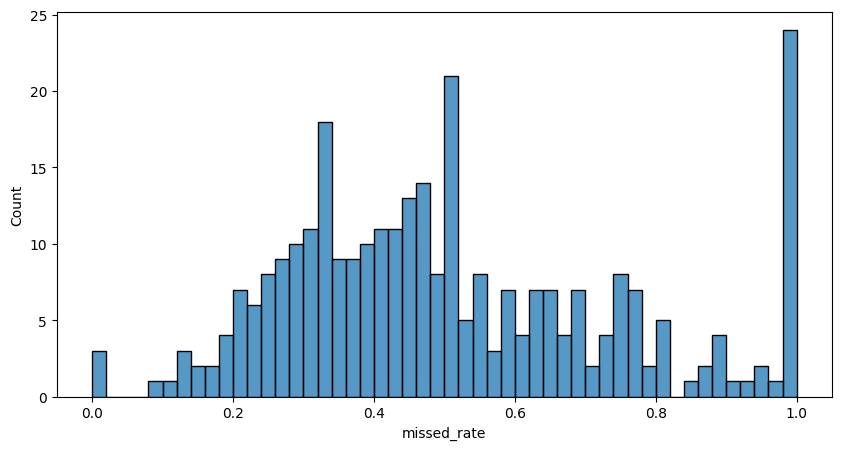

In [95]:
# Visualizamos la distribución de los clientes respecto del ratio de pérdida de llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data= calls_by_client, x='missed_rate', bins=50)

Si bien la distribución mostrada se aprecia equilibrada en el ratio de llamadas perdidas, lo ideal para el negocio es que esta gráfica muestre mayor volumen para ratios pequeños; además de que hay un pico importante y riesgoso cercano al 100 %, inadecuado para la retención de clientes a largo plazo.

<AxesSubplot:xlabel='avg_waiting_time_per_call', ylabel='Count'>

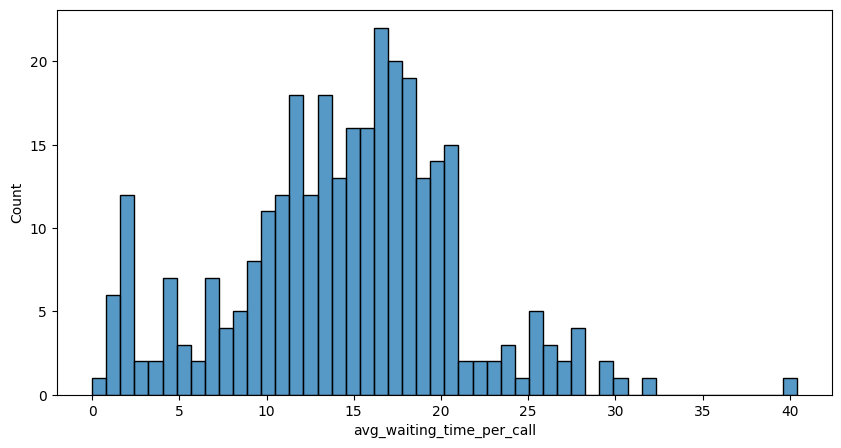

In [96]:
# Visualizamos la distribución de los clientes respecto del tiempo promedio de espera por llamada
plt.figure(figsize=(10, 5))
sns.histplot(data= calls_by_client, x='avg_waiting_time_per_call', bins=50)

Si bien la distribución se aprecia equilibrada, encontramos picos locales en valores pequeños de tiempo de espera promedio por llamada, lo cual se encuentra como positivo pero no determinante ya que lo recomendable sería que el resultado de este esquema esté inclinado preferentemente hacia valores pequeños de tiempo de espera. 

##### 2.5.3.4. Por plan tarifario

Se compararán métricas según el plan tarifario del cliente. El objetivo es explorar si existen diferencias operativas asociadas al tipo de servicio contratado.

In [97]:
# Combinamos el dataframe calls con clients para incorporar información del plan tarifario
calls_with_clients = calls.merge(
    clients[['user_id', 'tariff_plan', 'date_start']],
    on='user_id',
    how='left')

# Verificamos las primeras filas del dataframe combinado
calls_with_clients.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,call_week,call_month,waiting_time,avg_waiting_time_per_call,missed_calls_count,answered_calls_count,internal_type,tariff_plan,date_start
0,166377,2019-08-04,in,False,unknown,True,2,0,4,2019-07-29/2019-08-04,2019-08,4,2.000000,2,0,external,B,2019-08-01
1,166377,2019-08-05,out,True,880022,True,3,0,5,2019-08-05/2019-08-11,2019-08,5,1.666667,3,0,internal,B,2019-08-01
2,166377,2019-08-05,out,True,880020,True,1,0,1,2019-08-05/2019-08-11,2019-08,1,1.000000,1,0,internal,B,2019-08-01
3,166377,2019-08-05,out,True,880020,False,1,10,18,2019-08-05/2019-08-11,2019-08,8,8.000000,0,1,internal,B,2019-08-01
4,166377,2019-08-05,out,False,880022,True,3,0,25,2019-08-05/2019-08-11,2019-08,25,8.333333,3,0,external,B,2019-08-01


In [98]:
# Agrupamos las llamadas por plan tarifario
calls_by_tariff = (
    calls_with_clients
    .groupby('tariff_plan')
    .agg(
        total_records=('user_id', 'count'),
        total_clients=('user_id', 'nunique'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        answered_calls=('answered_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean'),
        avg_effective_call_duration=('call_duration', 'mean')
    )    .reset_index())

# Calculamos la tasa de llamadas perdidas por plan tarifario
calls_by_tariff['missed_rate'] = (
    calls_by_tariff['missed_calls'] / calls_by_tariff['total_calls'])

calls_by_tariff

,tariff_plan,total_records,total_clients,total_calls,missed_calls,answered_calls,avg_waiting_time_per_call,avg_effective_call_duration,missed_rate
0,A,13556,34,439650,214450,225200,17.172974,1610.243435,0.487774
1,B,17237,112,163573,68492,95081,17.321207,601.913616,0.418724
2,C,18209,161,203486,92976,110510,16.105374,562.683838,0.456916


En base a la tabla anterior, encontramos que:
- El plan tarifario C posee mayor cantidad de clientes respecto del plan B, y este supera al plan A en dicho aspecto.
- Sin embargo, el plan A posee una cantidad mucho mayor de llamadas registradas respecto del plan C, y esta es mayor que la del plan B.
- En cuanto a la cantidad de llamadas perdidas y respondidas, el plan A se ubica por encima de los planes C y B, compatible con la observación anterior.
- Los tiempos de espera promedio por llamada entre los 3 planes difieren poco, siendo el del plan C ligeramente menor.
- Compatible con el volumen de llamadas, la duración efectiva promedio de llamadas del plan A es notoriamente superior a la de los planes B y C, los cuales son similares entre sí.
- A pesar del volumen de llamadas explicado, el plan B es el que posee la mejor tasa de llamadas perdidas, seguido del plan C y A, en donde este último muestra el mayor índice, lo cual puede deberse justamente al gran volumen de llamadas que recibe dicho plan y que quizás los operadores no pueden atender por limitaciones en los recursos humanos.

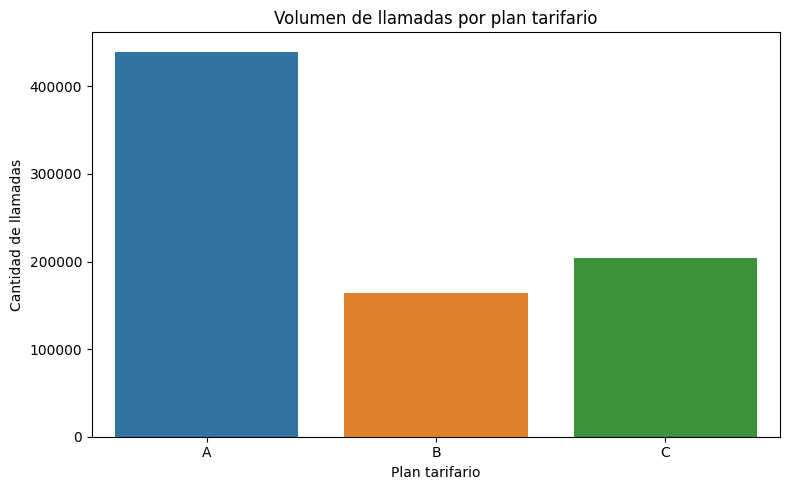

In [99]:
# Visualizamos el volumen de llamadas por plan tarifario
plt.figure(figsize=(8, 5))
sns.barplot(data=calls_by_tariff, x='tariff_plan', y='total_calls')

plt.title('Volumen de llamadas por plan tarifario')
plt.xlabel('Plan tarifario')
plt.ylabel('Cantidad de llamadas')
plt.tight_layout()
plt.show()

Observamos y verificamos que el plan A posee la mayor cantidad de flujo de llamadas, por lo cual se recomendaría enfocar a un grupo específico de los operadores a atender sólo llamadas del plan A para mejorar su tasa de llamadas perdidas y así mejorar la satisfacción de los clientes que representan el mayor porcentaje de presencia en el negocio.

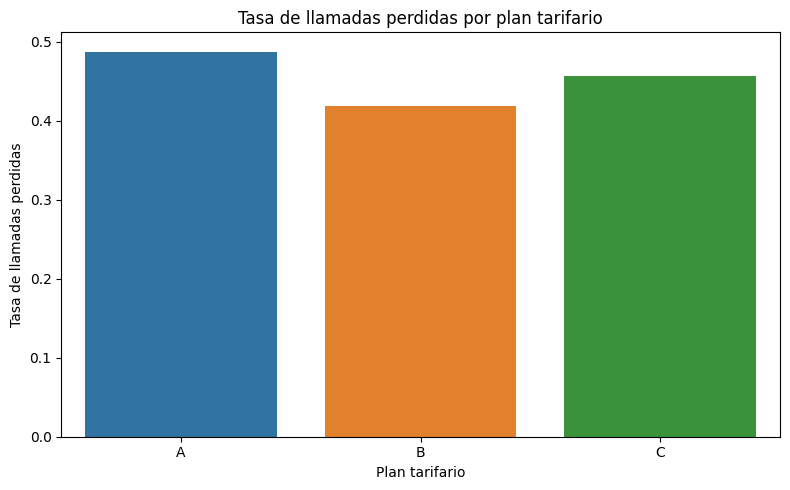

In [100]:
# Visualizamos la tasa de llamadas perdidas por plan tarifario
plt.figure(figsize=(8, 5))
sns.barplot(data=calls_by_tariff, x='tariff_plan', y='missed_rate')

plt.title('Tasa de llamadas perdidas por plan tarifario')
plt.xlabel('Plan tarifario')
plt.ylabel('Tasa de llamadas perdidas')
plt.tight_layout()
plt.show()

Como comentamos anteriormente, la tasa de llamadas perdidas del plan B es ligeramente menor respecto de los otros planes; en donde la mayor tasa de llamadas perdidas correspondiente al plan A puede deberse al alto volumen de llamadas que provienen de sus clientes suscritos y que los operadores no logran atender por limitaciones en la cantidad de trabajadores que atendiendo dichas llamadas.

## Paso 3. Definición de ineficiencia

### 3.1. Análisis de distribución de métricas

Se estudiará cómo se distribuyen las métricas clave relacionadas con la ineficiencia. El objetivo es comprender sus rangos y dispersión antes de establecer criterios de clasificación.

#### 3.1.1. Alta tasa de llamadas perdidas

Se analizará la distribución de la tasa de llamadas perdidas para identificar qué valores pueden considerarse anormalmente altos dentro del conjunto de operadores.

In [101]:
# Se crea un dataframe únicamente con llamadas entrantes, ya que el criterio de ineficiencia está enfocado en llamadas entrantes perdidas
incoming_calls = calls[calls['direction'] == 'in'].copy()

# Se agrupa por operador para calcular volumen de llamadas entrantes y llamadas entrantes perdidas
incoming_metrics = (
    incoming_calls[incoming_calls['operator_id'] != 'unknown']
    .groupby('operator_id')
    .agg(
        incoming_calls=('calls_count', 'sum'),
        missed_incoming_calls=('missed_calls_count', 'sum')
    ).reset_index())

# Se procede a calcular la tasa de llamadas entrantes perdidas por operador
incoming_metrics['missed_incoming_rate'] = (
    incoming_metrics['missed_incoming_calls'] / incoming_metrics['incoming_calls'])

# Se visualizan las primeras filas del dataframe de métricas entrantes
incoming_metrics.head()

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate
0,879896,58,0,0.0
1,879898,104,0,0.0
2,880020,7,0,0.0
3,880022,8,0,0.0
4,880026,24,0,0.0


In [102]:
# Se muestran las estadísticas descriptivas de la tasa de llamadas entrantes perdidas
incoming_metrics['missed_incoming_rate'].describe()

count    754.000000
mean       0.017574
std        0.065324
min        0.000000
25%        0.000000
50%        0.000000
75%        0.006747
max        1.000000
Name: missed_incoming_rate, dtype: float64

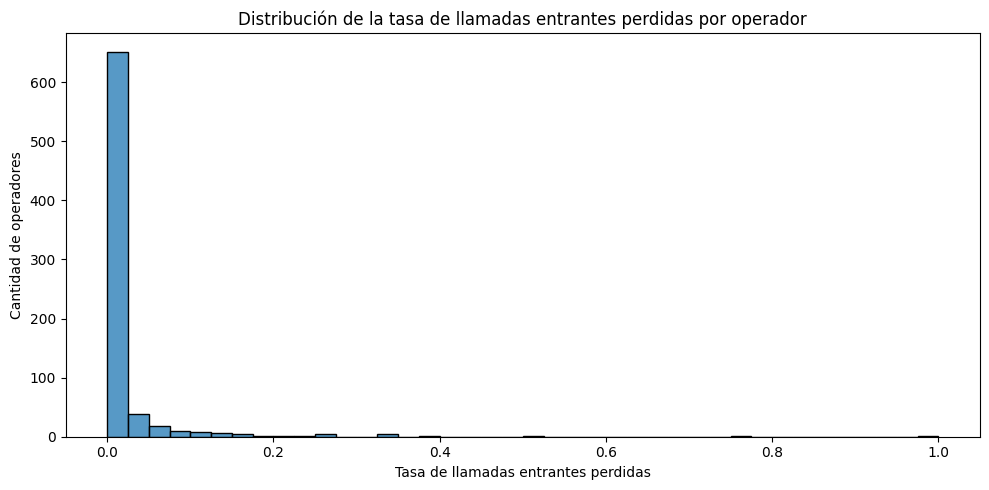

In [103]:
# Visualizamos la distribución de la tasa de llamadas entrantes perdidas por operador
plt.figure(figsize=(10, 5))

sns.histplot(
    data=incoming_metrics,
    x='missed_incoming_rate',
    bins=40)

plt.title('Distribución de la tasa de llamadas entrantes perdidas por operador')
plt.xlabel('Tasa de llamadas entrantes perdidas')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Se encuentra una gran concentración de operadores en niveles bajos de tasa de llamadas entrantes perdidas, lo cual es un buen indicador para la retención de clientes a largo plazo.

In [104]:
# Identificamos los operadores con mayor tasa de llamadas entrantes perdidas
top_missed_incoming_operators = (
    incoming_metrics
    .sort_values('missed_incoming_rate', ascending=False)
    .head(10))

top_missed_incoming_operators

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate
641,948756,1,1,1.000000
185,904344,4,3,0.750000
287,913886,2,1,0.500000
210,906392,18,7,0.388889
698,957922,3,1,0.333333
497,937432,3,1,0.333333
467,934098,6,2,0.333333
109,897872,3,1,0.333333
220,906412,26,7,0.269231
383,924936,8,2,0.250000


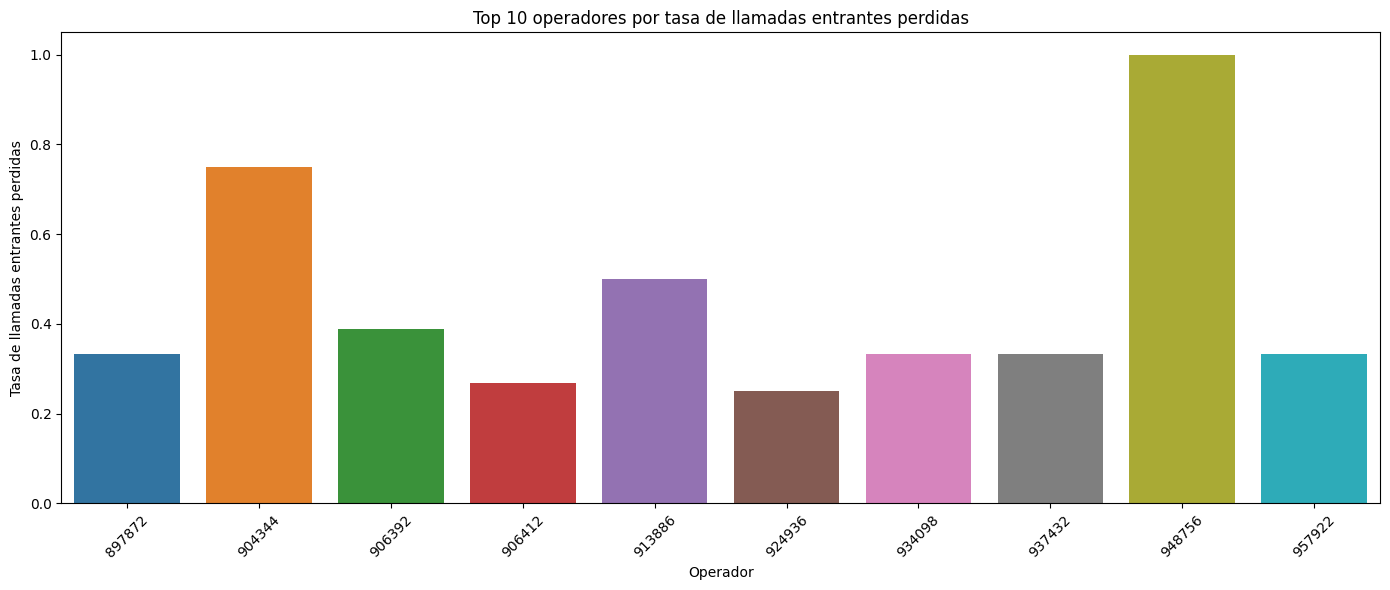

In [105]:
# Visualizamos los 10 operadores con mayor tasa de llamadas entrantes perdidas
plt.figure(figsize=(14, 6))

sns.barplot(
    data=top_missed_incoming_operators,
    x='operator_id',
    y='missed_incoming_rate')

plt.title('Top 10 operadores por tasa de llamadas entrantes perdidas')
plt.xlabel('Operador')
plt.ylabel('Tasa de llamadas entrantes perdidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se encuentra que sólo 1 de los operadores genera una tasa de pérdida de llamadas entrantes del 100 %, mientras que la mayoría del top 10 genera una tasa menor al 50 %, lo cual (el menos en este aspecto) muestra problemas locales en la eficiencia para el interés del negocio.

#### 3.1.2. Alto tiempo promedio de espera

Se evaluará la distribución del tiempo promedio de espera para reconocer qué operadores se encuentran en niveles desfavorables respecto al resto.

In [106]:
# Se calculan las métricas de tiempo de espera considerando únicamente llamadas entrantes para detectar tiempos de espera prolongados para llamadas entrantes
incoming_waiting_metrics = (
    incoming_calls[incoming_calls['operator_id'] != 'unknown']
    .groupby('operator_id')
    .agg(
        incoming_calls=('calls_count', 'sum'),
        total_incoming_waiting_time=('waiting_time', 'sum')
    ).reset_index())

# Calculamos el tiempo promedio de espera por llamada entrante
incoming_waiting_metrics['avg_incoming_waiting_time_per_call'] = (
    incoming_waiting_metrics['total_incoming_waiting_time'] /
    incoming_waiting_metrics['incoming_calls'])

# Revisamos las primeras filas del dataframe
incoming_waiting_metrics.head()

,operator_id,incoming_calls,total_incoming_waiting_time,avg_incoming_waiting_time_per_call
0,879896,58,574,9.896552
1,879898,104,1680,16.153846
2,880020,7,54,7.714286
3,880022,8,112,14.000000
4,880026,24,143,5.958333


In [107]:
# Revisamos estadísticas descriptivas del tiempo promedio de espera por llamada entrante
incoming_waiting_metrics['avg_incoming_waiting_time_per_call'].describe()

count    754.000000
mean      17.491612
std       12.171988
min        0.683673
25%        9.398782
50%       14.430502
75%       21.838889
max      115.500000
Name: avg_incoming_waiting_time_per_call, dtype: float64

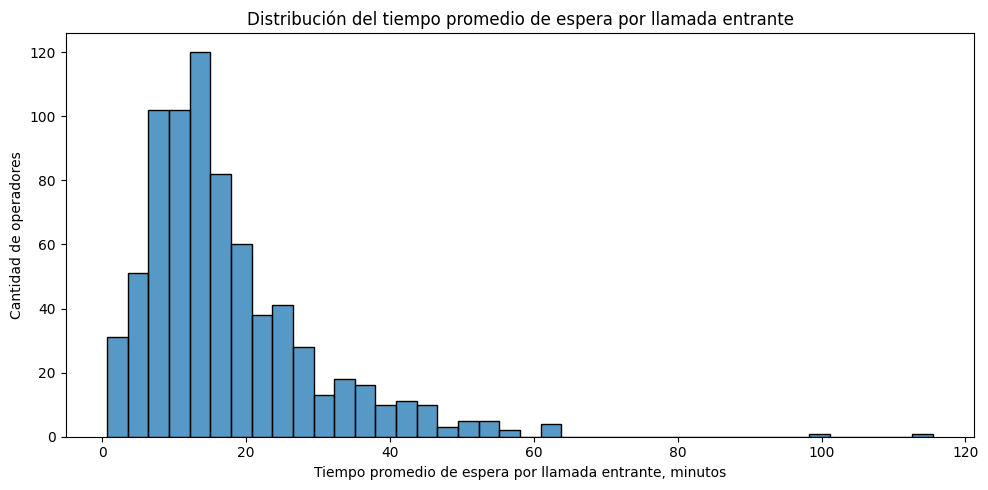

In [108]:
# Visualizamos la distribución del tiempo promedio de espera por llamada entrante
plt.figure(figsize=(10, 5))

sns.histplot(
    data=incoming_waiting_metrics,
    x='avg_incoming_waiting_time_per_call',
    bins=40)

plt.title('Distribución del tiempo promedio de espera por llamada entrante')
plt.xlabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Se aprecia una concentración de menores tiempos promedio de espera para llamadas entrantes, lo cual puede tomarse como buen indicador en la eficiencia de la mayoría de operadores que atienden dichas llamadas.

In [109]:
# Identificamos los operadores con mayor tiempo promedio de espera en llamadas entrantes
top_waiting_incoming_operators = (
    incoming_waiting_metrics
    .sort_values('avg_incoming_waiting_time_per_call', ascending=False)
    .head(20))

top_waiting_incoming_operators

,operator_id,incoming_calls,total_incoming_waiting_time,avg_incoming_waiting_time_per_call
199,905842,2,231,115.500000
311,917680,2,200,100.000000
715,960296,2,126,63.000000
352,920930,1,62,62.000000
225,907174,9,557,61.888889
362,922114,1,61,61.000000
123,899900,2,116,58.000000
250,908300,3,169,56.333333
268,910958,13,709,54.538462
493,937366,3,161,53.666667


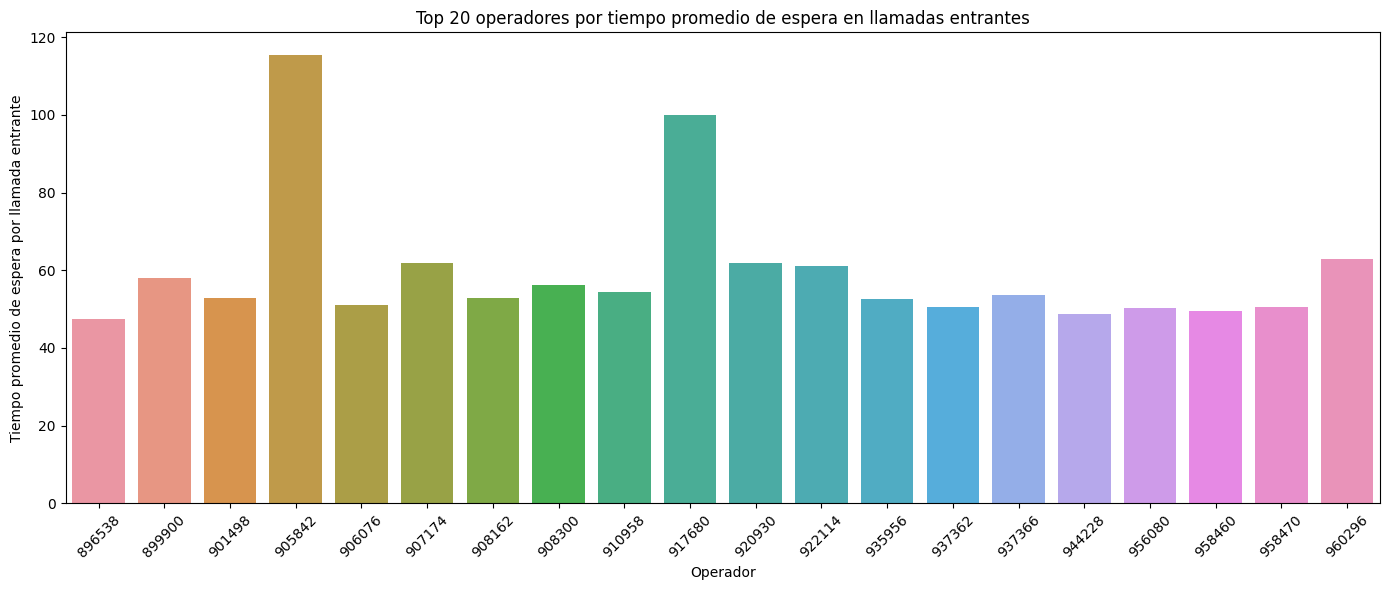

In [110]:
# Visualizamos los 20 operadores con mayor tiempo promedio de espera en llamadas entrantes
plt.figure(figsize=(14, 6))

sns.barplot(
    data=top_waiting_incoming_operators,
    x='operator_id',
    y='avg_incoming_waiting_time_per_call')

plt.title('Top 20 operadores por tiempo promedio de espera en llamadas entrantes')
plt.xlabel('Operador')
plt.ylabel('Tiempo promedio de espera por llamada entrante')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Según el gráfico mostrado, encontramos que 2 de los operadores poseen los mayores tiempos promedio de espera en llamadas entrantes (con ID 905842 y 917680), los cuales incluso superan los 100 minutos de espera. El resto de operadores del top 20 posee un tiempo de espera promedio que oscila aproximadamente entre 45 minutos y 1 hora, lo cual también se considera inadecuado para una buena atención al cliente.

#### 3.1.3. Bajo número de llamadas salientes

Se estudiará la distribución del número de llamadas salientes, entendiendo que una actividad saliente muy reducida puede ser señal de ineficiencia cuando ese tipo de llamadas forma parte esperada del trabajo del operador.

In [111]:
# Se procede a crear un dataframe únicamente con llamadas salientes, ya que la baja actividad saliente
# es un posible indicador de ineficiencia para operadores que deben realizar llamadas out
outgoing_calls = calls[calls['direction'] == 'out'].copy()

# Agrupamos por operador para calcular el número total de llamadas salientes
outgoing_metrics = (
    outgoing_calls[outgoing_calls['operator_id'] != 'unknown']
    .groupby('operator_id')
    .agg(
        outgoing_calls=('calls_count', 'sum')
    ).reset_index())

# Revisamos las primeras filas del dataframe de llamadas salientes por operador
outgoing_metrics.head()

,operator_id,outgoing_calls
0,879896,872
1,879898,7209
2,880020,38
3,880022,189
4,880026,2208


In [112]:
# Revisamos estadísticas descriptivas del número de llamadas salientes por operador
outgoing_metrics['outgoing_calls'].describe()

count      882.000000
mean       689.731293
std       3122.953946
min          1.000000
25%         11.000000
50%         90.000000
75%        597.250000
max      58977.000000
Name: outgoing_calls, dtype: float64

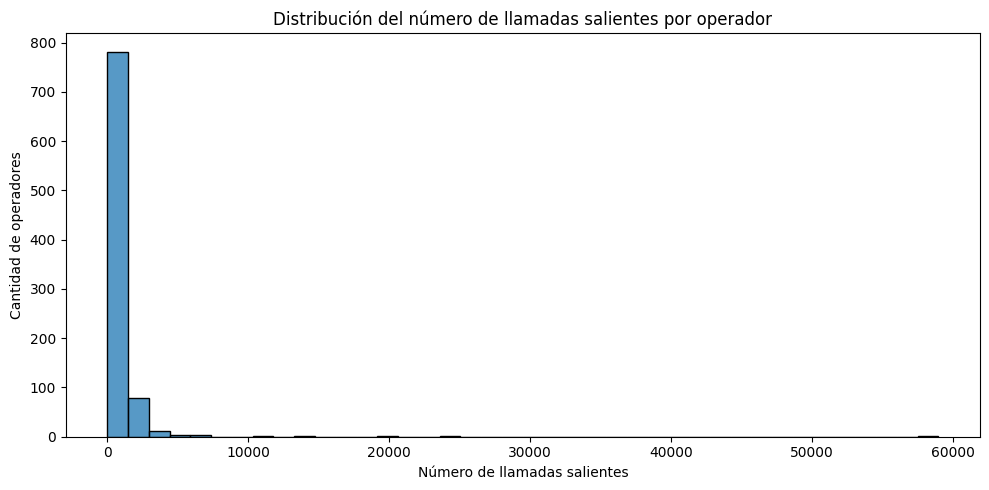

In [113]:
# Visualizamos la distribución del número de llamadas salientes por operador
plt.figure(figsize=(10, 5))

sns.histplot(
    data=outgoing_metrics,
    x='outgoing_calls',
    bins=40)

plt.title('Distribución del número de llamadas salientes por operador')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Observamos una gran concentración de operadores que generan una muy baja cantidad de llamadas salientes, lo cual demuestra una baja eficiencia en la generación de llamadas desde el negocio hacia los clientes, parámetro que se sugiere mejorar.

In [114]:
# Identificamos los operadores con menor número de llamadas salientes
bottom_outgoing_operators = (
    outgoing_metrics
    .sort_values('outgoing_calls', ascending=True)
    .head(20))

bottom_outgoing_operators

,operator_id,outgoing_calls
793,955086,1
841,963716,1
293,914272,1
495,932246,1
168,902238,1
653,941816,1
853,966686,1
654,941826,1
102,895266,1
545,937720,1


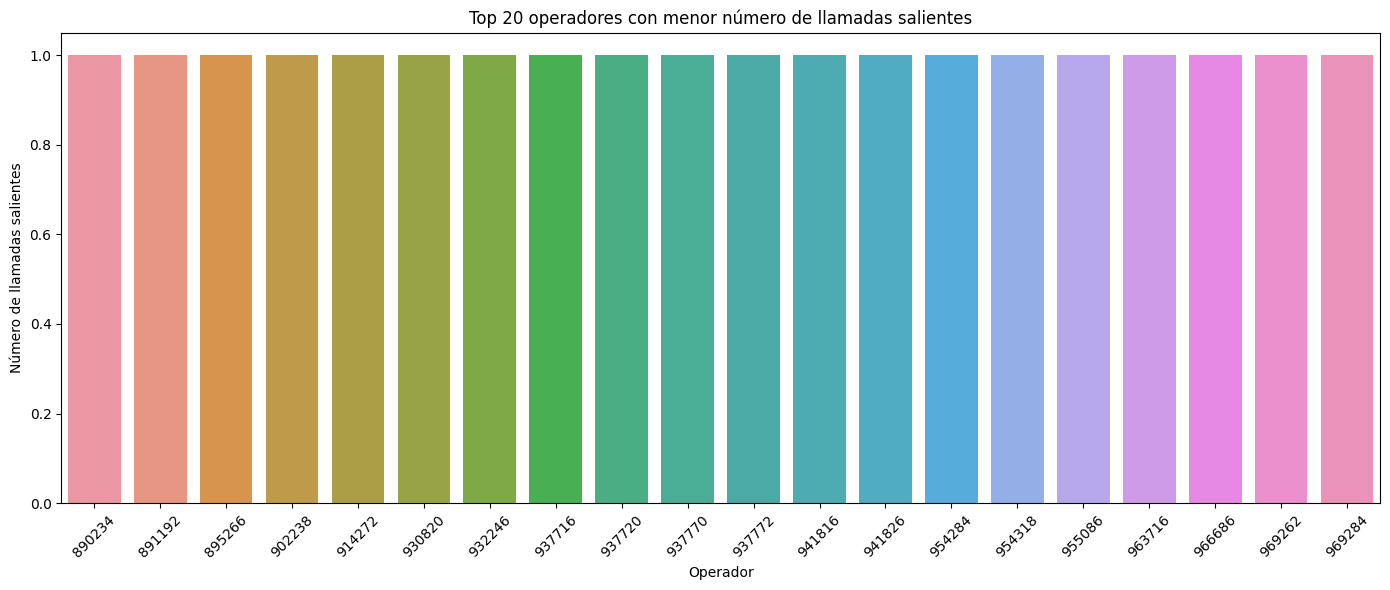

In [115]:
# Visualizamos los 20 operadores con menor número de llamadas salientes
plt.figure(figsize=(14, 6))

sns.barplot(
    data=bottom_outgoing_operators,
    x='operator_id',
    y='outgoing_calls')

plt.title('Top 20 operadores con menor número de llamadas salientes')
plt.xlabel('Operador')
plt.ylabel('Número de llamadas salientes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos que todos los operadores del top 20 han realizado sólo 1 llamada saliente, por lo que procedemos a cuantificar a los operadores que sólo han hecho 1 única llamada saliente.

In [116]:
len(outgoing_metrics[outgoing_metrics['outgoing_calls'] == 1])

61

Encontramos entonces que 61 de los operadores sólo han realizado 1 única llamada saliente, lo cual se encuentra muy inadecuado para la eficiencia de los intereses del negocio. Se sugiere proponer metas mínimas de cumplimiento para este tipo de actividad y así mejorar dicho parámetro de efectividad.

In [117]:
# Consolidamos las métricas clave de ineficiencia en un solo dataframe por operador
operator_inefficiency_metrics = (
    incoming_metrics[['operator_id', 'incoming_calls', 'missed_incoming_calls', 'missed_incoming_rate']]
    .merge(
        incoming_waiting_metrics[['operator_id', 'total_incoming_waiting_time', 'avg_incoming_waiting_time_per_call']],
        on='operator_id',
        how='outer'
    )
    .merge(
        outgoing_metrics[['operator_id', 'outgoing_calls']],
        on='operator_id',
        how='outer'))

# Reemplazamos valores ausentes en métricas de llamadas salientes por cero, ya que un operador sin registros salientes
# no ha realizado llamadas salientes en el periodo analizado
operator_inefficiency_metrics['outgoing_calls'] = (
    operator_inefficiency_metrics['outgoing_calls'].fillna(0))

# Revisamos las primeras filas del dataframe consolidado
operator_inefficiency_metrics.head()

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate,total_incoming_waiting_time,avg_incoming_waiting_time_per_call,outgoing_calls
0,879896,58.0,0.0,0.0,574.0,9.896552,872.0
1,879898,104.0,0.0,0.0,1680.0,16.153846,7209.0
2,880020,7.0,0.0,0.0,54.0,7.714286,38.0
3,880022,8.0,0.0,0.0,112.0,14.000000,189.0
4,880026,24.0,0.0,0.0,143.0,5.958333,2208.0


### 3.2. Umbrales estadísticos

Se definirán umbrales cuantitativos para distinguir entre desempeño aceptable y desempeño ineficiente. Para ello se utilizarán criterios basados en la distribución de las métricas, por ejemplo percentiles altos para indicadores negativos y percentiles bajos para indicadores positivos.

In [118]:
# Revisamos estadísticas descriptivas de las métricas que serán usadas para definir ineficiencia
operator_inefficiency_metrics[
    [
        'incoming_calls',
        'missed_incoming_rate',
        'avg_incoming_waiting_time_per_call',
        'outgoing_calls'
    ]].describe()

,incoming_calls,missed_incoming_rate,avg_incoming_waiting_time_per_call,outgoing_calls
count,754.000000,754.000000,754.000000,1092.000000
mean,124.405836,0.017574,17.491612,557.090659
std,356.450649,0.065324,12.171988,2819.492227
min,1.000000,0.000000,0.683673,0.000000
25%,4.000000,0.000000,9.398782,2.000000
50%,17.000000,0.000000,14.430502,33.000000
75%,78.750000,0.006747,21.838889,355.250000
max,4766.000000,1.000000,115.500000,58977.000000


In [119]:
# Definimos umbrales estadísticos usando percentiles, para métricas negativas, valores altos indican peor desempeño:
# - tasa de llamadas entrantes perdidas
# - tiempo promedio de espera en llamadas entrantes

# Para la tasa de llamadas entrantes perdidas se brindará un percentil más alto debido a que la gran mayoría de operadores ha reportado 
# un valor casi nulo en dicha tasa, de lo contrario el umbral obtenido podría ser demasiado exigente 
missed_rate_threshold = operator_inefficiency_metrics['missed_incoming_rate'].quantile(0.90)

# Para el tiempo promedio de espera en llamadas entrantes, se propone el tercer cuartil
waiting_time_threshold = operator_inefficiency_metrics['avg_incoming_waiting_time_per_call'].quantile(0.75)

# Para llamadas salientes, valores bajos pueden indicar bajo desempeño si el operador debe realizar llamadas salientes.
# Por ello, se usa el percentil 45 como umbral inferior (y así llegar a una cantidad mínima adecuada propuesta)

outgoing_calls_threshold = operator_inefficiency_metrics['outgoing_calls'].quantile(0.45)

print('Umbral P75 de tasa de llamadas entrantes perdidas:', missed_rate_threshold)
print('Umbral P75 de tiempo promedio de espera en llamadas entrantes, minutos:', waiting_time_threshold)
print('Umbral P45 de llamadas salientes:', outgoing_calls_threshold)

Umbral P75 de tasa de llamadas entrantes perdidas: 0.037037037037037035
Umbral P75 de tiempo promedio de espera en llamadas entrantes, minutos: 21.83888888888889
Umbral P45 de llamadas salientes: 20.0


In [120]:
# Creamos un dataframe resumen con los umbrales definidos
thresholds_summary = pd.DataFrame({
    'metric': [
        'missed_incoming_rate',
        'avg_incoming_waiting_time_per_call',
        'outgoing_calls'
    ],
    'criterion': [
        'Mayor que P90',
        'Mayor que P75',
        'Menor que P45'
    ],
    'threshold': [
        missed_rate_threshold,
        waiting_time_threshold,
        outgoing_calls_threshold
    ]})

thresholds_summary

,metric,criterion,threshold
0,missed_incoming_rate,Mayor que P90,0.037037
1,avg_incoming_waiting_time_per_call,Mayor que P75,21.838889
2,outgoing_calls,Menor que P45,20.000000


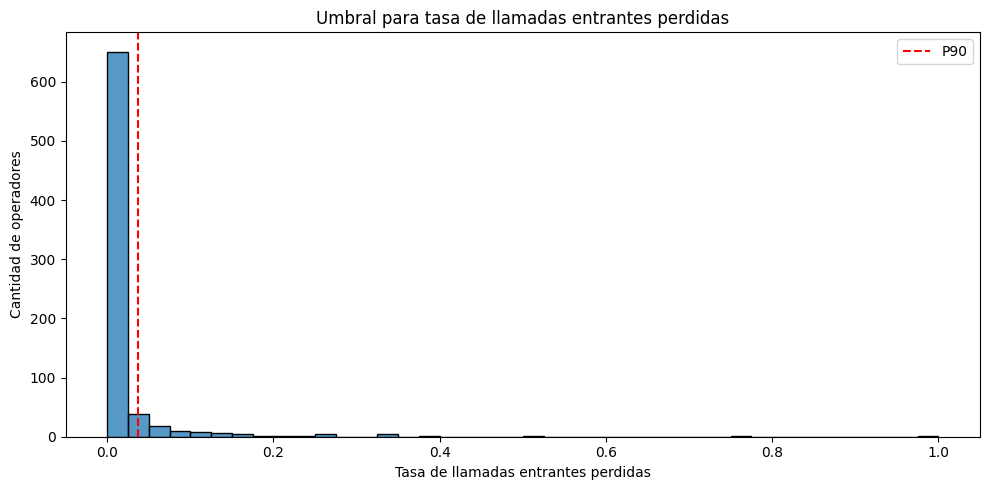

In [121]:
# Visualizamos los umbrales sobre la distribución de la tasa de llamadas entrantes perdidas
plt.figure(figsize=(10, 5))

sns.histplot(
    data=operator_inefficiency_metrics,
    x='missed_incoming_rate',
    bins=40)

plt.axvline(
    missed_rate_threshold,
    color='red',
    linestyle='--',
    label='P90')

plt.title('Umbral para tasa de llamadas entrantes perdidas')
plt.xlabel('Tasa de llamadas entrantes perdidas')
plt.ylabel('Cantidad de operadores')
plt.legend()
plt.tight_layout()
plt.show()

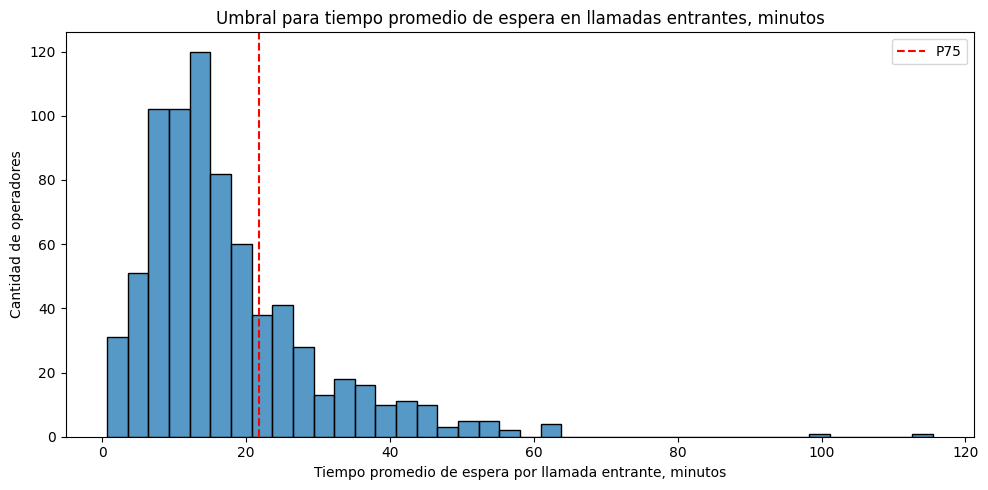

In [122]:
# Visualizamos el umbral sobre la distribución del tiempo promedio de espera en llamadas entrantes
plt.figure(figsize=(10, 5))

sns.histplot(
    data=operator_inefficiency_metrics,
    x='avg_incoming_waiting_time_per_call',
    bins=40)

plt.axvline(
    waiting_time_threshold,
    color='red',
    linestyle='--',
    label='P75')

plt.title('Umbral para tiempo promedio de espera en llamadas entrantes, minutos')
plt.xlabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.ylabel('Cantidad de operadores')
plt.legend()
plt.tight_layout()
plt.show()

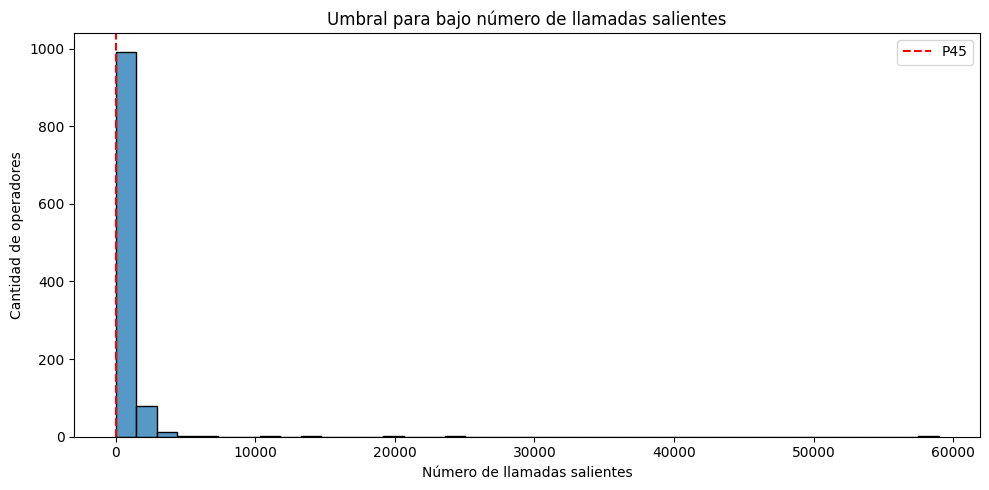

In [123]:
# Visualizamos el umbral sobre la distribución del número de llamadas salientes
plt.figure(figsize=(10, 5))

sns.histplot(
    data=operator_inefficiency_metrics,
    x='outgoing_calls',
    bins=40)

plt.axvline(
    outgoing_calls_threshold,
    color='red',
    linestyle='--',
    label='P45')

plt.title('Umbral para bajo número de llamadas salientes')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Cantidad de operadores')
plt.legend()
plt.tight_layout()
plt.show()

En este último caso, el umbral mínimo se ve aparentemente pequeño debido a que hay operadores que han realizado llamadas salientes en gran volumen, se procede a volver a mostrar la distribución con el umbral, excluyendo valores muy grandes de número de llamadas salientes.

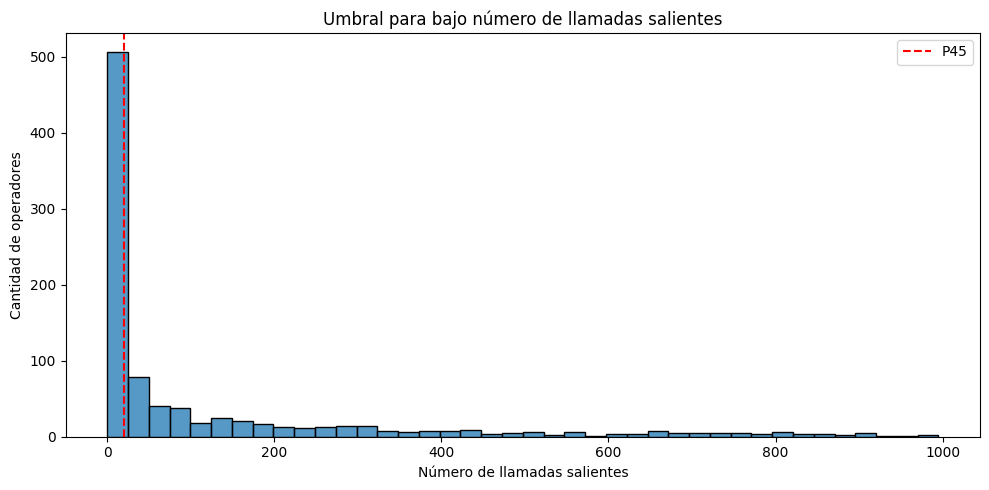

In [124]:
# Visualizamos el umbral sobre la distribución del número de llamadas salientes (limitando visualmente el número de llamadas salientes)
plt.figure(figsize=(10, 5))

sns.histplot(
    data=operator_inefficiency_metrics[operator_inefficiency_metrics['outgoing_calls'] <= 1000] ,
    x='outgoing_calls',
    bins=40)

plt.axvline(
    outgoing_calls_threshold,
    color='red',
    linestyle='--',
    label='P45')

plt.title('Umbral para bajo número de llamadas salientes')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Cantidad de operadores')
plt.legend()
plt.tight_layout()
plt.show()

In [125]:
# Identificamos cuántos operadores quedan marcados por cada criterio individual
operators_high_missed_rate = (operator_inefficiency_metrics['missed_incoming_rate'] > missed_rate_threshold).sum()

operators_high_waiting_time = (operator_inefficiency_metrics['avg_incoming_waiting_time_per_call'] > waiting_time_threshold).sum()

operators_low_outgoing_calls = (operator_inefficiency_metrics['outgoing_calls'] < outgoing_calls_threshold).sum()

print('Operadores con alta tasa de llamadas entrantes perdidas:', operators_high_missed_rate)
print('Operadores con alto tiempo promedio de espera:', operators_high_waiting_time)
print('Operadores con bajo número de llamadas salientes:', operators_low_outgoing_calls)

Operadores con alta tasa de llamadas entrantes perdidas: 74
Operadores con alto tiempo promedio de espera: 189
Operadores con bajo número de llamadas salientes: 489


Se definieron umbrales estadísticos basados en percentiles para identificar posibles señales de ineficiencia. Para las métricas donde valores altos representan peor desempeño, como la tasa de llamadas entrantes perdidas y el tiempo promedio de espera, se utilizaron los percentiles 75 y 90 respectivamente; este último debido a que una gran cantidad de los operarios registraron tasas de pérdida de llamadas cercanas a cero. Para la métrica de llamadas salientes, donde valores bajos pueden representar baja actividad, se utilizó el percentil 45 para plantear una cantidad mínima de al menos 20 llamadas salientes para ser catalogado como operador eficiente bajo este criterio.

Este enfoque permite construir criterios objetivos y reproducibles, evitando definir umbrales arbitrarios. Sin embargo, estos umbrales serán interpretados junto con el contexto operativo, ya que no todos los operadores necesariamente tienen las mismas responsabilidades en llamadas entrantes y salientes.

### 3.3. Reglas de clasificación

Se establecerán reglas concretas para clasificar a un operador como ineficaz. Estas reglas combinarán los umbrales definidos previamente y permitirán construir un criterio reproducible de identificación.

In [126]:
# Se procede a crear indicadores binarios para cada criterio de posible ineficiencia

# Indicador de alta tasa de llamadas entrantes perdidas
operator_inefficiency_metrics['high_missed_rate'] = (operator_inefficiency_metrics['missed_incoming_rate'] > missed_rate_threshold)

# Indicador de alto tiempo promedio de espera en llamadas entrantes
operator_inefficiency_metrics['high_waiting_time'] = (operator_inefficiency_metrics['avg_incoming_waiting_time_per_call'] > waiting_time_threshold)

# Indicador de bajo número de llamadas salientes
operator_inefficiency_metrics['low_outgoing_calls'] = (operator_inefficiency_metrics['outgoing_calls'] < outgoing_calls_threshold)

# Se calcula la cantidad de criterios de ineficiencia cumplidos por cada operador
operator_inefficiency_metrics['inefficiency_criteria_count'] = (operator_inefficiency_metrics[[
            'high_missed_rate',
            'high_waiting_time',
            'low_outgoing_calls'
        ]].sum(axis=1))

# Se procede a clasificar a los operadores como potencialmente ineficaces si cumplen al menos uno de los criterios definidos
operator_inefficiency_metrics['is_inefficient'] = (operator_inefficiency_metrics['inefficiency_criteria_count'] >= 1)

# Revisamos las primeras filas del dataframe actualizado
operator_inefficiency_metrics.head(10)

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate,total_incoming_waiting_time,avg_incoming_waiting_time_per_call,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing_calls,inefficiency_criteria_count,is_inefficient
0,879896,58.0,0.0,0.000000,574.0,9.896552,872.0,False,False,False,0,False
1,879898,104.0,0.0,0.000000,1680.0,16.153846,7209.0,False,False,False,0,False
2,880020,7.0,0.0,0.000000,54.0,7.714286,38.0,False,False,False,0,False
3,880022,8.0,0.0,0.000000,112.0,14.000000,189.0,False,False,False,0,False
4,880026,24.0,0.0,0.000000,143.0,5.958333,2208.0,False,False,False,0,False
5,880028,63.0,0.0,0.000000,343.0,5.444444,2497.0,False,False,False,0,False
6,882476,3.0,0.0,0.000000,95.0,31.666667,0.0,False,True,True,2,True
7,882478,3.0,0.0,0.000000,76.0,25.333333,1.0,False,True,True,2,True
8,882680,99.0,3.0,0.030303,1591.0,16.070707,0.0,False,False,True,1,True
9,882684,613.0,4.0,0.006525,9526.0,15.539967,661.0,False,False,False,0,False


In [127]:
# Calculamos la cantidad de operadores eficientes e ineficientes
inefficiency_summary = (
    operator_inefficiency_metrics['is_inefficient']
    .value_counts()
    .reset_index())

# Renombramos columnas para facilitar interpretación
inefficiency_summary.columns = ['is_inefficient', 'operators_count']

inefficiency_summary

,is_inefficient,operators_count
0,True,592
1,False,500


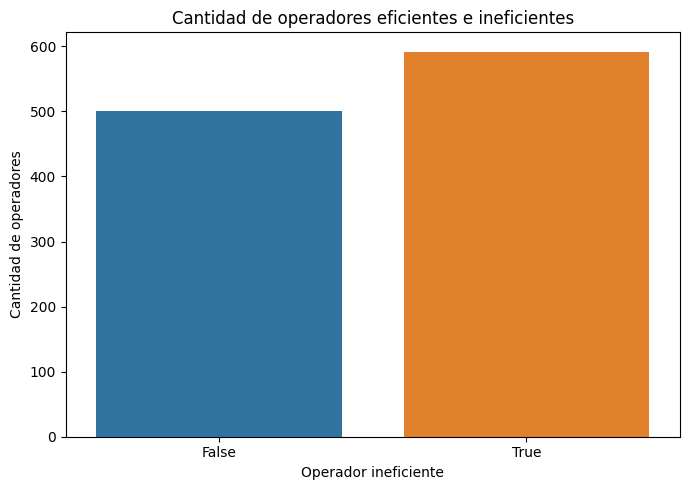

In [128]:
# Visualizamos la cantidad de operadores eficientes e ineficientes
plt.figure(figsize=(7, 5))

sns.barplot(
    data=inefficiency_summary,
    x='is_inefficient',
    y='operators_count')

plt.title('Cantidad de operadores eficientes e ineficientes')
plt.xlabel('Operador ineficiente')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Se encuentra que, incluso luego de ajustar los percentiles para brindar flexibilidad en la categorización de operador eficiente, más de la mitad de estos han sido catalogados como potencialmente ineficientes, lo cual muestra al menos oportunidades de mejora bajo los 3 criterios usados para la presente clasificación.

In [129]:
# Revisamos cuántos operadores cumplen cada cantidad de criterios de ineficiencia
criteria_distribution = (
    operator_inefficiency_metrics['inefficiency_criteria_count']
    .value_counts()
    .sort_index()
    .reset_index())

criteria_distribution.columns = [
    'criteria_count',
    'operators_count']

criteria_distribution

,criteria_count,operators_count
0,0,500
1,1,441
2,2,142
3,3,9


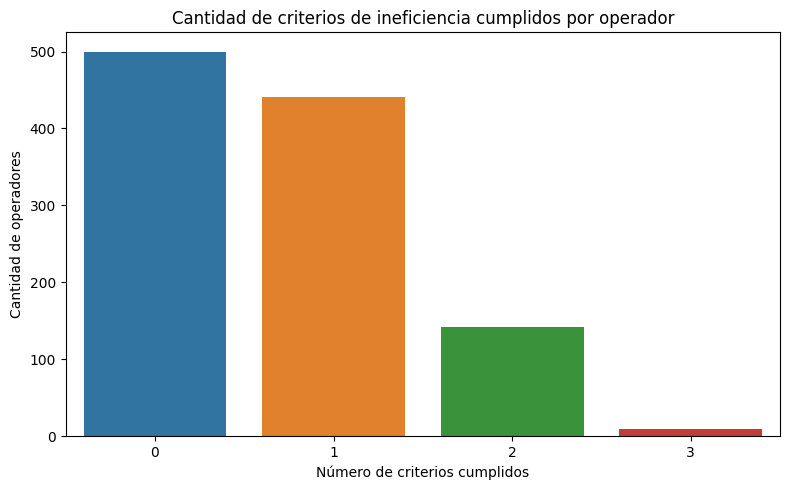

In [130]:
# Visualizamos la distribución de criterios de ineficiencia cumplidos
plt.figure(figsize=(8, 5))

sns.barplot(
    data=criteria_distribution,
    x='criteria_count',
    y='operators_count')

plt.title('Cantidad de criterios de ineficiencia cumplidos por operador')
plt.xlabel('Número de criterios cumplidos')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Encontramos que gran parte de los operadores catalogados como potencialmente ineficaces cumplen con sólo 1 de los criterios de ineficacia, por lo que a dicho grupo puede plantearse la ejecución de capacitaciones laborales con miras a levantar la alerta de ineficacia que poseen. De forma similar y a mediano plazo, puede plantearse la misma solución para los operadores que cumplen con 2 criterios de ineficacia. En el caso de los 9 operadores con todas las alertas de ineficacia activadas, dado que representan una cantidad muy pequeña respecto del total; y dado que levantar su ineficacia múltiple representaría un esfuerzo (e inversión) importante por parte de la empresa es que se sugiere no prolongar la contratación de dichos trabajadores que generan alto riesgo a los interes del negocio.

In [131]:
# Filtramos únicamente operadores clasificados como ineficaces
inefficient_operators = (
    operator_inefficiency_metrics[
        operator_inefficiency_metrics['is_inefficient'] == True
    ].copy())

# Revisamos las primeras filas de operadores ineficaces
inefficient_operators.head()

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate,total_incoming_waiting_time,avg_incoming_waiting_time_per_call,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing_calls,inefficiency_criteria_count,is_inefficient
6,882476,3.0,0.0,0.000000,95.0,31.666667,0.0,False,True,True,2,True
7,882478,3.0,0.0,0.000000,76.0,25.333333,1.0,False,True,True,2,True
8,882680,99.0,3.0,0.030303,1591.0,16.070707,0.0,False,False,True,1,True
11,882688,15.0,0.0,0.000000,673.0,44.866667,43.0,False,True,False,1,True
12,882690,171.0,2.0,0.011696,7102.0,41.532164,1417.0,False,True,False,1,True


In [132]:
# Ordenamos operadores ineficaces según cantidad de criterios cumplidos y luego según tasa de llamadas perdidas
inefficient_operators = (
    inefficient_operators
    .sort_values(
        [
            'inefficiency_criteria_count',
            'missed_incoming_rate',
            'avg_incoming_waiting_time_per_call'
        ], ascending=[False, False, False]))

inefficient_operators.head(10)

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate,total_incoming_waiting_time,avg_incoming_waiting_time_per_call,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing_calls,inefficiency_criteria_count,is_inefficient
467,934098,6.0,2.0,0.333333,159.0,26.500000,0.0,True,True,True,3,True
189,905300,25.0,6.0,0.240000,552.0,22.080000,0.0,True,True,True,3,True
494,937368,22.0,4.0,0.181818,531.0,24.136364,10.0,True,True,True,3,True
269,911102,27.0,3.0,0.111111,822.0,30.444444,0.0,True,True,True,3,True
31,888406,9.0,1.0,0.111111,255.0,28.333333,6.0,True,True,True,3,True
274,911142,20.0,2.0,0.100000,923.0,46.150000,0.0,True,True,True,3,True
466,934076,11.0,1.0,0.090909,311.0,28.272727,0.0,True,True,True,3,True
106,896538,14.0,1.0,0.071429,665.0,47.500000,0.0,True,True,True,3,True
77,894120,18.0,1.0,0.055556,428.0,23.777778,0.0,True,True,True,3,True
185,904344,4.0,3.0,0.750000,55.0,13.750000,5.0,True,False,True,2,True


In [133]:
# Calculamos el porcentaje de operadores clasificados como ineficaces
inefficient_rate = (
    inefficient_operators.shape[0] /
    operator_inefficiency_metrics.shape[0])

print(
    'Porcentaje de operadores clasificados como ineficaces:',
    round(inefficient_rate * 100, 2),
    '%'
)

Porcentaje de operadores clasificados como ineficaces: 54.21 %


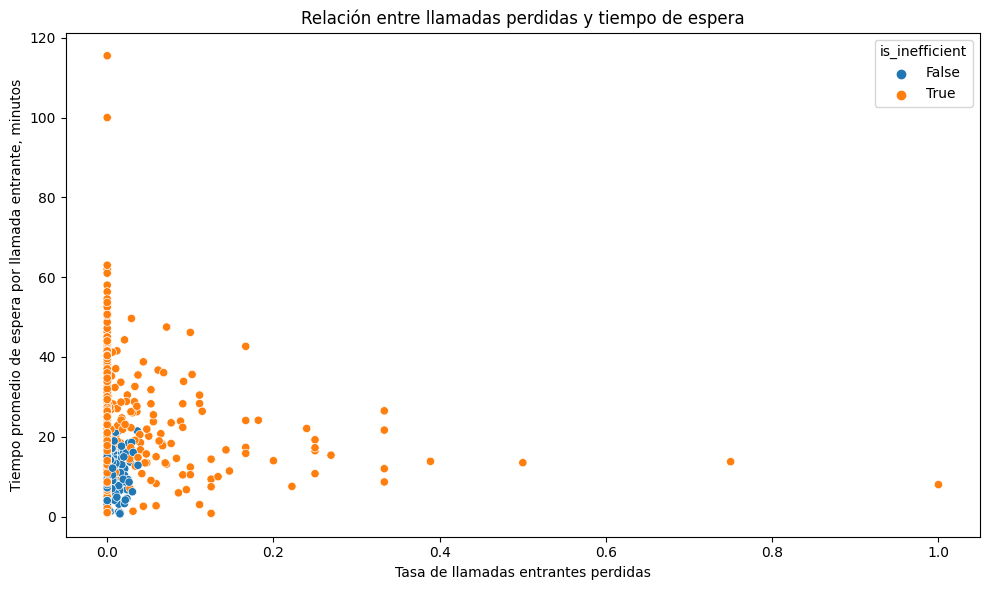

In [134]:
# Analizamos la relación entre tasa de llamadas perdidas y tiempo promedio de espera en operadores

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=operator_inefficiency_metrics,
    x='missed_incoming_rate',
    y='avg_incoming_waiting_time_per_call',
    hue='is_inefficient')

plt.title('Relación entre llamadas perdidas y tiempo de espera')
plt.xlabel('Tasa de llamadas entrantes perdidas')
plt.ylabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.tight_layout()
plt.show()

Observamos en el gráfico de dispersión de datos que los operadores catalogados como eficientes se concentran en la zona cercana al origen de coordenadas, lo cual significa que tienden a poseer bajos valores de la tasa de llamadas entrantes perdidas y del tiempo promedio de espera por llamada entrante, lo cual es compatible con su clasificación. En el caso de los operadores catalogados como potencialmente ineficientes, existe una gran dispersión ya que hay 3 criterios usados para su clasificación y por ello pueden ubicarse casi en cualquier lugar del gráfico.

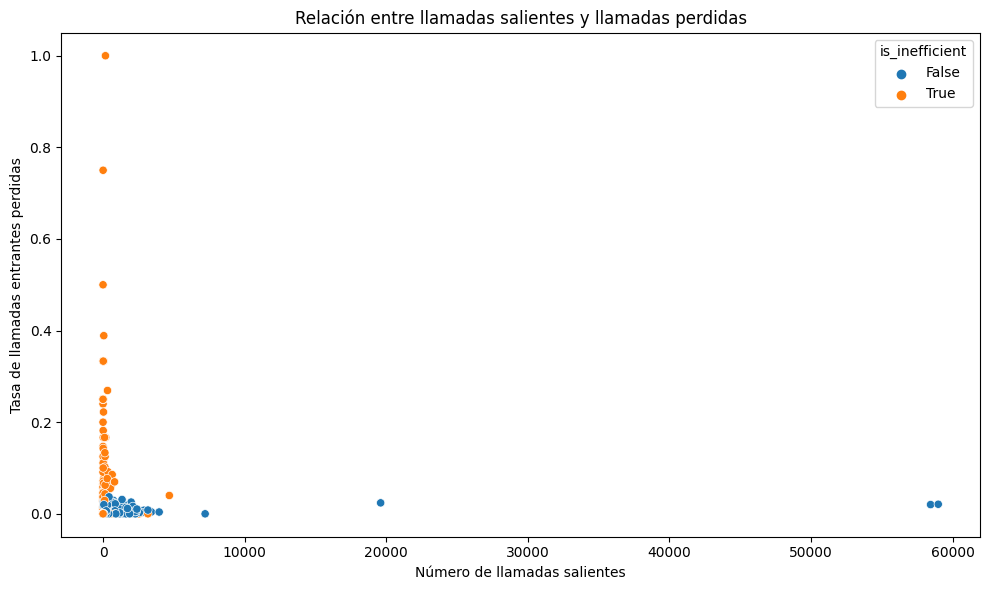

In [135]:
# Analizamos la relación entre llamadas salientes y tasa de llamadas perdidas

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=operator_inefficiency_metrics,
    x='outgoing_calls',
    y='missed_incoming_rate',
    hue='is_inefficient')

plt.title('Relación entre llamadas salientes y llamadas perdidas')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Tasa de llamadas entrantes perdidas')
plt.tight_layout()
plt.show()

En este caso, vemos la tendencia de los operadores clasificados como eficientes a presentar mayor número de llamadas salientes respecto de los operadores potencialmente ineficientes; estos últimos, a su vez, muestran una clara tendencia a presentar una intermedia y elevada tasa de llamadas entrantes perdidas, acorde con su clasificación negativa.

Se clasificaron como operadores potencialmente ineficaces aquellos que cumplían al menos uno de los criterios definidos mediante los umbrales estadísticos previamente establecidos.

Los criterios utilizados fueron:
- Alta tasa de llamadas entrantes perdidas;
- Alto tiempo promedio de espera en llamadas entrantes;
- Bajo número de llamadas salientes.

Este enfoque permite identificar operadores con posibles señales de bajo desempeño operativo. Sin embargo, los resultados deben interpretarse considerando el contexto funcional de cada operador, ya que no todos necesariamente desempeñan las mismas tareas dentro del sistema telefónico.

## Paso 4. Identificación de operadores ineficaces

### 4.1. Aplicación de reglas de ineficiencia

Se aplicarán las reglas de clasificación sobre la tabla resumen por operador. El objetivo será identificar de manera objetiva qué operadores cumplen con los criterios de ineficiencia.

In [136]:
# Verificamos las columnas disponibles en el dataframe de métricas de ineficiencia
operator_inefficiency_metrics.columns

Index(['operator_id', 'incoming_calls', 'missed_incoming_calls',
       'missed_incoming_rate', 'total_incoming_waiting_time',
       'avg_incoming_waiting_time_per_call', 'outgoing_calls',
       'high_missed_rate', 'high_waiting_time', 'low_outgoing_calls',
       'inefficiency_criteria_count', 'is_inefficient'],
      dtype='object')

In [137]:
# Aplicamos nuevamente las reglas de ineficiencia de forma explícita para así dejar trazabilidad clara de cómo se clasifican los operadores

operator_inefficiency_metrics['high_missed_rate'] = (
    operator_inefficiency_metrics['missed_incoming_rate'] > missed_rate_threshold)

operator_inefficiency_metrics['high_waiting_time'] = (
    operator_inefficiency_metrics['avg_incoming_waiting_time_per_call'] > waiting_time_threshold)

operator_inefficiency_metrics['low_outgoing_calls'] = (
    operator_inefficiency_metrics['outgoing_calls'] < outgoing_calls_threshold)

# Calculamos cuántos criterios de ineficiencia cumple cada operador
operator_inefficiency_metrics['inefficiency_criteria_count'] = (
    operator_inefficiency_metrics[
        [
            'high_missed_rate',
            'high_waiting_time',
            'low_outgoing_calls'
        ]].sum(axis=1))

# Revisamos cuántos operadores cumplen cada criterio individual
criteria_summary = pd.DataFrame({
    'criterion': [
        'Alta tasa de llamadas entrantes perdidas',
        'Alto tiempo promedio de espera',
        'Bajo número de llamadas salientes'
    ],
    'operators_count': [
        operator_inefficiency_metrics['high_missed_rate'].sum(),
        operator_inefficiency_metrics['high_waiting_time'].sum(),
        operator_inefficiency_metrics['low_outgoing_calls'].sum()
    ]})

criteria_summary

,criterion,operators_count
0,Alta tasa de llamadas entrantes perdidas,74
1,Alto tiempo promedio de espera,189
2,Bajo número de llamadas salientes,489


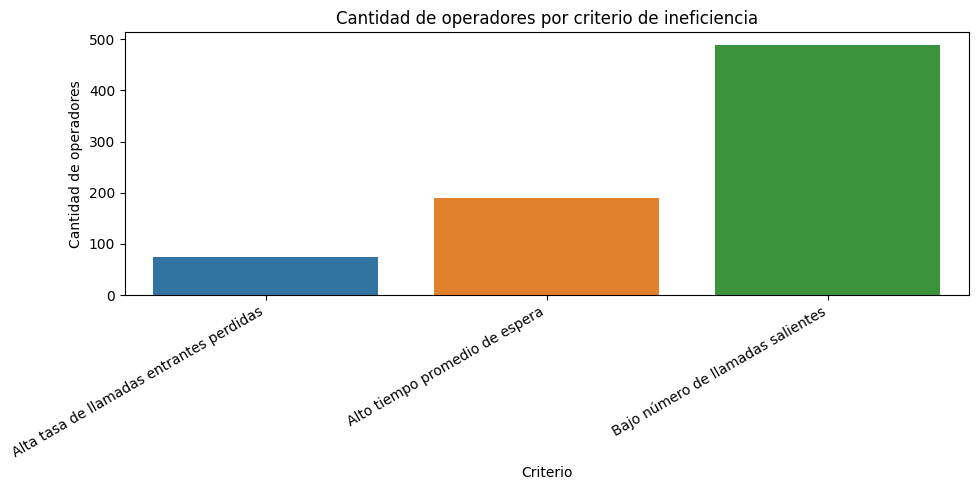

In [138]:
# Visualizamos la cantidad de operadores afectados por cada criterio de ineficiencia
plt.figure(figsize=(10, 5))

sns.barplot(
    data=criteria_summary,
    x='criterion',
    y='operators_count')

plt.title('Cantidad de operadores por criterio de ineficiencia')
plt.xlabel('Criterio')
plt.ylabel('Cantidad de operadores')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Encontramos que la baja cantidad de llamadas salientes por parte de los operadores ha sido la principal causa de la clasificación como potencialmente ineficientes; problema que puede subsanarse mediante capacitaciones internas y metas propuestas sobre la cantidad mínima, la cual sería el umbral mínimo planteado en el capítulo anterior.

### 4.2. Creación de variable de clasificación

Se generará una variable que indique si cada operador es eficiente o ineficiente. Esta variable facilitará comparaciones posteriores, visualizaciones y pruebas estadísticas entre grupos.

In [139]:
# Creamos la variable final de clasificación en donde un operador será clasificado como ineficaz si cumple al menos uno de los criterios definidos
operator_inefficiency_metrics['is_inefficient'] = (
    operator_inefficiency_metrics['inefficiency_criteria_count'] >= 1)

# Creamos una variable categórica para facilitar la lectura de resultados y gráficos
operator_inefficiency_metrics['operator_status'] = np.where(
    operator_inefficiency_metrics['is_inefficient'],
    'inefficient', 'efficient')

# Creamos una columna que describe los motivos por los cuales un operador fue clasificado como ineficaz
def get_inefficiency_reasons(row):
    reasons = []
    
    if row['high_missed_rate']:
        reasons.append('high_missed_rate')
    if row['high_waiting_time']:
        reasons.append('high_waiting_time')
    if row['low_outgoing_calls']:
        reasons.append('low_outgoing_calls')
    if len(reasons) == 0:
        return 'no_criteria'
    return ', '.join(reasons)

operator_inefficiency_metrics['inefficiency_reasons'] = (
    operator_inefficiency_metrics.apply(get_inefficiency_reasons, axis=1))

# Revisamos la distribución final de operadores eficientes e ineficientes
operator_status_summary = (
    operator_inefficiency_metrics['operator_status']
    .value_counts()
    .reset_index())

operator_status_summary.columns = ['operator_status', 'operators_count']

operator_status_summary

,operator_status,operators_count
0,inefficient,592
1,efficient,500


In [140]:
# Calculamos el porcentaje de operadores por estado
operator_status_summary['percentage'] = (
    operator_status_summary['operators_count'] /
    operator_status_summary['operators_count'].sum() * 100)

operator_status_summary

,operator_status,operators_count,percentage
0,inefficient,592,54.212454
1,efficient,500,45.787546


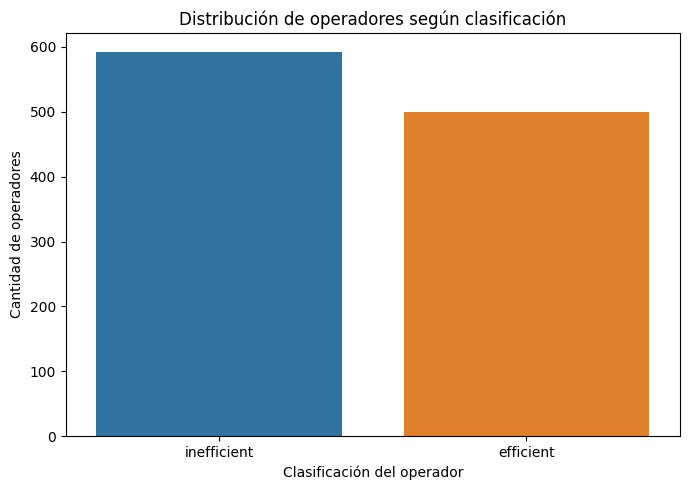

In [141]:
# Visualizamos la distribución de operadores eficientes e ineficientes
plt.figure(figsize=(7, 5))

sns.barplot(
    data=operator_status_summary,
    x='operator_status',
    y='operators_count')

plt.title('Distribución de operadores según clasificación')
plt.xlabel('Clasificación del operador')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

Reafirmamos que, bajo los criterios actuales, hay una mayor cantidad de operadores potencialmente ineficientes por sobre los operarios que cumplen los 3 umbrales anteriormente planteados.

In [142]:
# Revisamos ejemplos de operadores clasificados como ineficaces
operator_inefficiency_metrics[
    operator_inefficiency_metrics['is_inefficient']].head()

,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate,total_incoming_waiting_time,avg_incoming_waiting_time_per_call,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing_calls,inefficiency_criteria_count,is_inefficient,operator_status,inefficiency_reasons
6,882476,3.0,0.0,0.000000,95.0,31.666667,0.0,False,True,True,2,True,inefficient,"high_waiting_time, low_outgoing_calls"
7,882478,3.0,0.0,0.000000,76.0,25.333333,1.0,False,True,True,2,True,inefficient,"high_waiting_time, low_outgoing_calls"
8,882680,99.0,3.0,0.030303,1591.0,16.070707,0.0,False,False,True,1,True,inefficient,low_outgoing_calls
11,882688,15.0,0.0,0.000000,673.0,44.866667,43.0,False,True,False,1,True,inefficient,high_waiting_time
12,882690,171.0,2.0,0.011696,7102.0,41.532164,1417.0,False,True,False,1,True,inefficient,high_waiting_time


### 4.3. Generación de ranking de desempeño

Se ordenarán los operadores según sus métricas de desempeño, de modo que sea posible identificar cuáles presentan los peores resultados y cuáles se encuentran en mejor situación relativa.

In [143]:
# Filtramos únicamente operadores clasificados como ineficaces
inefficient_operators = (
    operator_inefficiency_metrics[
        operator_inefficiency_metrics['is_inefficient']
    ].copy())

# Generamos un ranking de operadores ineficaces
# El orden prioriza:
# 1. Mayor cantidad de criterios incumplidos
# 2. Mayor tasa de llamadas entrantes perdidas
# 3. Mayor tiempo promedio de espera
# 4. Menor número de llamadas salientes

inefficient_operators_ranking = (
    inefficient_operators
    .sort_values(
        by=[
            'inefficiency_criteria_count',
            'missed_incoming_rate',
            'avg_incoming_waiting_time_per_call',
            'outgoing_calls'
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    ).reset_index(drop=True))

# Agregamos una posición de ranking para facilitar la lectura
inefficient_operators_ranking['rank'] = inefficient_operators_ranking.index + 1

# Seleccionamos las columnas más relevantes para presentar el ranking final
inefficient_operators_ranking = inefficient_operators_ranking[[
        'rank',
        'operator_id',
        'incoming_calls',
        'missed_incoming_calls',
        'missed_incoming_rate',
        'avg_incoming_waiting_time_per_call',
        'outgoing_calls',
        'high_missed_rate',
        'high_waiting_time',
        'low_outgoing_calls',
        'inefficiency_criteria_count',
        'inefficiency_reasons'
    ]]

# Mostramos los 20 operadores con mayor prioridad de revisión
inefficient_operators_ranking.head(20)

,rank,operator_id,incoming_calls,missed_incoming_calls,missed_incoming_rate,avg_incoming_waiting_time_per_call,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing_calls,inefficiency_criteria_count,inefficiency_reasons
0,1,934098,6.0,2.0,0.333333,26.500000,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
1,2,905300,25.0,6.0,0.240000,22.080000,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
2,3,937368,22.0,4.0,0.181818,24.136364,10.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
3,4,911102,27.0,3.0,0.111111,30.444444,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
4,5,888406,9.0,1.0,0.111111,28.333333,6.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
5,6,911142,20.0,2.0,0.100000,46.150000,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
6,7,934076,11.0,1.0,0.090909,28.272727,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
7,8,896538,14.0,1.0,0.071429,47.500000,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
8,9,894120,18.0,1.0,0.055556,23.777778,0.0,True,True,True,3,"high_missed_rate, high_waiting_time, low_outgo..."
9,10,904344,4.0,3.0,0.750000,13.750000,5.0,True,False,True,2,"high_missed_rate, low_outgoing_calls"


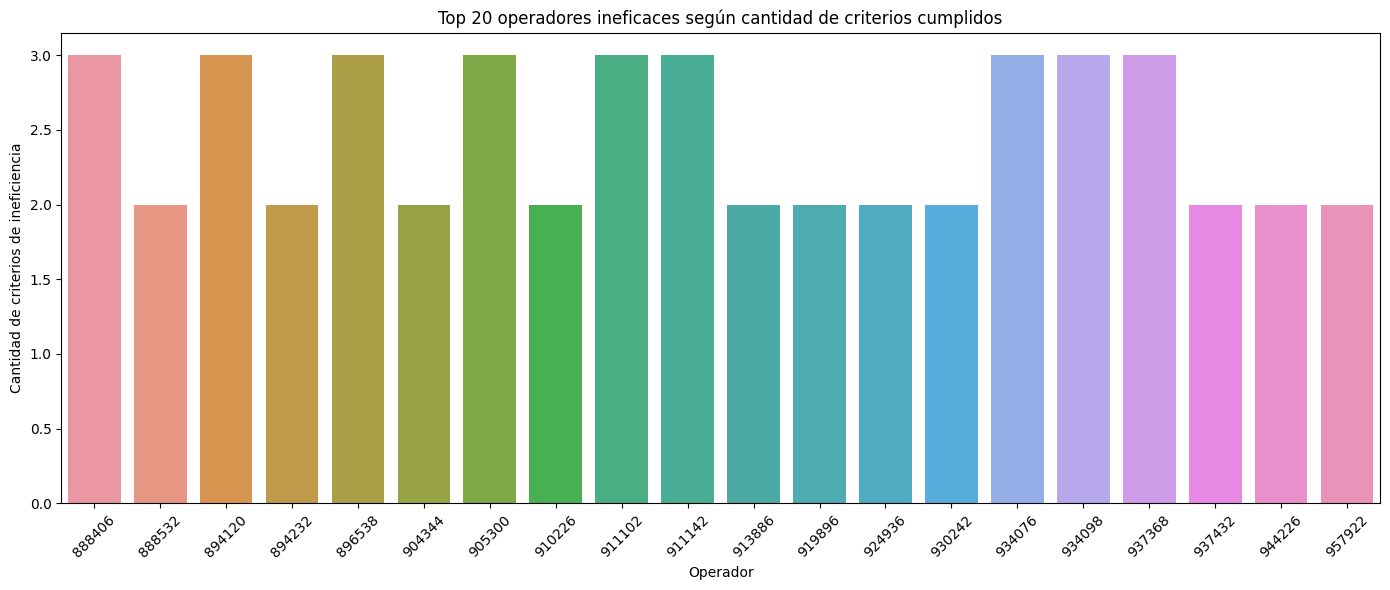

In [144]:
# Visualizamos los 20 operadores ineficaces con mayor prioridad según cantidad de criterios cumplidos
plt.figure(figsize=(14, 6))

sns.barplot(
    data=inefficient_operators_ranking.head(20),
    x='operator_id',
    y='inefficiency_criteria_count')

plt.title('Top 20 operadores ineficaces según cantidad de criterios cumplidos')
plt.xlabel('Operador')
plt.ylabel('Cantidad de criterios de ineficiencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Verificamos que 9 de los operadores clasificados como potencialmente ineficientes alcanzan los criterios de ineficiencia; por lo tanto, se encontrarían en un estado crítico respecto de la posibilidad de cumplir con objetivos mínimos en la empresa. El resto del top 20 cumple con 2 de los criterios, los cuales podrían subsanarse a mediano plazo (lo cual se sugiere evaluarse y que dichos operadores estén bajo observación a corto plazo para que puedan mostrar mejoría en los criterios que actualmente están fallando).

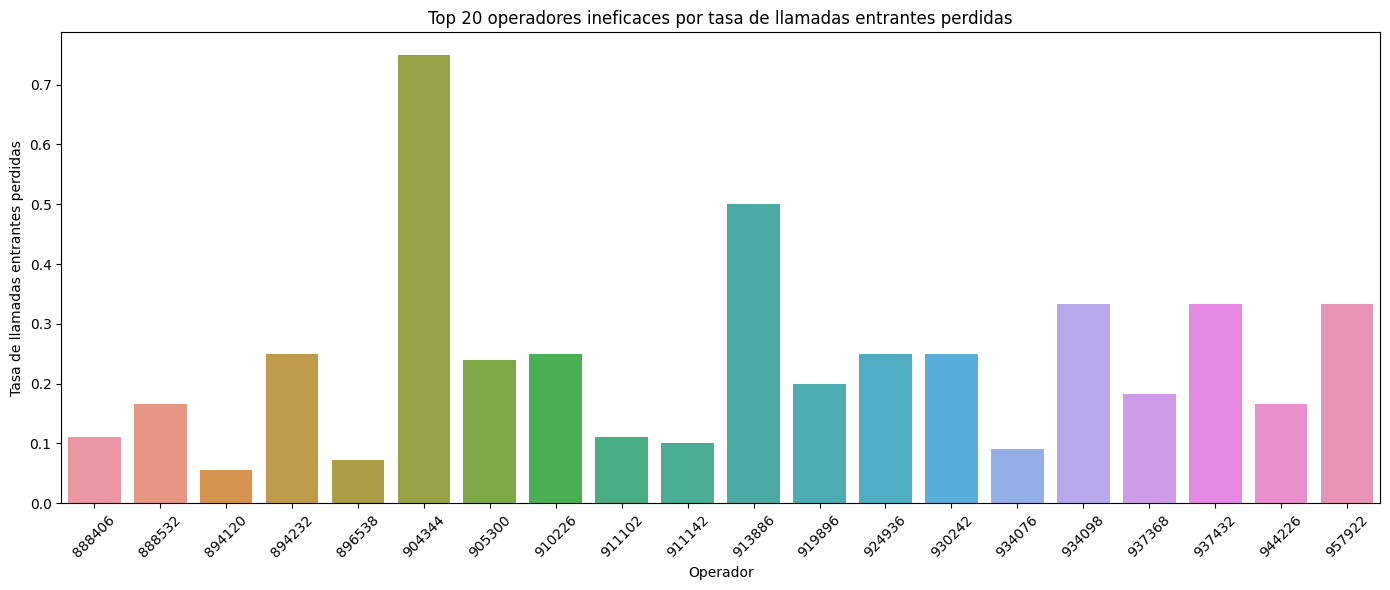

In [145]:
# Visualizamos los 20 operadores ineficaces con mayor tasa de llamadas entrantes perdidas
plt.figure(figsize=(14, 6))

sns.barplot(
    data=inefficient_operators_ranking.head(20),
    x='operator_id',
    y='missed_incoming_rate')

plt.title('Top 20 operadores ineficaces por tasa de llamadas entrantes perdidas')
plt.xlabel('Operador')
plt.ylabel('Tasa de llamadas entrantes perdidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se verifica que al menos uno de los operadores genera más del 70 % de llamadas entrantes perdidas, seguido de una tasa problemática de aproximadamente 50 %. En el resto del top se encuentran tasas cercanas o menores al 30 %, lo cual podría mejorarse a corto plazo mediante el planteamiento de objetivos mínimos referidos a la atención de las llamadas entrantes en los casos específicos de operadores que presentan este problema.

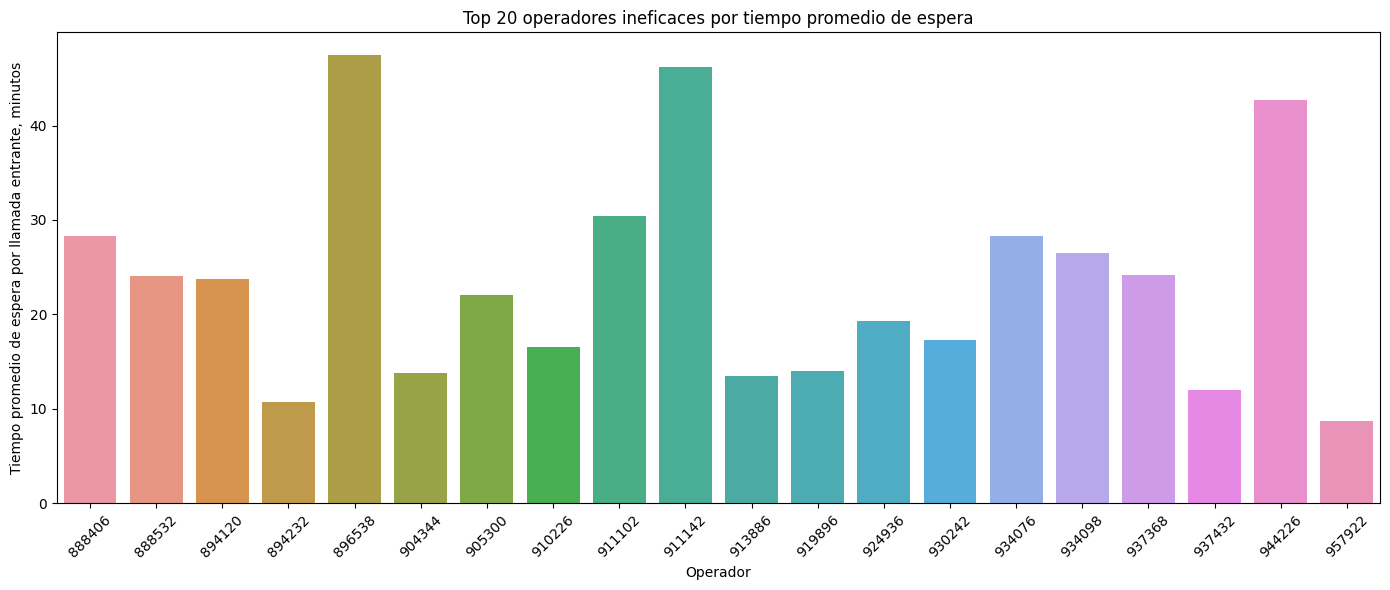

In [146]:
# Visualizamos los 20 operadores ineficaces con mayor tiempo promedio de espera
plt.figure(figsize=(14, 6))

sns.barplot(
    data=inefficient_operators_ranking.head(20),
    x='operator_id',
    y='avg_incoming_waiting_time_per_call')

plt.title('Top 20 operadores ineficaces por tiempo promedio de espera')
plt.xlabel('Operador')
plt.ylabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Encontramos que 3 de los operadores generan un tiempo promedio de espera por llamada entrante de aproximadamente 45 minutos, lo cual puede resultar excesivo para una adecuada atención de la llamada. Se sugiere verificar en los casos encontrados si dicha demora es por causa logística (problemas en los equipos telefónicos, conectividad, etc.) o quizás problemas en la adecuada capacitación de los trabajadores.

In [147]:
# Revisamos cuántos operadores cumplen combinaciones específicas de criterios
inefficiency_reason_summary = (
    operator_inefficiency_metrics
    .groupby('inefficiency_reasons')
    .agg(operators_count=('operator_id', 'count'))
    .reset_index()
    .sort_values('operators_count', ascending=False))

inefficiency_reason_summary

,inefficiency_reasons,operators_count
7,no_criteria,500
6,low_outgoing_calls,353
5,"high_waiting_time, low_outgoing_calls",103
4,high_waiting_time,62
0,high_missed_rate,26
3,"high_missed_rate, low_outgoing_calls",24
1,"high_missed_rate, high_waiting_time",15
2,"high_missed_rate, high_waiting_time, low_outgo...",9


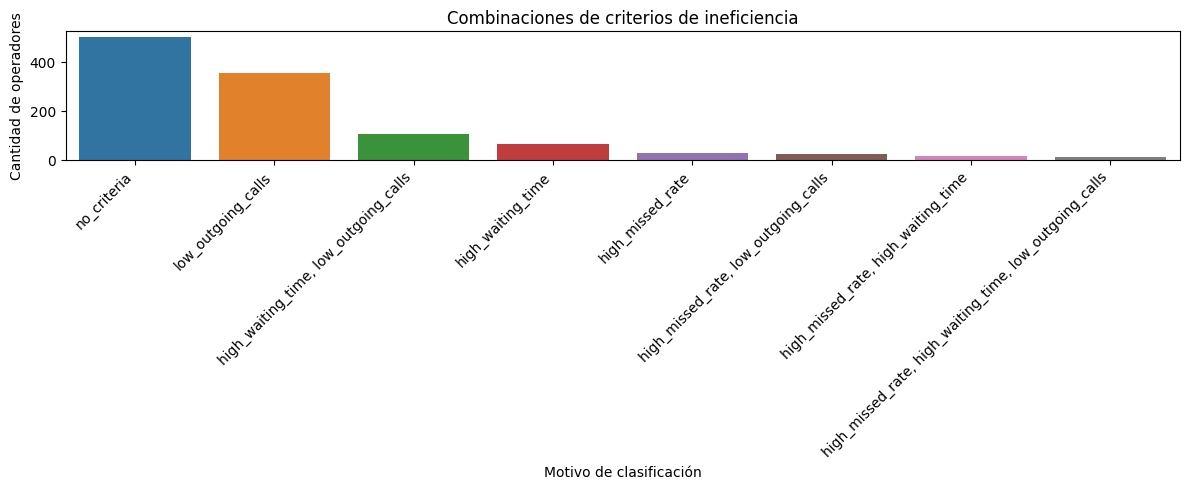

In [148]:
# Visualizamos las combinaciones más frecuentes de criterios de ineficiencia
plt.figure(figsize=(12, 5))

sns.barplot(
    data=inefficiency_reason_summary,
    x='inefficiency_reasons',
    y='operators_count')

plt.title('Combinaciones de criterios de ineficiencia')
plt.xlabel('Motivo de clasificación')
plt.ylabel('Cantidad de operadores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Encontramos que la baja cantidad de llamadas salientes y el alto tiempo de espera son los motivos con mayor presencia en el comportamiento de los operadores catalogados como potencialmente ineficientes.

A partir de las reglas definidas previamente, se clasificaron los operadores según el cumplimiento de criterios de ineficiencia. Además de identificar si un operador es ineficaz o no, se construyó un ranking de prioridad que permite reconocer qué operadores deberían ser revisados primero por los supervisores.

Este ranking considera tanto la cantidad de criterios incumplidos como la severidad de las métricas asociadas a llamadas perdidas, tiempo de espera y baja actividad saliente.

## Paso 5. Análisis del desempeño

### 5.1. Análisis por cliente

Se evaluará si ciertos clientes concentran una mayor cantidad de operadores ineficaces o peores métricas operativas. Esto ayudará a distinguir entre ineficiencia individual y problemas contextuales asociados a cuentas específicas.

In [149]:
# Combinamos las métricas de ineficiencia por operador con la información de llamadas para identificar si ciertos clientes concentran operadores ineficaces
calls_with_operator_status = calls.merge(
    operator_inefficiency_metrics[
        [
            'operator_id',
            'is_inefficient',
            'operator_status',
            'inefficiency_criteria_count'
        ]
    ],
    on='operator_id',
    how='left')

# Revisamos si existen registros sin clasificación de operador, esto puede ocurrir especialmente para registros con operator_id = 'unknown'
calls_with_operator_status[['operator_id', 'is_inefficient', 'operator_status']].isna().sum()

operator_id           0
is_inefficient     7456
operator_status    7456
dtype: int64

In [150]:
# Reemplazamos valores ausentes de clasificación para operadores no identificados
# Esto evita confundir operadores desconocidos con operadores eficientes o ineficientes

calls_with_operator_status['operator_status'] = (
    calls_with_operator_status['operator_status']
    .fillna('unknown'))

calls_with_operator_status['is_inefficient'] = (
    calls_with_operator_status['is_inefficient']
    .fillna(False))

calls_with_operator_status['inefficiency_criteria_count'] = (
    calls_with_operator_status['inefficiency_criteria_count']
    .fillna(0))

In [151]:
# Agrupamos las llamadas por cliente para evaluar si algunos clientes concentran mayor carga y mayor presencia de operadores clasificados como ineficaces
client_inefficiency_summary = (
    calls_with_operator_status
    .groupby('user_id')
    .agg(
        total_records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        total_waiting_time=('waiting_time', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean'),
        unique_operators=('operator_id', 'nunique'),
        inefficient_operator_records=('is_inefficient', 'sum')
    ).reset_index())

# Calculamos tasa de llamadas perdidas y proporción de registros atendidos por operadores ineficaces
client_inefficiency_summary['missed_rate'] = (
    client_inefficiency_summary['missed_calls'] /
    client_inefficiency_summary['total_calls'])

client_inefficiency_summary['inefficient_operator_record_rate'] = (
    client_inefficiency_summary['inefficient_operator_records'] /
    client_inefficiency_summary['total_records'])

client_inefficiency_summary.head()

,user_id,total_records,total_calls,missed_calls,total_waiting_time,avg_waiting_time_per_call,unique_operators,inefficient_operator_records,missed_rate,inefficient_operator_record_rate
0,166377,519,5149,1880,70234,13.817241,6,0,0.365119,0.000000
1,166391,20,27,21,669,20.508333,3,6,0.777778,0.300000
2,166392,93,209,107,3730,19.424851,4,47,0.511962,0.505376
3,166399,20,24,11,545,23.925000,2,9,0.458333,0.450000
4,166405,962,17536,8900,300691,19.162654,11,236,0.507527,0.245322


In [152]:
# Identificamos los clientes con mayor proporción de registros vinculados a operadores ineficaces
# Se filtran clientes con un mínimo de 20 registros para evitar conclusiones basadas en muy pocos datos

top_clients_inefficiency = (
    client_inefficiency_summary[
        client_inefficiency_summary['total_records'] >= 20
    ]
    .sort_values(
        'inefficient_operator_record_rate',
        ascending=False
    )
    .head(20)
)

top_clients_inefficiency

,user_id,total_records,total_calls,missed_calls,total_waiting_time,avg_waiting_time_per_call,unique_operators,inefficient_operator_records,missed_rate,inefficient_operator_record_rate
215,167930,27,40,14,516,13.802469,5,25,0.350000,0.925926
225,167977,517,2318,584,64098,28.045604,6,469,0.251941,0.907157
27,166619,32,55,18,353,7.257813,2,29,0.327273,0.906250
68,166916,1204,6423,1683,103262,15.168260,17,1068,0.262027,0.887043
280,168315,22,416,7,467,1.160242,2,19,0.016827,0.863636
171,167575,26,103,75,148,4.815934,3,22,0.728155,0.846154
170,167551,68,363,186,6850,19.647611,3,57,0.512397,0.838235
84,167002,123,316,179,6158,20.322861,2,103,0.566456,0.837398
81,166985,35,54,7,826,16.200000,2,29,0.129630,0.828571
216,167936,22,44,13,902,17.678788,2,18,0.295455,0.818182


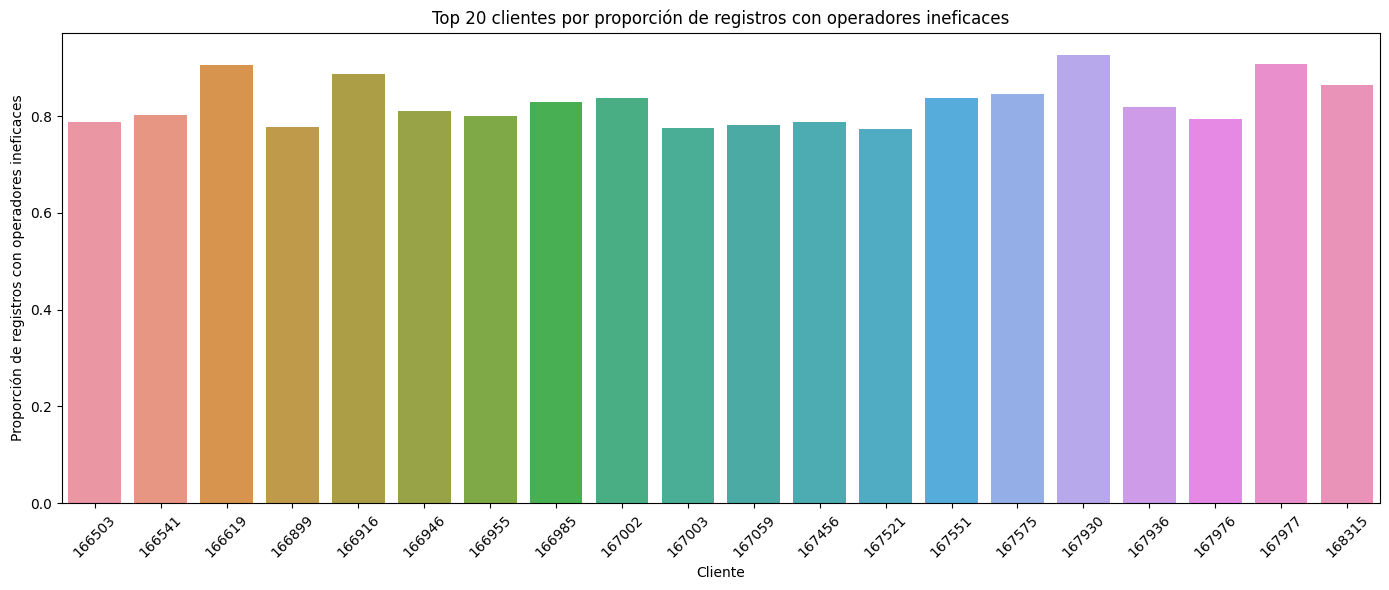

In [153]:
# Visualizamos los clientes con mayor proporción de registros asociados a operadores ineficaces

plt.figure(figsize=(14, 6))

sns.barplot(
    data=top_clients_inefficiency,
    x='user_id',
    y='inefficient_operator_record_rate')

plt.title('Top 20 clientes por proporción de registros con operadores ineficaces')
plt.xlabel('Cliente')
plt.ylabel('Proporción de registros con operadores ineficaces')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Aproximadamente, los clientes que tienen llamadas con operadores ineficientes poseen una proporción cercana al 80 %, lo cual muestra evidencia de que sí existen usuarios que concentran operadores ineficientes.

In [154]:
# Combinamos el resumen por cliente con información del plan tarifario para enriquecer el análisis contextual
client_inefficiency_summary = client_inefficiency_summary.merge(
    clients[['user_id', 'tariff_plan', 'date_start']],
    on='user_id',
    how='left')

client_inefficiency_summary.head()

,user_id,total_records,total_calls,missed_calls,total_waiting_time,avg_waiting_time_per_call,unique_operators,inefficient_operator_records,missed_rate,inefficient_operator_record_rate,tariff_plan,date_start
0,166377,519,5149,1880,70234,13.817241,6,0,0.365119,0.000000,B,2019-08-01
1,166391,20,27,21,669,20.508333,3,6,0.777778,0.300000,C,2019-08-01
2,166392,93,209,107,3730,19.424851,4,47,0.511962,0.505376,C,2019-08-01
3,166399,20,24,11,545,23.925000,2,9,0.458333,0.450000,C,2019-08-01
4,166405,962,17536,8900,300691,19.162654,11,236,0.507527,0.245322,B,2019-08-02


### 5.2. Análisis por tipo de llamada

Se comparará el desempeño operativo según el tipo de llamada, con el fin de determinar si la ineficiencia se presenta más en llamadas entrantes, salientes, internas o externas.

In [155]:
# Analizamos la ineficiencia según la dirección de llamada
# Esto permite observar si los problemas se concentran en llamadas entrantes o salientes

direction_inefficiency_summary = (
    calls_with_operator_status
    .groupby(['direction', 'operator_status'])
    .agg(
        records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean')
    )
    .reset_index())

direction_inefficiency_summary

,direction,operator_status,records,total_calls,missed_calls,avg_waiting_time_per_call
0,in,efficient,7247,67417,464,11.735035
1,in,inefficient,5486,26385,462,22.738072
2,in,unknown,7270,104043,103397,18.751862
3,out,efficient,22825,567668,256345,17.161340
4,out,inefficient,5988,40675,15048,14.316060
5,out,unknown,186,521,202,5.818200


In [156]:
# Calculamos la tasa de llamadas perdidas por dirección y estado del operador
direction_inefficiency_summary['missed_rate'] = (
    direction_inefficiency_summary['missed_calls'] /
    direction_inefficiency_summary['total_calls'])

direction_inefficiency_summary

,direction,operator_status,records,total_calls,missed_calls,avg_waiting_time_per_call,missed_rate
0,in,efficient,7247,67417,464,11.735035,0.006883
1,in,inefficient,5486,26385,462,22.738072,0.017510
2,in,unknown,7270,104043,103397,18.751862,0.993791
3,out,efficient,22825,567668,256345,17.161340,0.451576
4,out,inefficient,5988,40675,15048,14.316060,0.369957
5,out,unknown,186,521,202,5.818200,0.387716


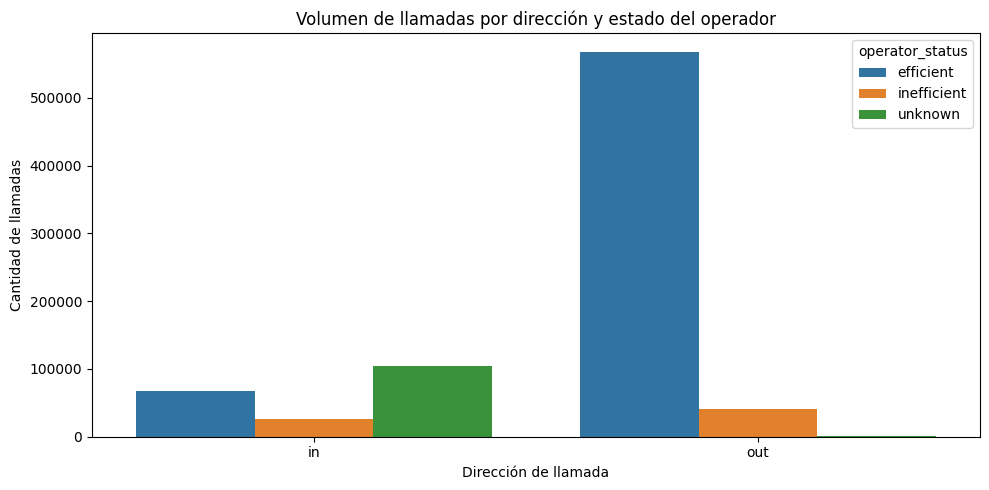

In [157]:
# Visualizamos el volumen de llamadas por dirección y estado del operador

plt.figure(figsize=(10, 5))

sns.barplot(
    data=direction_inefficiency_summary,
    x='direction',
    y='total_calls',
    hue='operator_status')

plt.title('Volumen de llamadas por dirección y estado del operador')
plt.xlabel('Dirección de llamada')
plt.ylabel('Cantidad de llamadas')
plt.tight_layout()
plt.show()

Encontramos que las llamadas salientes concentran gran parte de los registros donde el operador era eficiente; sin embargo, también concentran la mayor cantidad de casos donde el operador era potencialmente ineficiente. Tener en cuenta que la diferencia entre la cantidad de llamadas con un operador potencialmente ineficiente entre las llamadas entrantes y salientes no es muy grande, por lo que este aspecto podría no ser concluyente en la concentración de operadores potencialmente ineficientes.

In [158]:
calls_with_operator_status.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,call_week,call_month,waiting_time,avg_waiting_time_per_call,missed_calls_count,answered_calls_count,internal_type,is_inefficient,operator_status,inefficiency_criteria_count
0,166377,2019-08-04,in,False,unknown,True,2,0,4,2019-07-29/2019-08-04,2019-08,4,2.000000,2,0,external,False,unknown,0.0
1,166377,2019-08-05,out,True,880022,True,3,0,5,2019-08-05/2019-08-11,2019-08,5,1.666667,3,0,internal,False,efficient,0.0
2,166377,2019-08-05,out,True,880020,True,1,0,1,2019-08-05/2019-08-11,2019-08,1,1.000000,1,0,internal,False,efficient,0.0
3,166377,2019-08-05,out,True,880020,False,1,10,18,2019-08-05/2019-08-11,2019-08,8,8.000000,0,1,internal,False,efficient,0.0
4,166377,2019-08-05,out,False,880022,True,3,0,25,2019-08-05/2019-08-11,2019-08,25,8.333333,3,0,external,False,efficient,0.0


In [159]:
# Analizamos el comportamiento según llamadas internas, externas o sin información
internal_inefficiency_summary = (
    calls_with_operator_status
    .groupby(['internal_type', 'operator_status'])
    .agg(
        records=('user_id', 'count'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean')).reset_index())

internal_inefficiency_summary['missed_rate'] = (
    internal_inefficiency_summary['missed_calls'] /
    internal_inefficiency_summary['total_calls'])

internal_inefficiency_summary

,internal_type,operator_status,records,total_calls,missed_calls,avg_waiting_time_per_call,missed_rate
0,external,efficient,26720,626826,253635,16.842600,0.404634
1,external,inefficient,9441,61594,13640,19.937095,0.221450
2,external,unknown,7078,103409,102462,18.501005,0.990842
3,internal,efficient,3328,8233,3174,7.956308,0.385522
4,internal,inefficient,2002,5432,1869,10.782394,0.344072
5,internal,unknown,323,990,972,17.902225,0.981818
6,unknown,efficient,24,26,0,9.937500,0.000000
7,unknown,inefficient,31,34,1,21.069892,0.029412
8,unknown,unknown,55,165,165,12.285310,1.000000


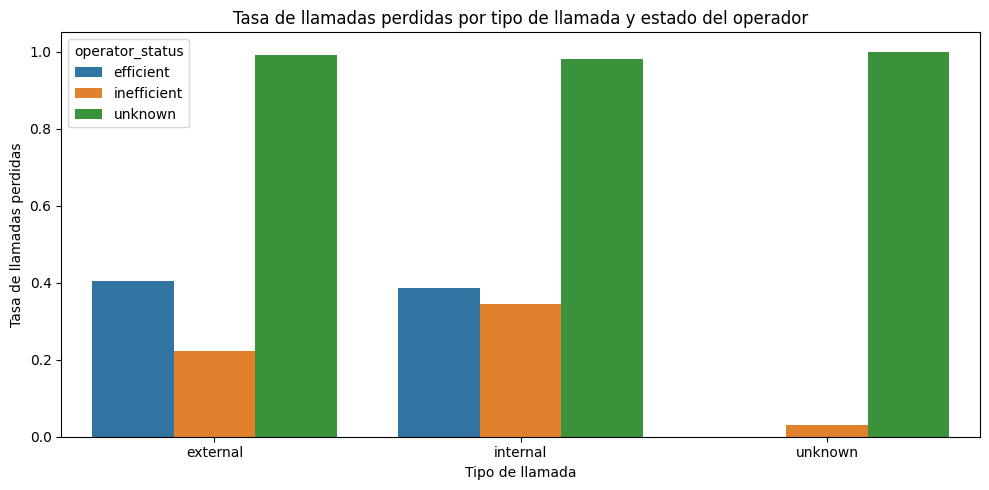

In [160]:
# Visualizamos la tasa de llamadas perdidas según tipo interno/externo y estado del operador

plt.figure(figsize=(10, 5))

sns.barplot(
    data=internal_inefficiency_summary,
    x='internal_type',
    y='missed_rate',
    hue='operator_status')

plt.title('Tasa de llamadas perdidas por tipo de llamada y estado del operador')
plt.xlabel('Tipo de llamada')
plt.ylabel('Tasa de llamadas perdidas')
plt.tight_layout()
plt.show()

Recordemos que los operadores han podido ser clasificados como potencialmente ineficientes bajo 3 criterios (alta tasa de llamadas entrantes perdidas, alto tiempo promedio de espera y bajo número de llamadas seleccionadas). Por ello es que, al realizar la separación por tipo de llamada (externa, interna o desconocida), se obtuvieron tasas ponderadas de llamadas perdidas que no reflejan adecuadamente la categorización de eficiencia de los operadores relacionados con las llamadas externas, internas y desconocidas. Por lo tanto, la dirección de la llamada no sería adecuada para verificar si se presenta una concentración de operadores potencialmente ineficientes.

### 5.3. Evaluación de patrones operativos

Se buscarán patrones generales que expliquen la ineficiencia, por ejemplo alta carga de trabajo, exceso de llamadas perdidas o tiempos de espera prolongados asociados a ciertos contextos.

In [161]:
# Evaluamos relaciones entre métricas operativas para detectar patrones asociados a ineficiencia
# Para ello usamos operator_inefficiency_metrics, que resume métricas por operador
operator_inefficiency_metrics[
    [
        'incoming_calls',
        'missed_incoming_rate',
        'avg_incoming_waiting_time_per_call',
        'outgoing_calls',
        'inefficiency_criteria_count',
        'operator_status'
    ]].head()

,incoming_calls,missed_incoming_rate,avg_incoming_waiting_time_per_call,outgoing_calls,inefficiency_criteria_count,operator_status
0,58.0,0.0,9.896552,872.0,0,efficient
1,104.0,0.0,16.153846,7209.0,0,efficient
2,7.0,0.0,7.714286,38.0,0,efficient
3,8.0,0.0,14.000000,189.0,0,efficient
4,24.0,0.0,5.958333,2208.0,0,efficient


In [162]:
# Calculamos la correlación entre métricas operativas principales
operator_correlation = operator_inefficiency_metrics[
    [
        'incoming_calls',
        'missed_incoming_rate',
        'avg_incoming_waiting_time_per_call',
        'outgoing_calls',
        'inefficiency_criteria_count'
    ]].corr()

operator_correlation

,incoming_calls,missed_incoming_rate,avg_incoming_waiting_time_per_call,outgoing_calls,inefficiency_criteria_count
incoming_calls,1.000000,-0.041205,-0.124719,0.210969,-0.226772
missed_incoming_rate,-0.041205,1.000000,-0.019408,-0.007590,0.251841
avg_incoming_waiting_time_per_call,-0.124719,-0.019408,1.000000,-0.058960,0.542662
outgoing_calls,0.210969,-0.007590,-0.058960,1.000000,-0.168425
inefficiency_criteria_count,-0.226772,0.251841,0.542662,-0.168425,1.000000


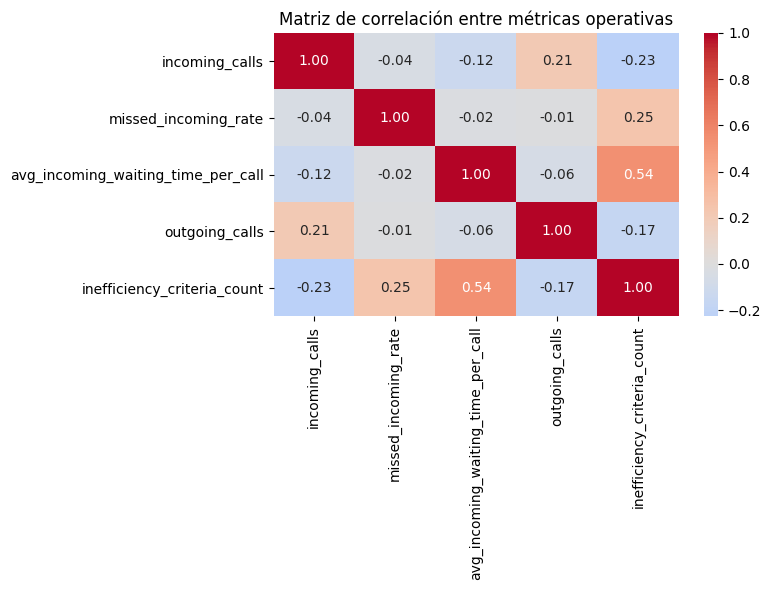

In [163]:
# Visualizamos la matriz de correlación para identificar relaciones entre variables

plt.figure(figsize=(8, 6))

sns.heatmap(
    operator_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0)

plt.title('Matriz de correlación entre métricas operativas')
plt.tight_layout()
plt.show()

En general, se observa en la matriz de correlación que la mayoría de correlaciones presentan magnitudes bajas o moderadas, lo cual indica que las métricas capturan dimensiones distintas del desempeño operativo y aportan información complementaria para el análisis.

La correlación positiva más relevante se presenta entre el tiempo promedio de espera en llamadas entrantes (avg_incoming_waiting_time_per_call) y la cantidad de criterios de ineficiencia cumplidos (inefficiency_criteria_count), con un valor aproximado de 0.54. Esto sugiere que operadores con mayores tiempos de espera tienden también a acumular más señales de ineficiencia. Desde el punto de vista operativo, este resultado es coherente con el objetivo del proyecto, ya que largos tiempos de espera pueden reflejar problemas de capacidad de atención, sobrecarga operativa o baja eficiencia en la gestión de llamadas.

También se observa una correlación positiva moderada entre la tasa de llamadas entrantes perdidas (missed_incoming_rate) y la cantidad de criterios de ineficiencia (inefficiency_criteria_count), con un valor cercano a 0.25. Aunque la relación no es fuerte, sí indica cierta tendencia a que operadores con mayores proporciones de llamadas perdidas acumulen más indicadores de bajo desempeño.

Por otro lado, las correlaciones entre el volumen de llamadas entrantes (incoming_calls) y las demás métricas son relativamente bajas. La correlación negativa de aproximadamente -0.23 entre incoming_calls y inefficiency_criteria_count sugiere que los operadores con mayor volumen de llamadas entrantes no necesariamente son los más ineficaces. Esto es relevante para el negocio, ya que evita concluir erróneamente que una mayor carga operativa implica automáticamente peor desempeño.

Asimismo, la relación entre llamadas salientes (outgoing_calls) y los indicadores de ineficiencia es débilmente negativa. Esto podría indicar que operadores con menor actividad saliente tienden ligeramente a presentar más señales de ineficiencia, aunque la magnitud observada no es suficientemente fuerte como para afirmar una dependencia clara.

En conjunto, los resultados muestran que la ineficiencia operativa parece estar más asociada a problemas de calidad de atención (como tiempos de espera elevados y llamadas perdidas) que al simple volumen de llamadas gestionadas. Esto respalda el enfoque utilizado en el proyecto para identificar operadores ineficaces mediante múltiples métricas complementarias en lugar de utilizar únicamente indicadores de carga operativa.

In [164]:
# Analizamos si los operadores ineficaces presentan mayor espera promedio y mayor tasa de llamadas perdidas frente a operadores eficientes

operator_status_comparison = (
    operator_inefficiency_metrics
    .groupby('operator_status')
    .agg(
        operators_count=('operator_id', 'count'),
        avg_incoming_calls=('incoming_calls', 'mean'),
        avg_missed_incoming_rate=('missed_incoming_rate', 'mean'),
        avg_waiting_time=('avg_incoming_waiting_time_per_call', 'mean'),
        avg_outgoing_calls=('outgoing_calls', 'mean'),
        avg_criteria_count=('inefficiency_criteria_count', 'mean')
    ).reset_index())

operator_status_comparison

,operator_status,operators_count,avg_incoming_calls,avg_missed_incoming_rate,avg_waiting_time,avg_outgoing_calls,avg_criteria_count
0,efficient,500,237.383803,0.004658,11.411299,1135.33600,0.00000
1,inefficient,592,56.138298,0.025379,21.165673,68.70777,1.27027


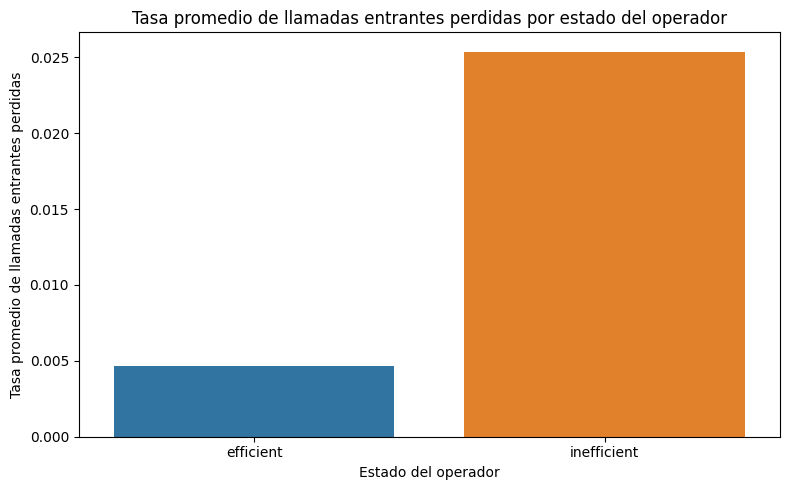

In [165]:
# Visualizamos la comparación de tasa promedio de llamadas perdidas por estado del operador
plt.figure(figsize=(8, 5))

sns.barplot(
    data=operator_status_comparison,
    x='operator_status',
    y='avg_missed_incoming_rate')

plt.title('Tasa promedio de llamadas entrantes perdidas por estado del operador')
plt.xlabel('Estado del operador')
plt.ylabel('Tasa promedio de llamadas entrantes perdidas')
plt.tight_layout()
plt.show()

Encontramos que, de forma ponderada, la tasa promedio de llamadas entrantes perdidas es mucho mayor en las llamadas relacionadas con operadores catalogados como potencialmente ineficientes; lo cual es compatible con la clasificación realizada sobre los operadores.

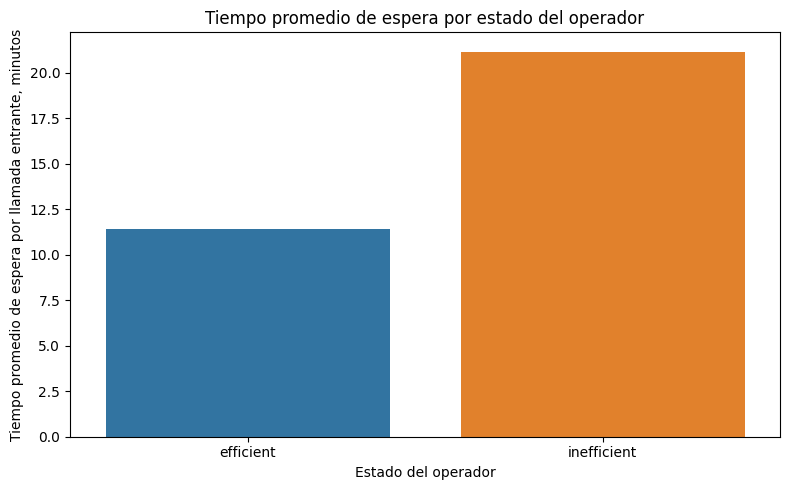

In [166]:
# Visualizamos la comparación del tiempo promedio de espera por estado del operador
plt.figure(figsize=(8, 5))

sns.barplot(
    data=operator_status_comparison,
    x='operator_status',
    y='avg_waiting_time')

plt.title('Tiempo promedio de espera por estado del operador')
plt.xlabel('Estado del operador')
plt.ylabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.tight_layout()
plt.show()

Encontramos que, de forma ponderada, el tiempo promedio de espera por llamada entrante es mucho mayor en las llamadas relacionadas con operadores catalogados como potencialmente ineficientes; lo cual es compatible con la clasificación realizada sobre los operadores.

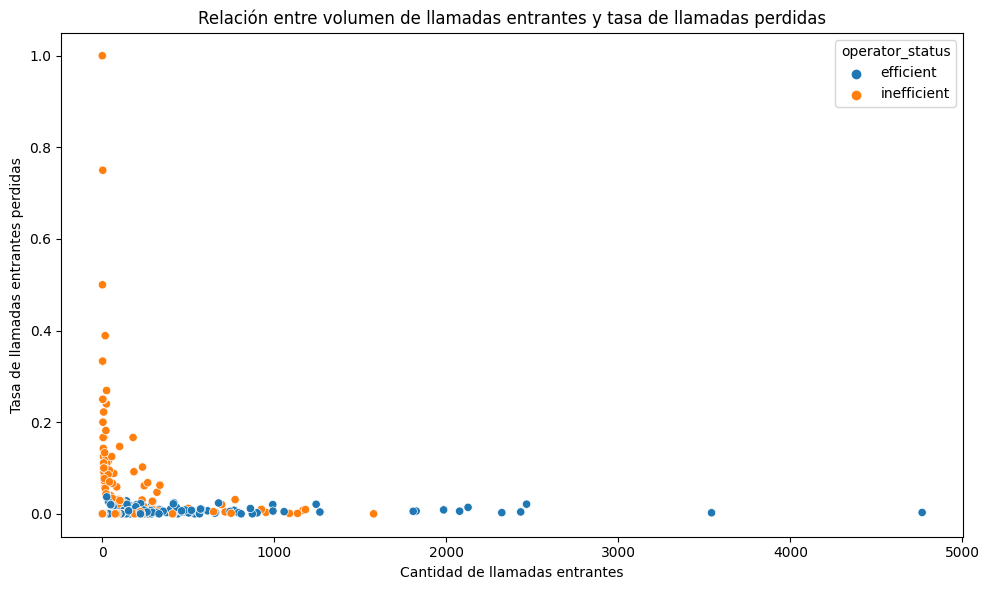

In [167]:
# Visualizamos relación entre volumen entrante y tasa de llamadas perdidas

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=operator_inefficiency_metrics,
    x='incoming_calls',
    y='missed_incoming_rate',
    hue='operator_status')

plt.title('Relación entre volumen de llamadas entrantes y tasa de llamadas perdidas')
plt.xlabel('Cantidad de llamadas entrantes')
plt.ylabel('Tasa de llamadas entrantes perdidas')
plt.tight_layout()
plt.show()

Sobre el gráfico de dispersión anterior, encontramos que:
- En el caso de los operadores eficientes, a pesar de que llegan a poseer altas cantidades de llamadas entrantes, siguen manteniendo una baja tasa de llamadas entrantes perdidas.
- En el caso de los operadores potencialmente ineficientes, a pesar de que gran parte de ellos tiene un volumen bajo de llamadas entrantes, se muestra que en los registros dicha poca cantidad de llamadas entrantes presenta una tasa mucho mayor de llamadas entrantes perdidas, lo cual sugiere que estos trabajadores generan menos esfuerzo en general; tanto para participar en llamadas entrantes como para atender exitosamente dichas pocas llamadas entrantes.

Por ello, un alto volumen de llamadas entrantes no sería una causa del incremento de la tasa de llamadas entrantes perdidas según este hallazgo.

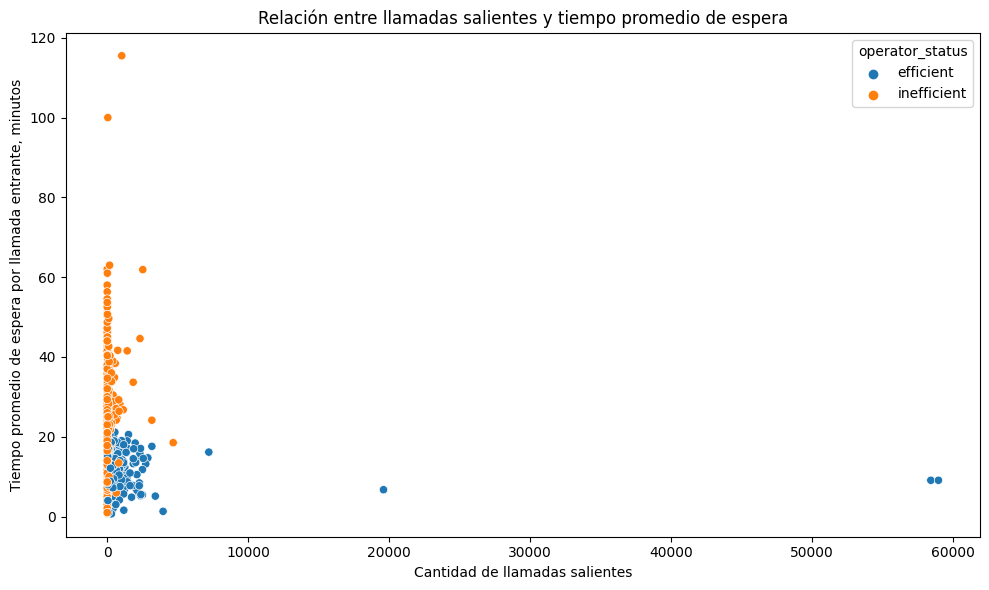

In [168]:
# Visualizamos relación entre volumen saliente y tiempo promedio de espera

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=operator_inefficiency_metrics,
    x='outgoing_calls',
    y='avg_incoming_waiting_time_per_call',
    hue='operator_status')

plt.title('Relación entre llamadas salientes y tiempo promedio de espera')
plt.xlabel('Cantidad de llamadas salientes')
plt.ylabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.tight_layout()
plt.show()

Sobre el gráfico de dispersión anterior, encontramos que:
- En el caso de los operadores eficientes, a pesar de que llegan a poseer altas cantidades de llamadas salientes, siguen manteniendo un nivel medio o bajo del tiempo promedio de espera por llamada entrante.
- En el caso de los operadores potencialmente ineficientes, a pesar de que gran parte de ellos tiene un volumen bajo de llamadas salientes, se muestra que en los registros dicha poca cantidad de llamadas salientes se asocia con un tiempo promedio de espera por llamada entrante mayor, lo cual sugiere que estos trabajadores generan menos esfuerzo en general, tanto para generar llamadas salientes como para atender prontamente las llamadas entrantes que reciben.

Por ello, la cantidad de llamadas salientes no sería una causa del incremento del tiempo promedio de espera por llamada entrante según este hallazgo.

### 5.4. Análisis temporal mediante cohortes

Se plantea un análisis complementario de cohortes o evolución temporal para explorar si la ineficiencia cambia según el momento de incorporación de los clientes o según periodos de operación. Este análisis se usaría solo si la estructura temporal de los datos aporta valor directo al objetivo del proyecto.

In [169]:
# Para analizar la evolución temporal, combinamos llamadas con información de clientes
# Esto permite relacionar el desempeño operativo con la fecha de registro del cliente

calls_temporal = calls_with_operator_status.merge(
    clients[['user_id', 'date_start', 'tariff_plan']],
    on='user_id',
    how='left')

calls_temporal.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,call_week,...,waiting_time,avg_waiting_time_per_call,missed_calls_count,answered_calls_count,internal_type,is_inefficient,operator_status,inefficiency_criteria_count,date_start,tariff_plan
0,166377,2019-08-04,in,False,unknown,True,2,0,4,2019-07-29/2019-08-04,...,4,2.000000,2,0,external,False,unknown,0.0,2019-08-01,B
1,166377,2019-08-05,out,True,880022,True,3,0,5,2019-08-05/2019-08-11,...,5,1.666667,3,0,internal,False,efficient,0.0,2019-08-01,B
2,166377,2019-08-05,out,True,880020,True,1,0,1,2019-08-05/2019-08-11,...,1,1.000000,1,0,internal,False,efficient,0.0,2019-08-01,B
3,166377,2019-08-05,out,True,880020,False,1,10,18,2019-08-05/2019-08-11,...,8,8.000000,0,1,internal,False,efficient,0.0,2019-08-01,B
4,166377,2019-08-05,out,False,880022,True,3,0,25,2019-08-05/2019-08-11,...,25,8.333333,3,0,external,False,efficient,0.0,2019-08-01,B


In [170]:
# Creamos cohortes mensuales según la fecha de registro del cliente
calls_temporal['client_cohort_month'] = (
    calls_temporal['date_start']
    .dt.to_period('M')
    .astype(str))

# Verificamos que call_month exista; si no existe, lo creamos desde date
if 'call_month' not in calls_temporal.columns:
    calls_temporal['call_month'] = (
        calls_temporal['date'].dt.to_period('M').astype(str))

# Agrupamos por cohorte de cliente y mes de llamada para evaluar evolución de volumen, llamadas perdidas y espera
cohort_month_summary = (
    calls_temporal
    .groupby(['client_cohort_month', 'call_month'])
    .agg(
        total_clients=('user_id', 'nunique'),
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean'),
        inefficient_operator_records=('is_inefficient', 'sum'),
        total_records=('user_id', 'count')).reset_index())

cohort_month_summary['missed_rate'] = (
    cohort_month_summary['missed_calls'] / cohort_month_summary['total_calls'])

cohort_month_summary['inefficient_operator_record_rate'] = (
    cohort_month_summary['inefficient_operator_records'] / cohort_month_summary['total_records'])

cohort_month_summary.head()

,client_cohort_month,call_month,total_clients,total_calls,missed_calls,avg_waiting_time_per_call,inefficient_operator_records,total_records,missed_rate,inefficient_operator_record_rate
0,2019-08,2019-08,85,37391,15825,15.438610,294,1860,0.423230,0.158065
1,2019-08,2019-09,94,104220,42976,17.017049,1083,5731,0.412358,0.188972
2,2019-08,2019-10,97,117319,46209,17.334527,1849,7259,0.393875,0.254718
3,2019-08,2019-11,83,55868,19137,17.098514,1874,6557,0.342540,0.285801
4,2019-09,2019-09,79,42370,21397,15.409123,566,2670,0.505004,0.211985


In [171]:
# Construimos una tabla dinámica para visualizar la tasa de llamadas perdidas por cohorte y mes
cohort_missed_rate_pivot = cohort_month_summary.pivot_table(
    index='client_cohort_month',
    columns='call_month',
    values='missed_rate',
    aggfunc='mean')

cohort_missed_rate_pivot

call_month,2019-08,2019-09,2019-10,2019-11
client_cohort_month,,,,
2019-08,0.42323,0.412358,0.393875,0.342540
2019-09,NaN,0.505004,0.552312,0.363587
2019-10,NaN,NaN,0.507581,0.521239


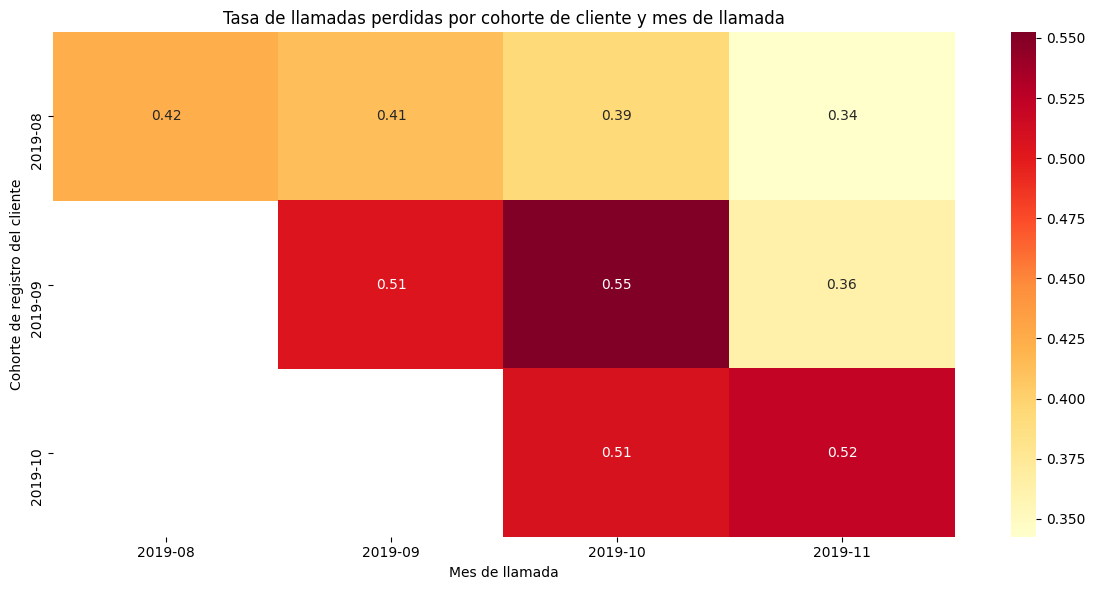

In [172]:
# Visualizamos el mapa de calor de tasa de llamadas perdidas por cohorte y mes

plt.figure(figsize=(12, 6))

sns.heatmap(
    cohort_missed_rate_pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd')

plt.title('Tasa de llamadas perdidas por cohorte de cliente y mes de llamada')
plt.xlabel('Mes de llamada')
plt.ylabel('Cohorte de registro del cliente')
plt.tight_layout()
plt.show()

Encontramos que la cohorte 2019-08 posee una tendencia a disminuir la tasa de llamadas perdidas tras cada mes transcurrido de forma consistente y continua. En el caso de la cohorte 2019-09, muestra un pequeño incremento para luego reducir la tasa de llamadas perdidas; y en el caso de la cohorte 2019-10 muestra solamente un incremento pequeño. El análisis de estas 2 últimas cohortes puede estar limitado ya que no se cuenta con un registro prolongado de meses para poder evaluar mejor la tendencia de dichas cohortes; por lo que, basándonos en el comportamiento de la primera cohorte, en general es posible que la tasa de llamadas perdidas pueda disminuir en el tiempo; mostrando una mejoría de los usuarios en el uso del sistema telefónico.

In [173]:
# Construimos una tabla dinámica para evaluar la proporción de registros con operadores ineficaces
cohort_inefficiency_pivot = cohort_month_summary.pivot_table(
    index='client_cohort_month',
    columns='call_month',
    values='inefficient_operator_record_rate',
    aggfunc='mean')

cohort_inefficiency_pivot

call_month,2019-08,2019-09,2019-10,2019-11
client_cohort_month,,,,
2019-08,0.158065,0.188972,0.254718,0.285801
2019-09,NaN,0.211985,0.234703,0.277645
2019-10,NaN,NaN,0.194107,0.218057


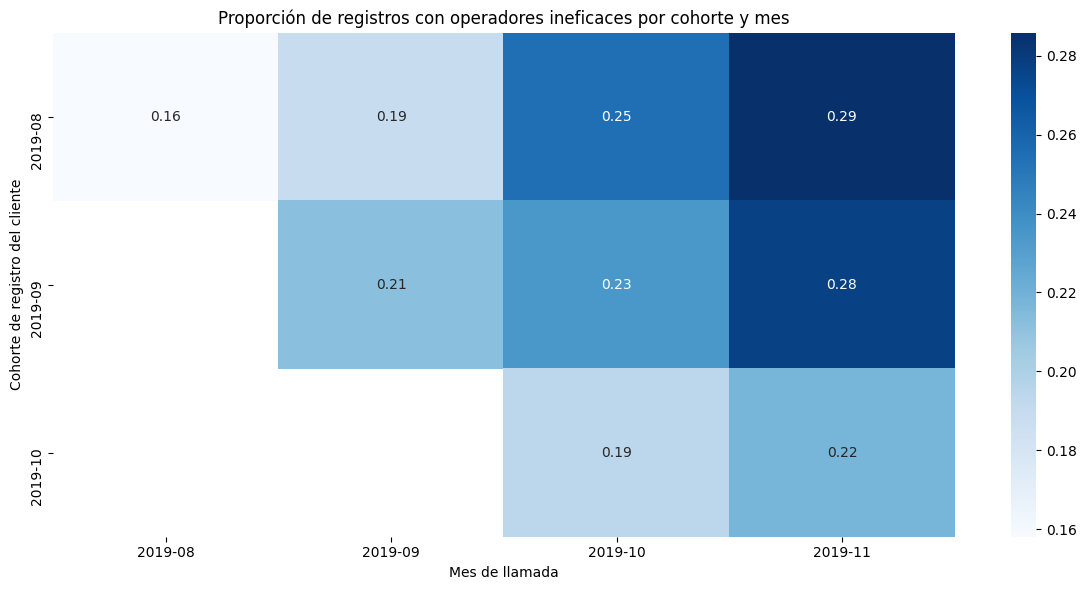

In [174]:
# Visualizamos el mapa de calor de proporción de registros con operadores ineficaces
plt.figure(figsize=(12, 6))

sns.heatmap(
    cohort_inefficiency_pivot,
    annot=True,
    fmt='.2f',
    cmap='Blues')

plt.title('Proporción de registros con operadores ineficaces por cohorte y mes')
plt.xlabel('Mes de llamada')
plt.ylabel('Cohorte de registro del cliente')
plt.tight_layout()
plt.show()

En términos generales, se observa una tendencia creciente en la proporción de registros vinculados a operadores ineficaces conforme avanzan los meses de operación. Por ejemplo, para la cohorte de clientes registrados en agosto de 2019, la proporción de registros asociados a operadores ineficaces aumenta progresivamente desde aproximadamente 16% en agosto hasta cerca de 29% en noviembre. Un comportamiento similar se aprecia en la cohorte de septiembre de 2019, donde la proporción crece desde aproximadamente el 21% hasta el 28%.

Este patrón podría indicar que, conforme aumenta la actividad operativa o el tiempo de permanencia de los clientes en el sistema, se incrementa también la exposición a operadores con señales de bajo desempeño. Desde el punto de vista del negocio, este hallazgo es relevante porque sugiere que la ineficiencia operativa no parece concentrarse únicamente en un periodo específico, sino que muestra cierta persistencia temporal.

Asimismo, se observa que las cohortes más recientes, como octubre de 2019, presentan inicialmente menores proporciones de registros asociados a operadores ineficaces en comparación con cohortes anteriores. Sin embargo, incluso en estas cohortes se aprecia un incremento progresivo entre meses consecutivos. Esto podría sugerir que algunos problemas operativos se intensifican conforme aumenta el volumen de interacción entre clientes y operadores.

Otro aspecto importante es que las diferencias entre cohortes no son extremadamente amplias. La mayoría de los valores se concentra aproximadamente entre el 16% y el 29%, lo que sugiere que la presencia de operadores potencialmente ineficaces afecta de forma relativamente transversal a distintos grupos de clientes y no exclusivamente a una cohorte particular.

En conjunto, los resultados refuerzan la necesidad de implementar mecanismos de monitoreo continuo del desempeño operativo. La evidencia temporal encontrada sugiere que la identificación temprana de operadores con altas tasas de llamadas perdidas o tiempos elevados de espera podría contribuir a reducir la propagación de ineficiencias operativas a lo largo del tiempo y mejorar la calidad general del servicio ofrecido a los clientes.

In [175]:
# Analizamos la evolución mensual general de la ineficiencia operativa
monthly_inefficiency_summary = (
    calls_temporal
    .groupby('call_month')
    .agg(
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        avg_waiting_time_per_call=('avg_waiting_time_per_call', 'mean'),
        inefficient_operator_records=('is_inefficient', 'sum'),
        total_records=('user_id', 'count')).reset_index())

monthly_inefficiency_summary['missed_rate'] = (
    monthly_inefficiency_summary['missed_calls'] /
    monthly_inefficiency_summary['total_calls'])

monthly_inefficiency_summary['inefficient_operator_record_rate'] = (
    monthly_inefficiency_summary['inefficient_operator_records'] /
    monthly_inefficiency_summary['total_records'])

monthly_inefficiency_summary

,call_month,total_calls,missed_calls,avg_waiting_time_per_call,inefficient_operator_records,total_records,missed_rate,inefficient_operator_record_rate
0,2019-08,37391,15825,15.438610,294,1860,0.423230,0.158065
1,2019-09,146590,64373,16.506019,1649,8401,0.439136,0.196286
2,2019-10,316299,153205,17.009814,4040,17193,0.484368,0.234979
3,2019-11,306429,142515,16.929303,5491,21548,0.465083,0.254826


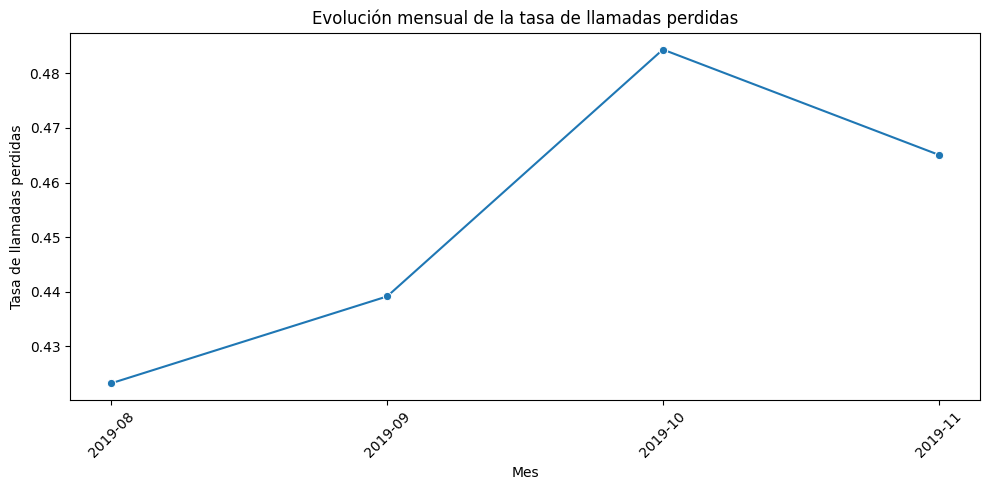

In [176]:
# Visualizamos la evolución mensual de la tasa de llamadas perdidas
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_inefficiency_summary,
    x='call_month',
    y='missed_rate',
    marker='o')

plt.title('Evolución mensual de la tasa de llamadas perdidas')
plt.xlabel('Mes')
plt.ylabel('Tasa de llamadas perdidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En términos generales, se observa una tendencia creciente de la tasa de llamadas perdidas entre agosto y octubre de 2019. La proporción aumenta aproximadamente desde 42% en agosto hasta cerca de 48% en octubre, lo que indica un deterioro progresivo en la capacidad de atención de llamadas durante ese periodo. Posteriormente, en noviembre se aprecia una ligera reducción, aunque la tasa se mantiene todavía en niveles elevados, alrededor de 46%.

Desde el punto de vista operativo, estos resultados sugieren que el sistema telefónico experimentó un incremento sostenido en la cantidad de llamadas que no lograron ser atendidas correctamente. Esto podría estar asociado a diversos factores, tales como:
- Aumento del volumen de llamadas.
- Sobrecarga operativa de ciertos operadores.
- Distribución ineficiente de llamadas.
- Tiempos elevados de espera.
- Limitaciones en capacidad operativa.

Asimismo, el hecho de que las tasas de llamadas perdidas se mantengan consistentemente por encima del 40% durante todo el periodo representa un indicador importante de posible ineficiencia operacional a nivel general del sistema. Esto refuerza la relevancia del análisis realizado para detectar operadores con bajo desempeño y priorizar acciones correctivas.

La ligera disminución observada en noviembre podría indicar una mejora parcial en la gestión operativa o una reducción temporal de carga. Sin embargo, la magnitud de la reducción no parece suficiente para afirmar una recuperación sostenida del desempeño del sistema.

En conjunto, el análisis temporal evidencia que la problemática de llamadas perdidas no corresponde a un evento aislado, sino a un patrón relativamente persistente en el tiempo. Esto sugiere que la empresa podría beneficiarse de mecanismos de monitoreo continuo del desempeño operativo, redistribución de carga entre operadores y estrategias de optimización de tiempos de respuesta para reducir la pérdida de llamadas y mejorar la calidad del servicio ofrecido a los clientes.

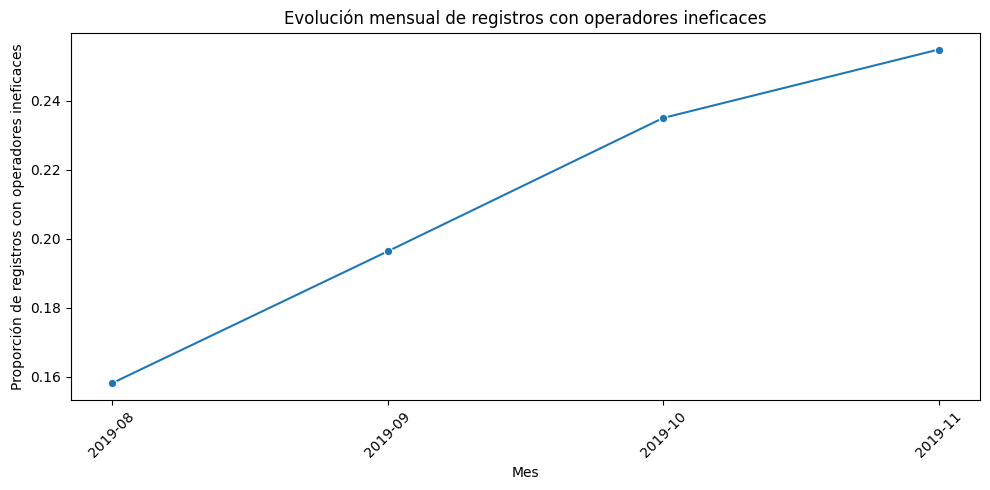

In [177]:
# Visualizamos la evolución mensual de registros asociados a operadores ineficaces
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_inefficiency_summary,
    x='call_month',
    y='inefficient_operator_record_rate',
    marker='o')

plt.title('Evolución mensual de registros con operadores ineficaces')
plt.xlabel('Mes')
plt.ylabel('Proporción de registros con operadores ineficaces')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa una tendencia claramente creciente entre agosto y noviembre de 2019. La proporción de registros vinculados a operadores ineficaces aumenta progresivamente desde aproximadamente el 16% en agosto hasta cerca del 25% en noviembre. Esto indica que, conforme avanzan los meses, una mayor parte de la actividad operativa del sistema se encuentra asociada a operadores que presentan al menos uno de los criterios de ineficiencia definidos previamente.

Desde la perspectiva del negocio, este comportamiento es relevante porque sugiere un deterioro gradual en el desempeño operativo general del sistema telefónico. El crecimiento sostenido de registros relacionados con operadores ineficaces podría estar asociado a factores como:
- Incremento del volumen de llamadas.
- Sobrecarga de ciertos operadores.
- Distribución ineficiente de llamadas.
- Insuficiente capacidad de atención.
- Falta de monitoreo temprano del desempeño operativo.

Además, la tendencia observada es consistente con los resultados obtenidos previamente en el análisis temporal de llamadas perdidas, donde también se identificó un incremento progresivo de la tasa de llamadas no atendidas. Esto fortalece la hipótesis de que las ineficiencias detectadas no corresponden a casos aislados, sino a patrones operativos persistentes que tienden a intensificarse con el tiempo.

Encontramos también que el crecimiento de la proporción de registros con operadores ineficaces se produce de manera relativamente continua y sin reducciones significativas entre meses consecutivos. Esto podría indicar que los mecanismos actuales de control operativo no están corrigiendo de forma efectiva los problemas detectados en determinados operadores.

En conjunto, los resultados evidencian la necesidad de implementar estrategias de monitoreo continuo y detección temprana de operadores con bajo desempeño. La identificación oportuna de operadores con altas tasas de llamadas perdidas, tiempos elevados de espera o baja actividad saliente podría contribuir a reducir progresivamente la proporción de interacciones afectadas por ineficiencias operativas y mejorar la calidad del servicio ofrecido a los clientes.

## Paso 6. Validación mediante pruebas de hipótesis

### 6.1. Comparación de métricas entre grupos

Se compararán métricas relevantes entre grupos de interés, por ejemplo, operadores clasificados como eficientes e ineficientes, o distintos tipos de llamadas. El objetivo será verificar si las diferencias observadas en el análisis exploratorio son consistentes.

In [178]:
# Revisamos las columnas disponibles en el dataframe de métricas de operadores
operator_inefficiency_metrics.columns

Index(['operator_id', 'incoming_calls', 'missed_incoming_calls',
       'missed_incoming_rate', 'total_incoming_waiting_time',
       'avg_incoming_waiting_time_per_call', 'outgoing_calls',
       'high_missed_rate', 'high_waiting_time', 'low_outgoing_calls',
       'inefficiency_criteria_count', 'is_inefficient', 'operator_status',
       'inefficiency_reasons'],
      dtype='object')

In [179]:
# Seleccionamos las métricas principales para comparar operadores eficientes e ineficientes
metrics_to_compare = [
    'missed_incoming_rate',
    'avg_incoming_waiting_time_per_call',
    'outgoing_calls',
    'incoming_calls']

# Calculamos estadísticas descriptivas por grupo de operadores
operator_group_comparison = (
    operator_inefficiency_metrics
    .groupby('operator_status')[metrics_to_compare]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max']))

operator_group_comparison

missed_incoming_rate                                  \
                               count      mean median       std  min   
operator_status                                                        
efficient                        284  0.004658    0.0  0.007921  0.0   
inefficient                      470  0.025379    0.0  0.081556  0.0   

                          avg_incoming_waiting_time_per_call             \
                      max                              count       mean   
operator_status                                                           
efficient        0.037037                                284  11.411299   
inefficient      1.000000                                470  21.165673   

                                       ... outgoing_calls                     \
                    median        std  ...         median          std   min   
operator_status                        ...                                     
efficient        11.000000   4.706680  ...          345.0  4080.088912  20.0   
inefficient      18.220513  13.732849  ...            2.0   312.303246   0.0   

                         incoming_calls                                      \
                     max          count        mean median         std  min   
operator_status                                                               
efficient        58977.0            284  237.383803   60.0  521.131845  1.0   
inefficient       4681.0            470   56.138298    8.0  166.500965  1.0   

                         
                    max  
operator_status          
efficient        4766.0  
inefficient      1578.0  

[2 rows x 24 columns]

In [180]:
# Creamos dataframes separados para operadores eficientes e ineficientes
efficient_operators = operator_inefficiency_metrics[
    operator_inefficiency_metrics['operator_status'] == 'efficient'
].copy()

inefficient_operators = operator_inefficiency_metrics[
    operator_inefficiency_metrics['operator_status'] == 'inefficient'
].copy()

# Verificamos la cantidad de operadores en cada grupo
print('Cantidad de operadores eficientes:', efficient_operators.shape[0])
print('Cantidad de operadores ineficientes:', inefficient_operators.shape[0])

Cantidad de operadores eficientes: 500
Cantidad de operadores ineficientes: 592


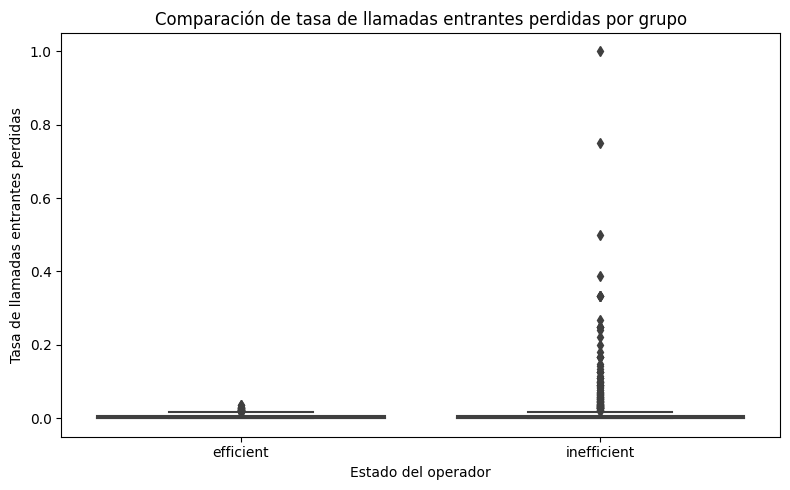

In [181]:
# Comparamos visualmente la tasa de llamadas entrantes perdidas entre operadores eficientes e ineficientes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=operator_inefficiency_metrics,
    x='operator_status',
    y='missed_incoming_rate')

plt.title('Comparación de tasa de llamadas entrantes perdidas por grupo')
plt.xlabel('Estado del operador')
plt.ylabel('Tasa de llamadas entrantes perdidas')
plt.tight_layout()
plt.show()

En primer lugar, se observa que la mayoría de operadores eficientes presentan tasas de llamadas perdidas muy cercanas a cero, con una baja dispersión entre registros. Esto sugiere un comportamiento relativamente estable y consistente en la capacidad de atención de llamadas entrantes dentro de este grupo.

Por otro lado, los operadores clasificados como ineficientes muestran una dispersión considerablemente mayor. Aunque parte de estos operadores también presentan valores bajos, existe un número importante de casos atípicos con tasas elevadas de llamadas perdidas, alcanzando incluso valores cercanos al 100%. Esto indica que algunos operadores presentan problemas severos de atención de llamadas entrantes, perdiendo una proporción significativa de las interacciones asignadas.

La presencia de numerosos valores atípicos en el grupo de operadores ineficientes sugiere además que la ineficiencia operacional no se distribuye de manera homogénea entre todos los operadores clasificados como problemáticos. En cambio, parece existir un subconjunto reducido de operadores con desempeños particularmente críticos que podrían estar impactando de manera desproporcionada la calidad del servicio.

Desde la perspectiva del negocio, este hallazgo es relevante porque permite identificar que el problema operativo no necesariamente radica en toda la fuerza operativa, sino posiblemente en determinados operadores específicos con patrones persistentes de llamadas perdidas. Esto abre la posibilidad de implementar acciones enfocadas como:
- Monitoreo individual de desempeño.
- Capacitación específica.
- Revisión de horarios o asignación de llamadas.
- Evaluación técnica de problemas de conectividad o disponibilidad.

Asimismo, el hecho de que los operadores eficientes mantengan tasas consistentemente bajas de llamadas perdidas refuerza la validez de los criterios utilizados para la clasificación de ineficiencia, ya que el comportamiento observado entre ambos grupos presenta diferencias claras desde el punto de vista operativo.

En conjunto, el boxplot evidencia que la tasa de llamadas entrantes perdidas constituye una métrica clasificadora importante para identificar operadores con posibles problemas de desempeño y respalda el objetivo principal del proyecto de detectar operadores ineficaces mediante indicadores cuantitativos de calidad operativa.

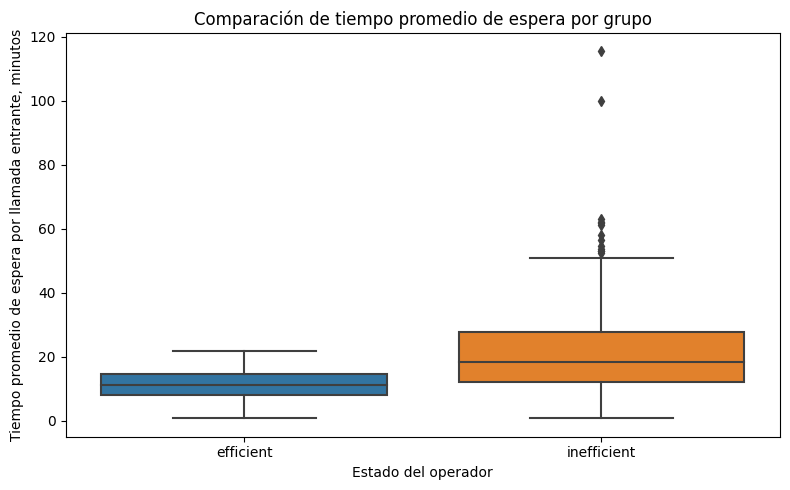

In [182]:
# Comparamos visualmente el tiempo promedio de espera en llamadas entrantes entre grupos
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=operator_inefficiency_metrics,
    x='operator_status',
    y='avg_incoming_waiting_time_per_call')

plt.title('Comparación de tiempo promedio de espera por grupo')
plt.xlabel('Estado del operador')
plt.ylabel('Tiempo promedio de espera por llamada entrante, minutos')
plt.tight_layout()
plt.show()

Se observa que los operadores eficientes presentan tiempos promedio de espera relativamente bajos y concentrados en un rango reducido. La mediana se mantiene cercana a los 10–12 minutos y la dispersión es moderada, lo que sugiere un desempeño relativamente estable y homogéneo dentro de este grupo.

En contraste, los operadores clasificados como ineficientes muestran una mediana claramente superior y una dispersión considerablemente mayor. Esto indica que, en promedio, las llamadas atendidas por este grupo experimentan mayores tiempos de espera antes de ser gestionadas. Además, la amplitud del rango intercuartílico es más elevada, reflejando una mayor variabilidad en el desempeño operativo de estos operadores.

Un hallazgo relevante es la presencia de múltiples valores atípicos extremos en el grupo de operadores ineficientes, alcanzando tiempos promedio superiores a los 100 minutos. Estos casos representan operadores con problemas particularmente severos de atención o disponibilidad, los cuales podrían estar generando un impacto significativo en la calidad del servicio y en la satisfacción de los clientes.

Desde la perspectiva del negocio, estos resultados sugieren que los operadores identificados como ineficaces no solo pierden más llamadas, sino que también presentan dificultades para gestionar oportunamente las interacciones entrantes. Esto podría estar asociado a factores como:
- sobrecarga operativa;
- mala distribución de llamadas;
- tiempos excesivos entre llamadas;
- baja disponibilidad del operador;
- limitaciones técnicas o de conectividad;
- insuficiente capacidad de respuesta.

Asimismo, la clara separación observada entre ambos grupos refuerza la validez del criterio utilizado para clasificar operadores ineficaces. El tiempo promedio de espera demuestra ser una métrica útil para clasificar distintos niveles de desempeño operativo dentro del sistema telefónico.

En conjunto, el análisis evidencia que los tiempos elevados de espera constituyen uno de los principales patrones asociados a la ineficiencia operativa. Esto respalda la necesidad de implementar mecanismos de monitoreo continuo y alertas tempranas que permitan detectar operadores con tiempos anormalmente altos y aplicar acciones correctivas antes de que afecten de manera significativa la calidad del servicio.

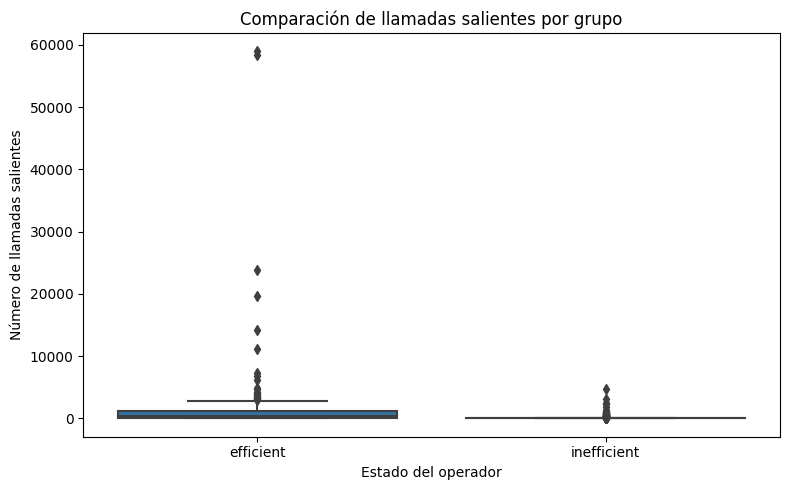

In [183]:
# Comparamos visualmente el número de llamadas salientes entre operadores eficientes e ineficientes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=operator_inefficiency_metrics,
    x='operator_status',
    y='outgoing_calls')

plt.title('Comparación de llamadas salientes por grupo')
plt.xlabel('Estado del operador')
plt.ylabel('Número de llamadas salientes')
plt.tight_layout()
plt.show()

Se observa que los operadores eficientes presentan, en términos generales, una mayor cantidad de llamadas salientes respecto al grupo de operadores ineficientes. La distribución del grupo eficiente muestra una mediana más elevada y una dispersión considerablemente mayor, lo que indica que dentro de este grupo existen operadores con altos niveles de actividad saliente.

Por el contrario, los operadores clasificados como ineficientes concentran la mayor parte de sus registros en valores bajos de llamadas salientes. Esto sugiere que muchos de estos operadores presentan una participación reducida en actividades de comunicación saliente, lo cual es consistente con uno de los criterios utilizados para identificar bajo desempeño operativo.

Asimismo, el gráfico evidencia una fuerte asimetría positiva en ambos grupos, especialmente entre operadores eficientes. Se observan múltiples valores atípicos extremadamente altos, incluyendo algunos operadores con volúmenes de llamadas salientes significativamente superiores al resto. Esto indica que existe una gran heterogeneidad operativa entre operadores, donde ciertos individuos concentran una proporción importante de la actividad saliente del sistema.

Desde la perspectiva del negocio, este comportamiento podría reflejar diferencias funcionales entre operadores, tales como:
- Operadores especializados en campañas salientes.
- Equipos comerciales o de seguimiento.
- Distintos niveles de carga operativa.
- Diferencias en horarios o turnos de atención.

Por esta razón, el número de llamadas salientes debe interpretarse con cautela y siempre en conjunto con las demás métricas de desempeño, como la tasa de llamadas perdidas y el tiempo promedio de espera. Un bajo volumen saliente no necesariamente implica ineficiencia en todos los casos, ya que algunos operadores podrían desempeñar principalmente funciones de atención entrante.

Aun así, el gráfico muestra una tendencia consistente donde los operadores clasificados como ineficientes presentan menor actividad saliente en comparación con operadores eficientes. Esto respalda parcialmente la utilidad de esta métrica como criterio complementario dentro del modelo de identificación de operadores ineficaces.

En conjunto, los resultados sugieren que las diferencias más importantes entre operadores eficientes e ineficientes parecen estar asociadas principalmente a métricas de calidad operativa (como llamadas perdidas y tiempos de espera), mientras que el volumen de llamadas salientes funciona más como un indicador contextual complementario del desempeño operativo.

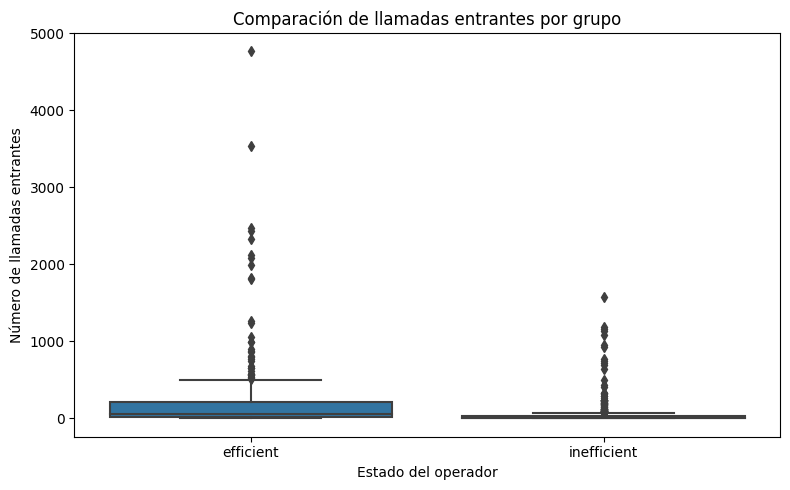

In [184]:
# Comparamos visualmente el volumen de llamadas entrantes entre operadores eficientes e ineficientes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=operator_inefficiency_metrics,
    x='operator_status',
    y='incoming_calls')

plt.title('Comparación de llamadas entrantes por grupo')
plt.xlabel('Estado del operador')
plt.ylabel('Número de llamadas entrantes')
plt.tight_layout()
plt.show()

Se observa que los operadores eficientes presentan, en general, un mayor volumen de llamadas entrantes respecto a los operadores ineficientes. La mediana y el rango intercuartílico del grupo eficiente son considerablemente superiores, lo que indica que estos operadores suelen gestionar una mayor cantidad de interacciones entrantes de forma relativamente consistente.

Por el contrario, los operadores clasificados como ineficientes concentran la mayor parte de sus registros en niveles bajos de llamadas entrantes. Esto sugiere que muchos operadores con señales de bajo desempeño no necesariamente están asociados a una alta carga operativa, sino que incluso gestionan menores volúmenes de llamadas en comparación con los operadores eficientes.

Asimismo, ambos grupos presentan valores atípicos elevados, aunque estos son mucho más extremos en el grupo eficiente. Existen operadores eficientes con volúmenes de llamadas entrantes excepcionalmente altos, alcanzando varios miles de llamadas, lo que evidencia una fuerte heterogeneidad en la distribución de carga operativa dentro del sistema telefónico.

Desde la perspectiva del negocio, este resultado es especialmente relevante porque sugiere que una mayor carga de llamadas no implica automáticamente un peor desempeño operativo. De hecho, muchos operadores eficientes logran gestionar altos volúmenes de llamadas manteniendo bajas tasas de llamadas perdidas y menores tiempos de espera. Esto coincide con los resultados observados previamente en la matriz de correlación, donde el volumen de llamadas entrantes no mostró una relación positiva fuerte con los criterios de ineficiencia.

En consecuencia, los resultados indican que la ineficiencia operativa parece estar más asociada a problemas de calidad en la gestión de llamadas —como tiempos elevados de espera o llamadas perdidas— que al simple volumen de actividad atendida. Esto refuerza la importancia de evaluar múltiples métricas complementarias para identificar operadores ineficaces y evita concluir erróneamente que los operadores con mayor carga operativa son necesariamente los de peor desempeño.

Además, la presencia de operadores eficientes capaces de gestionar grandes volúmenes de llamadas podría servir como referencia para identificar buenas prácticas operativas o estrategias de asignación de llamadas que posteriormente podrían replicarse en operadores con bajo desempeño.

En conjunto, el gráfico respalda la idea de que el desempeño operativo depende más de la capacidad de gestión eficiente de llamadas que de la cantidad total de interacciones atendidas, lo cual es consistente con el objetivo principal del proyecto de detectar operadores ineficaces mediante indicadores de calidad operativa.

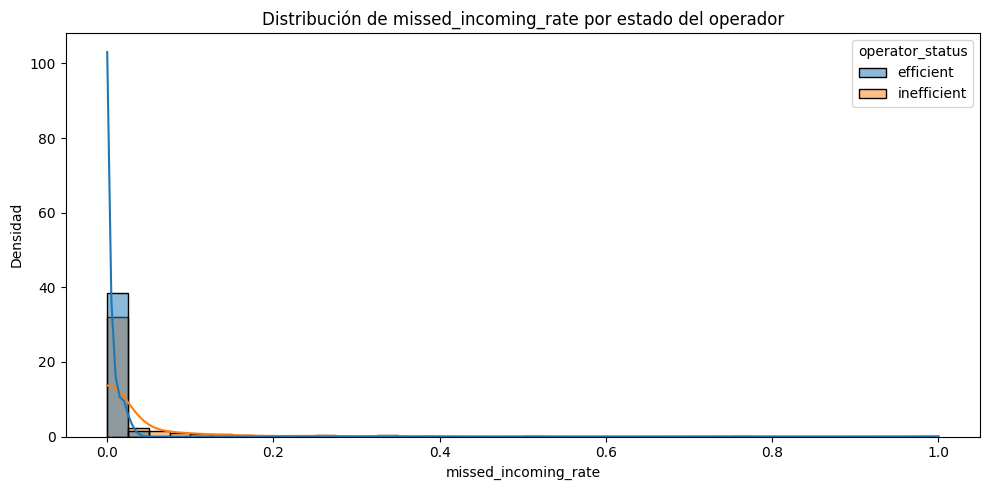

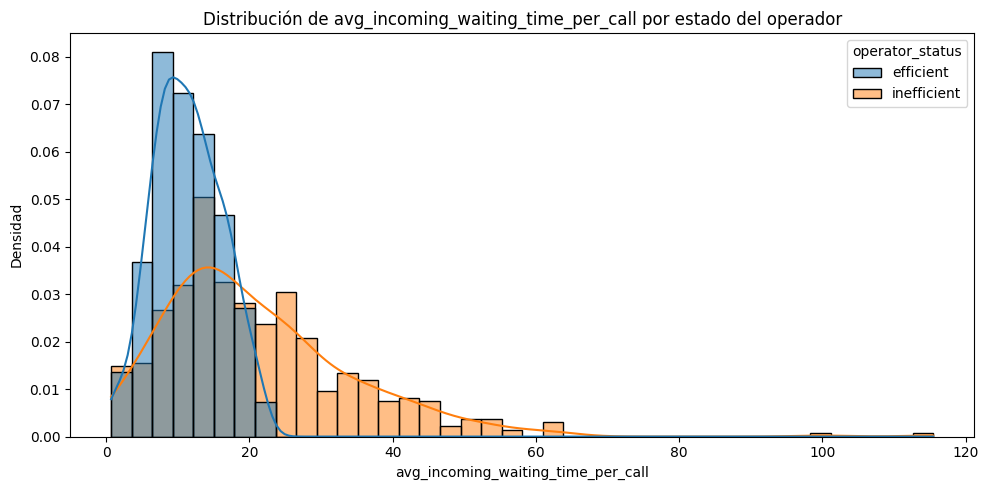

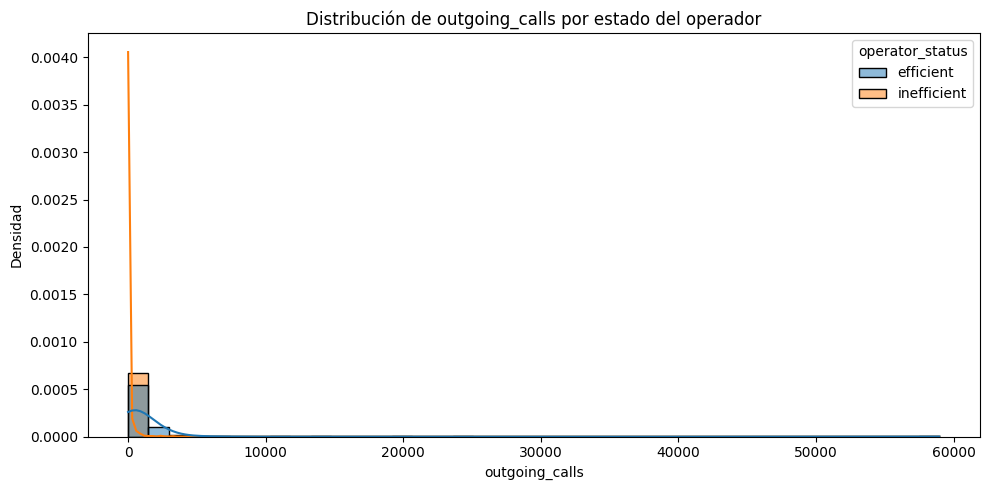

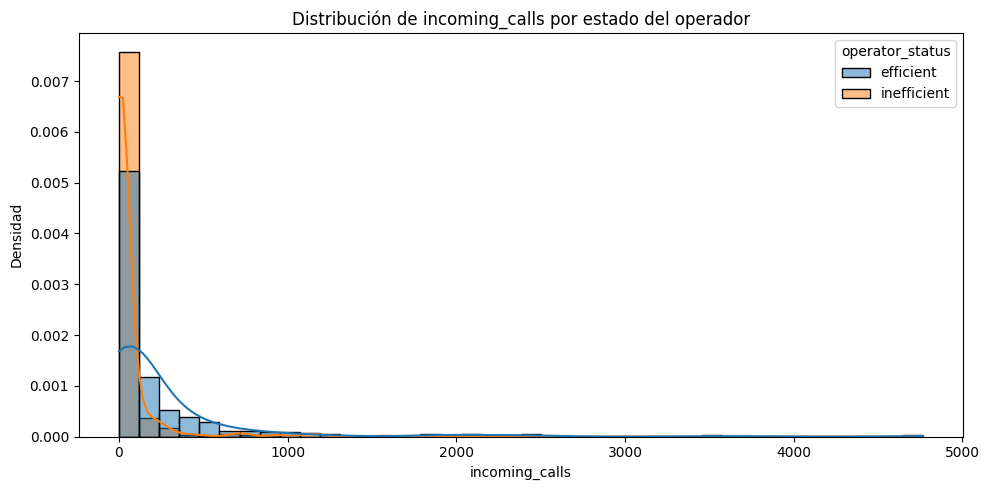

In [185]:
# Generamos histogramas comparativos para observar la distribución de cada métrica por grupo
for metric in metrics_to_compare:
    
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=operator_inefficiency_metrics,
        x=metric,
        hue='operator_status',
        bins=40,
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.5)
    
    plt.title(f'Distribución de {metric} por estado del operador')
    plt.xlabel(metric)
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

Los histogramas de densidad permiten comparar la distribución completa de las principales métricas operativas entre operadores clasificados como eficientes e ineficientes. Este tipo de visualización facilita identificar patrones de concentración, asimetrías y superposición entre grupos, proporcionando una visión más detallada del comportamiento de cada métrica dentro del sistema telefónico.

- Distribución de la tasa de llamadas entrantes perdidas (missed_incoming_rate)

La distribución de la tasa de llamadas entrantes perdidas muestra que los operadores eficientes concentran casi la totalidad de sus registros en valores muy cercanos a cero. Esto indica que la mayoría de operadores eficientes logran atender prácticamente todas las llamadas entrantes asignadas, manteniendo un desempeño estable y consistente.

En contraste, los operadores ineficientes presentan una distribución mucho más dispersa y con una cola derecha considerablemente más extensa. Esto evidencia la existencia de operadores con tasas elevadas de llamadas perdidas, incluyendo algunos casos extremos cercanos al 100%. Desde la perspectiva del negocio, este patrón refuerza que la pérdida frecuente de llamadas constituye una señal clara de bajo desempeño operativo y afecta directamente la calidad de atención al cliente.

- Distribución del tiempo promedio de espera (avg_incoming_waiting_time_per_call)

En el caso del tiempo promedio de espera, se observa una separación mucho más clara entre ambos grupos. Los operadores eficientes presentan una distribución relativamente concentrada en valores bajos y moderados, mientras que los operadores ineficientes muestran una distribución desplazada hacia la derecha, con tiempos promedio considerablemente mayores y una dispersión mucho más amplia.

Además, la presencia de valores extremos superiores a 100 minutos dentro del grupo ineficiente sugiere la existencia de operadores con problemas severos de disponibilidad o gestión de llamadas. Este resultado indica que el tiempo promedio de espera es una de las métricas más relevantes para identificar operadores potencialmente ineficaces y representa uno de los principales factores asociados al deterioro de la experiencia del cliente.

- Distribución del número de llamadas salientes (outgoing_calls)

La distribución del número de llamadas salientes presenta una fuerte asimetría positiva en ambos grupos, especialmente en operadores eficientes. Se observa que la mayoría de operadores concentran volúmenes relativamente bajos de llamadas salientes, mientras que un grupo reducido de operadores acumula valores extremadamente altos.

Los operadores eficientes muestran una cola derecha más extensa, alcanzando volúmenes de llamadas considerablemente superiores a los observados en operadores ineficientes. Esto podría reflejar la existencia de operadores especializados en actividades comerciales, seguimiento o campañas salientes.

Sin embargo, también se aprecia una fuerte superposición entre ambos grupos en valores bajos de llamadas salientes. Esto sugiere que esta métrica, aunque útil como criterio complementario, posee menor capacidad clasificadora que las métricas relacionadas con la calidad de atención, como llamadas perdidas o tiempos de espera.

- Distribución del número de llamadas entrantes (incoming_calls)

La distribución de llamadas entrantes también presenta una marcada asimetría positiva, con la mayoría de operadores concentrando bajos volúmenes de llamadas y unos pocos operadores acumulando cargas operativas muy elevadas.

Los operadores eficientes muestran una cola derecha significativamente más extensa, lo que indica que algunos operadores son capaces de gestionar grandes volúmenes de llamadas manteniendo niveles aceptables de desempeño. Por el contrario, los operadores ineficientes tienden a concentrarse en rangos más bajos de llamadas entrantes.

Este comportamiento es especialmente relevante para el objetivo del proyecto, ya que sugiere que la ineficiencia operacional no depende exclusivamente del volumen de llamadas atendidas. De hecho, algunos operadores eficientes gestionan mayores cargas operativas que operadores clasificados como ineficientes. Esto refuerza la idea de que los principales problemas de desempeño están más asociados a la calidad de gestión de llamadas que al nivel de actividad operativa en sí mismo.

- Evaluación general de las distribuciones

En conjunto, las distribuciones evidencian que las métricas relacionadas con la calidad de atención (principalmente la tasa de llamadas perdidas y el tiempo promedio de espera) son las que presentan diferencias más claras entre operadores eficientes e ineficientes. Por el contrario, las métricas de volumen de llamadas muestran una mayor superposición entre grupos y parecen actuar más como variables contextuales que como indicadores principales de bajo desempeño.

Asimismo, todas las métricas presentan distribuciones fuertemente asimétricas y presencia de valores extremos, lo cual sugiere que las futuras pruebas estadísticas deberían considerar metodologías robustas frente a no normalidad y alta dispersión de datos.

En términos operativos, los resultados respaldan el enfoque utilizado para identificar operadores ineficaces mediante múltiples indicadores complementarios, priorizando especialmente métricas relacionadas con tiempos de atención y pérdida de llamadas, que son las variables con mayor capacidad para diferenciar niveles de desempeño dentro del sistema telefónico.

In [186]:
# Calculamos diferencias absolutas entre las medias de operadores ineficientes y eficientes
comparison_summary = pd.DataFrame({
    'metric': metrics_to_compare,
    'efficient_mean': [
        efficient_operators[metric].mean() for metric in metrics_to_compare
    ],
    'inefficient_mean': [
        inefficient_operators[metric].mean() for metric in metrics_to_compare
    ],
    'absolute_difference': [
        inefficient_operators[metric].mean() - efficient_operators[metric].mean()
        for metric in metrics_to_compare
    ]})

# Calculamos la diferencia relativa respecto al promedio de operadores eficientes
comparison_summary['relative_difference_pct'] = (
    comparison_summary['absolute_difference'] /
    comparison_summary['efficient_mean'] *
    100)

comparison_summary

,metric,efficient_mean,inefficient_mean,absolute_difference,relative_difference_pct
0,missed_incoming_rate,0.004658,0.025379,0.020721,444.872626
1,avg_incoming_waiting_time_per_call,11.411299,21.165673,9.754374,85.479958
2,outgoing_calls,1135.336000,68.707770,-1066.628230,-93.948243
3,incoming_calls,237.383803,56.138298,-181.245505,-76.351252


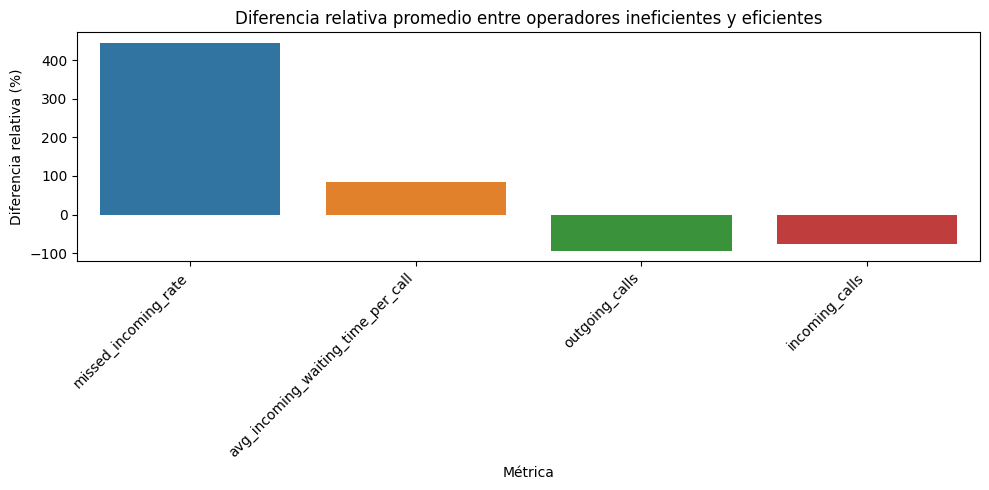

In [187]:
# Visualizamos las diferencias relativas entre operadores ineficientes y eficientes
plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_summary,
    x='metric',
    y='relative_difference_pct')

plt.title('Diferencia relativa promedio entre operadores ineficientes y eficientes')
plt.xlabel('Métrica')
plt.ylabel('Diferencia relativa (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El gráfico muestra la diferencia relativa promedio entre operadores clasificados como ineficientes y eficientes para las principales métricas operativas analizadas. Esta visualización permite cuantificar de forma comparativa cuánto difieren ambos grupos en términos porcentuales y facilita identificar qué variables presentan las mayores brechas de desempeño.

La diferencia más significativa se observa en la tasa de llamadas entrantes perdidas (missed_incoming_rate). Los operadores ineficientes presentan una tasa promedio aproximadamente 440% superior a la de los operadores eficientes. Este resultado evidencia que la pérdida de llamadas constituye el principal factor diferenciador entre ambos grupos y refuerza la importancia de esta métrica dentro del modelo de identificación de operadores ineficaces.

Desde la perspectiva del negocio, este hallazgo es especialmente relevante porque las llamadas perdidas representan una afectación directa sobre la calidad del servicio y la experiencia del cliente. Una alta proporción de llamadas no atendidas puede generar pérdida de oportunidades comerciales, incremento de insatisfacción y deterioro de la percepción del servicio telefónico.

La segunda diferencia positiva más importante corresponde al tiempo promedio de espera por llamada entrante (avg_incoming_waiting_time_per_call), donde los operadores ineficientes presentan valores aproximadamente un 80% superiores a los de los operadores eficientes. Esto indica que los operadores clasificados como problemáticos no solo pierden más llamadas, sino que también generan mayores tiempos de espera antes de atender las interacciones que sí son gestionadas.

En conjunto, ambas métricas (llamadas perdidas y tiempo de espera) muestran diferencias considerablemente superiores respecto a las demás variables analizadas. Esto sugiere que la ineficiencia operacional se encuentra principalmente asociada a problemas de calidad y velocidad de atención más que al simple volumen de actividad.

Por otro lado, las métricas relacionadas con la cantidad de llamadas (outgoing_calls e incoming_calls) presentan diferencias relativas negativas. Los operadores ineficientes registran menores volúmenes promedio tanto de llamadas salientes como de entrantes respecto a los operadores eficientes. En particular, la reducción en llamadas entrantes es cercana al 80%, mientras que la disminución en llamadas salientes ronda aproximadamente el 90%.

Estos resultados son especialmente importantes porque indican que los operadores ineficientes no necesariamente están asociados a una sobrecarga operativa. De hecho, muchos de ellos gestionan menores volúmenes de llamadas y aun así presentan peores indicadores de desempeño. Esto respalda nuevamente la idea de que la ineficiencia detectada parece estar más relacionada con la calidad de gestión operativa que con la cantidad de actividad atendida.

Asimismo, la menor cantidad de llamadas salientes observada en operadores ineficientes podría reflejar menor productividad operativa o menor participación en actividades de comunicación activa. Sin embargo, esta métrica debe interpretarse con cautela debido a posibles diferencias funcionales entre operadores.

En términos generales, el gráfico confirma que las métricas más útiles para identificar operadores potencialmente ineficaces son aquellas relacionadas con la experiencia de atención del cliente, especialmente:
- Tasa de llamadas perdidas.
- Tiempo promedio de espera.

Por el contrario, las métricas de volumen de llamadas parecen funcionar más como indicadores contextuales complementarios y presentan menor capacidad clasificadora respecto al desempeño operativo.

En conjunto, los resultados fortalecen la validez del enfoque utilizado en el proyecto para detectar operadores ineficaces mediante múltiples métricas complementarias, priorizando principalmente indicadores de calidad de atención y eficiencia operativa.

En esta sección se compararon las principales métricas operativas entre operadores clasificados como eficientes e ineficientes. El objetivo fue verificar si los grupos presentan diferencias relevantes en tasa de llamadas entrantes perdidas, tiempo promedio de espera, número de llamadas salientes y volumen de llamadas entrantes.

Esta comparación permite preparar la validación estadística posterior, ya que ayuda a identificar qué métricas muestran diferencias visibles entre grupos y cuáles podrían requerir pruebas de hipótesis para determinar si las diferencias observadas son estadísticamente significativas.

### 6.2. Selección de pruebas estadísticas

Se elegirá la prueba estadística adecuada según la naturaleza y distribución de los datos. Si los supuestos paramétricos no se cumplen, se recurrirá a pruebas no paramétricas.

In [188]:
# Definimos las métricas que serán evaluadas estadísticamente
# Estas métricas son las principales variables utilizadas para comparar operadores eficientes e ineficientes

metrics_to_test = [
    'missed_incoming_rate',
    'avg_incoming_waiting_time_per_call',
    'outgoing_calls',
    'incoming_calls'
]

In [189]:
# Creamos una función para evaluar normalidad usando Shapiro-Wilk
# Esta prueba permite revisar si una distribución se aproxima a una distribución normal

normality_results = []

for metric in metrics_to_test:
    
    # Separamos los valores de operadores eficientes e ineficientes
    efficient_values = efficient_operators[metric].dropna()
    inefficient_values = inefficient_operators[metric].dropna()
    
    # Aplicamos prueba de Shapiro-Wilk para operadores eficientes
    stat_eff, p_eff = st.shapiro(efficient_values)
    
    # Aplicamos prueba de Shapiro-Wilk para operadores ineficientes
    stat_ineff, p_ineff = st.shapiro(inefficient_values)
    
    # Guardamos los resultados en una lista
    normality_results.append({
        'metric': metric,
        'group': 'efficient',
        'shapiro_statistic': stat_eff,
        'p_value': p_eff,
        'normal_distribution': p_eff > 0.05
    })
    
    normality_results.append({
        'metric': metric,
        'group': 'inefficient',
        'shapiro_statistic': stat_ineff,
        'p_value': p_ineff,
        'normal_distribution': p_ineff > 0.05
    })

# Convertimos los resultados en dataframe
normality_results = pd.DataFrame(normality_results)

normality_results

,metric,group,shapiro_statistic,p_value,normal_distribution
0,missed_incoming_rate,efficient,0.658970,1.705669e-23,False
1,missed_incoming_rate,inefficient,0.340363,6.646213e-38,False
2,avg_incoming_waiting_time_per_call,efficient,0.988607,2.485427e-02,False
3,avg_incoming_waiting_time_per_call,inefficient,0.893429,1.499326e-17,False
4,outgoing_calls,efficient,0.195944,1.309093e-41,False
5,outgoing_calls,inefficient,0.214291,4.344025e-44,False
6,incoming_calls,efficient,0.463478,2.365025e-28,False
7,incoming_calls,inefficient,0.341495,7.008395e-38,False


In [190]:
# Evaluamos homogeneidad de varianzas usando la prueba de Levene
# Esta prueba permite revisar si ambos grupos tienen varianzas similares

variance_results = []

for metric in metrics_to_test:
    
    # Separamos los valores de operadores eficientes e ineficientes
    efficient_values = efficient_operators[metric].dropna()
    inefficient_values = inefficient_operators[metric].dropna()
    
    # Aplicamos prueba de Levene
    stat_levene, p_levene = st.levene(efficient_values, inefficient_values)
    
    # Guardamos los resultados
    variance_results.append({
        'metric': metric,
        'levene_statistic': stat_levene,
        'p_value': p_levene,
        'equal_variances': p_levene > 0.05
    })

# Convertimos los resultados en dataframe
variance_results = pd.DataFrame(variance_results)

variance_results

,metric,levene_statistic,p_value,equal_variances
0,missed_incoming_rate,18.219051,2.220789e-05,False
1,avg_incoming_waiting_time_per_call,109.259141,5.698090e-24,False
2,outgoing_calls,32.323239,1.675237e-08,False
3,incoming_calls,43.109340,9.649394e-11,False


In [191]:
# Consolidamos los resultados de normalidad y varianza para tomar una decisión metodológica
# Si las distribuciones no son normales, será más adecuado usar una prueba no paramétrica

test_selection_summary = variance_results.copy()

test_selection_summary['normality_efficient'] = [
    normality_results[
        (normality_results['metric'] == metric) &
        (normality_results['group'] == 'efficient')
    ]['normal_distribution'].iloc[0]
    for metric in test_selection_summary['metric']
]

test_selection_summary['normality_inefficient'] = [
    normality_results[
        (normality_results['metric'] == metric) &
        (normality_results['group'] == 'inefficient')
    ]['normal_distribution'].iloc[0]
    for metric in test_selection_summary['metric']
]

# Definimos la prueba recomendada según los resultados
test_selection_summary['recommended_test'] = np.where(
    (test_selection_summary['normality_efficient']) &
    (test_selection_summary['normality_inefficient']) &
    (test_selection_summary['equal_variances']),
    't-test',
    'Mann-Whitney U'
)

test_selection_summary

,metric,levene_statistic,p_value,equal_variances,normality_efficient,normality_inefficient,recommended_test
0,missed_incoming_rate,18.219051,2.220789e-05,False,False,False,Mann-Whitney U
1,avg_incoming_waiting_time_per_call,109.259141,5.698090e-24,False,False,False,Mann-Whitney U
2,outgoing_calls,32.323239,1.675237e-08,False,False,False,Mann-Whitney U
3,incoming_calls,43.109340,9.649394e-11,False,False,False,Mann-Whitney U


In [192]:
# Mostramos de forma resumida cuántas métricas cumplen o no los supuestos paramétricos
test_selection_summary['recommended_test'].value_counts()

Mann-Whitney U    4
Name: recommended_test, dtype: int64

Para seleccionar la prueba estadística adecuada, se evaluaron los supuestos de normalidad y homogeneidad de varianzas en las métricas principales comparadas entre operadores eficientes e ineficientes.

Dado que las distribuciones observadas en el análisis exploratorio presentan asimetría, valores extremos y diferencias importantes de dispersión entre grupos, se verificó formalmente la normalidad mediante la prueba de Shapiro-Wilk y la igualdad de varianzas mediante la prueba de Levene.

En caso de que las métricas no cumplan los supuestos paramétricos, se utilizará la prueba no paramétrica de Mann-Whitney U para comparar ambos grupos. Esta prueba resulta adecuada porque permite evaluar diferencias entre dos grupos independientes sin asumir normalidad en las distribuciones.

En este caso, para las 4 métricas se llegó a la recomendación de usar la prueba no paramétrica de Mann-Whitney U.

### 6.3. Interpretación de resultados

Se interpretarán los resultados de las pruebas estadísticas, evaluando si existe evidencia suficiente para apoyar o rechazar las hipótesis planteadas.

In [193]:
# Definimos el nivel de significancia para las pruebas estadísticas
# Usaremos alpha = 0.05 como criterio convencional para rechazar o no rechazar la hipótesis nula

alpha = 0.05

# Dado que se compararán varias métricas, aplicamos corrección de Bonferroni
# Esto reduce el riesgo de obtener falsos positivos por realizar múltiples pruebas

n_tests = len(metrics_to_test)

alpha_bonferroni = alpha / n_tests

print('Nivel de significancia original:', alpha)
print('Número de pruebas:', n_tests)
print('Nivel de significancia ajustado por Bonferroni:', alpha_bonferroni)

Nivel de significancia original: 0.05
Número de pruebas: 4
Nivel de significancia ajustado por Bonferroni: 0.0125


In [194]:
# Aplicamos la prueba de Mann-Whitney U para comparar operadores eficientes e ineficientes
# Esta prueba fue seleccionada porque las métricas no cumplen normalidad ni homogeneidad de varianzas

mannwhitney_results = []

for metric in metrics_to_test:
    
    # Extraemos los valores de la métrica para operadores eficientes
    efficient_values = efficient_operators[metric].dropna()
    
    # Extraemos los valores de la métrica para operadores ineficientes
    inefficient_values = inefficient_operators[metric].dropna()
    
    # Aplicamos la prueba Mann-Whitney U con hipótesis bilateral
    # H0: Las distribuciones de los operadores eficientes e ineficientes son iguales
    # H1: Las distribuciones de los operadores eficientes e ineficientes son diferentes
    statistic, p_value = st.mannwhitneyu(
        efficient_values,
        inefficient_values,
        alternative='two-sided'    )
    
    # Guardamos los resultados en una lista
    mannwhitney_results.append({
        'metric': metric,
        'u_statistic': statistic,
        'p_value': p_value,
        'significant_alpha_0_05': p_value < alpha,
        'significant_bonferroni': p_value < alpha_bonferroni,
        'efficient_median': efficient_values.median(),
        'inefficient_median': inefficient_values.median(),
        'efficient_mean': efficient_values.mean(),
        'inefficient_mean': inefficient_values.mean()
    })

# Convertimos los resultados en dataframe
mannwhitney_results = pd.DataFrame(mannwhitney_results)

mannwhitney_results

,metric,u_statistic,p_value,significant_alpha_0_05,significant_bonferroni,efficient_median,inefficient_median,efficient_mean,inefficient_mean
0,missed_incoming_rate,68664.5,4.212134e-01,False,False,0.0,0.000000,0.004658,0.025379
1,avg_incoming_waiting_time_per_call,33996.0,1.327581e-29,True,True,11.0,18.220513,11.411299,21.165673
2,outgoing_calls,276851.5,6.250124e-137,True,True,345.0,2.000000,1135.336000,68.707770
3,incoming_calls,97753.5,8.838591e-27,True,True,60.0,8.000000,237.383803,56.138298


In [195]:
# Calculamos diferencias entre medianas para complementar la interpretación estadística
# La mediana es útil porque las distribuciones presentan asimetría y valores atípicos

mannwhitney_results['median_difference'] = (
    mannwhitney_results['inefficient_median'] -
    mannwhitney_results['efficient_median'])

mannwhitney_results['mean_difference'] = (
    mannwhitney_results['inefficient_mean'] -
    mannwhitney_results['efficient_mean'])

mannwhitney_results

,metric,u_statistic,p_value,significant_alpha_0_05,significant_bonferroni,efficient_median,inefficient_median,efficient_mean,inefficient_mean,median_difference,mean_difference
0,missed_incoming_rate,68664.5,4.212134e-01,False,False,0.0,0.000000,0.004658,0.025379,0.000000,0.020721
1,avg_incoming_waiting_time_per_call,33996.0,1.327581e-29,True,True,11.0,18.220513,11.411299,21.165673,7.220513,9.754374
2,outgoing_calls,276851.5,6.250124e-137,True,True,345.0,2.000000,1135.336000,68.707770,-343.000000,-1066.628230
3,incoming_calls,97753.5,8.838591e-27,True,True,60.0,8.000000,237.383803,56.138298,-52.000000,-181.245505


In [196]:
# Creamos una columna de interpretación automática para facilitar la lectura de resultados
mannwhitney_results['decision'] = np.where(
    mannwhitney_results['significant_bonferroni'],
    'Se rechaza H0',
    'No se rechaza H0')

mannwhitney_results['interpretation'] = np.where(
    mannwhitney_results['significant_bonferroni'],
    'Diferencia estadísticamente significativa entre operadores eficientes e ineficientes',
    'No hay evidencia estadística suficiente de diferencia entre grupos')

mannwhitney_results

,metric,u_statistic,p_value,significant_alpha_0_05,significant_bonferroni,efficient_median,inefficient_median,efficient_mean,inefficient_mean,median_difference,mean_difference,decision,interpretation
0,missed_incoming_rate,68664.5,4.212134e-01,False,False,0.0,0.000000,0.004658,0.025379,0.000000,0.020721,No se rechaza H0,No hay evidencia estadística suficiente de dif...
1,avg_incoming_waiting_time_per_call,33996.0,1.327581e-29,True,True,11.0,18.220513,11.411299,21.165673,7.220513,9.754374,Se rechaza H0,Diferencia estadísticamente significativa entr...
2,outgoing_calls,276851.5,6.250124e-137,True,True,345.0,2.000000,1135.336000,68.707770,-343.000000,-1066.628230,Se rechaza H0,Diferencia estadísticamente significativa entr...
3,incoming_calls,97753.5,8.838591e-27,True,True,60.0,8.000000,237.383803,56.138298,-52.000000,-181.245505,Se rechaza H0,Diferencia estadísticamente significativa entr...


In [197]:
# Ordenamos los resultados por p-value para identificar las métricas con diferencias más fuertes

mannwhitney_results_sorted = (
    mannwhitney_results
    .sort_values('p_value')
    .reset_index(drop=True))

mannwhitney_results_sorted

,metric,u_statistic,p_value,significant_alpha_0_05,significant_bonferroni,efficient_median,inefficient_median,efficient_mean,inefficient_mean,median_difference,mean_difference,decision,interpretation
0,outgoing_calls,276851.5,6.250124e-137,True,True,345.0,2.000000,1135.336000,68.707770,-343.000000,-1066.628230,Se rechaza H0,Diferencia estadísticamente significativa entr...
1,avg_incoming_waiting_time_per_call,33996.0,1.327581e-29,True,True,11.0,18.220513,11.411299,21.165673,7.220513,9.754374,Se rechaza H0,Diferencia estadísticamente significativa entr...
2,incoming_calls,97753.5,8.838591e-27,True,True,60.0,8.000000,237.383803,56.138298,-52.000000,-181.245505,Se rechaza H0,Diferencia estadísticamente significativa entr...
3,missed_incoming_rate,68664.5,4.212134e-01,False,False,0.0,0.000000,0.004658,0.025379,0.000000,0.020721,No se rechaza H0,No hay evidencia estadística suficiente de dif...


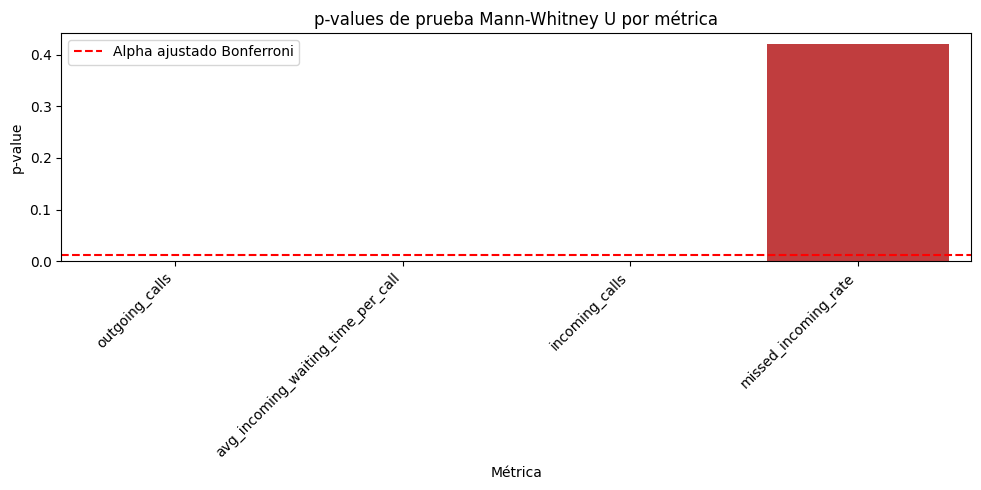

In [198]:
# Visualizamos los p-values de cada métrica frente al umbral ajustado por Bonferroni

plt.figure(figsize=(10, 5))

sns.barplot(
    data=mannwhitney_results_sorted,
    x='metric',
    y='p_value')

plt.axhline(
    alpha_bonferroni,
    linestyle='--',
    color='red',
    label='Alpha ajustado Bonferroni')

plt.title('p-values de prueba Mann-Whitney U por métrica')
plt.xlabel('Métrica')
plt.ylabel('p-value')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Se ha encontrado una diferencia estadísticamente significativa entre operadores eficientes e ineficientes en las métricas de: número de llamadas salientes, tiempo promedio de espera y cantidad de llamadas entrantes. En el caso de la tasa de llamadas entrantes perdidas no se encontró dicha diferencia significativa entre operadores eficientes e ineficientes (como se aprecia en el gráfico anterior).

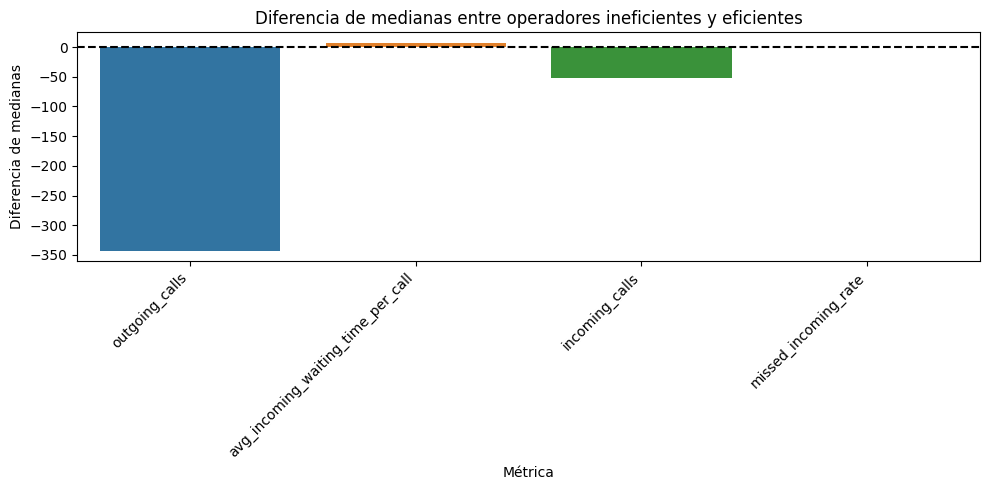

In [199]:
# Visualizamos la diferencia de medianas entre operadores ineficientes y eficientes
# Valores positivos indican que el grupo ineficiente tiene mayor mediana
# Valores negativos indican que el grupo ineficiente tiene menor mediana

plt.figure(figsize=(10, 5))

sns.barplot(
    data=mannwhitney_results_sorted,
    x='metric',
    y='median_difference')

plt.axhline(
    0,
    linestyle='--',
    color='black')

plt.title('Diferencia de medianas entre operadores ineficientes y eficientes')
plt.xlabel('Métrica')
plt.ylabel('Diferencia de medianas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El gráfico de barras muestra la diferencia de medianas entre operadores clasificados como ineficientes y eficientes para las principales métricas operativas evaluadas en el proyecto. Esta visualización complementa los resultados de la prueba estadística Mann-Whitney U, permitiendo interpretar no solo si existen diferencias significativas entre grupos, sino también la dirección y magnitud aproximada de dichas diferencias.

Inicialmente se observa que la mayor diferencia de medianas corresponde al número de llamadas salientes (outgoing_calls). La diferencia negativa indica que los operadores ineficientes presentan una mediana considerablemente menor de llamadas salientes respecto a los operadores eficientes. Esto sugiere que, en términos generales, los operadores clasificados como ineficaces realizan menos actividad saliente, lo cual podría reflejar menor productividad operativa o menor participación en tareas de contacto activo con clientes.

Asimismo, el número de llamadas entrantes (incoming_calls) también presenta una diferencia negativa importante. Los operadores ineficientes reciben o gestionan menos llamadas entrantes en comparación con los operadores eficientes. Este resultado es especialmente relevante porque evidencia nuevamente que la ineficiencia operacional no parece estar asociada a una sobrecarga de trabajo. Por el contrario, muchos operadores eficientes son capaces de gestionar mayores volúmenes de llamadas manteniendo mejores indicadores de desempeño.

Por otro lado, el tiempo promedio de espera por llamada entrante (avg_incoming_waiting_time_per_call) muestra una diferencia positiva entre grupos. Esto indica que los operadores ineficientes presentan tiempos de espera medianos superiores a los de los operadores eficientes, reforzando la idea de que los problemas de desempeño se relacionan principalmente con la calidad y velocidad de atención de llamadas.

En el caso de la tasa de llamadas entrantes perdidas (missed_incoming_rate), la diferencia visual de medianas parece relativamente pequeña respecto a las demás métricas. Sin embargo, esto no implica necesariamente ausencia de diferencias operativas relevantes. Dado que gran parte de los operadores concentra valores cercanos a cero, pequeñas variaciones en la mediana pueden coexistir con diferencias importantes en la dispersión y presencia de valores extremos, tal como se observó en los análisis exploratorios anteriores.

Desde una perspectiva metodológica, el uso de medianas resulta apropiado debido a la fuerte asimetría y presencia de valores atípicos en las distribuciones analizadas. La mediana proporciona una medida más robusta del comportamiento central de cada grupo y evita que los valores extremos distorsionen la comparación.

En conjunto, el gráfico respalda los hallazgos obtenidos en los análisis previos:
- Los operadores ineficientes presentan mayores tiempos de espera.
- Muestran menor actividad operativa tanto entrante como saliente.
- Mantienen patrones asociados a menor calidad de atención.

Estos resultados fortalecen la validez del enfoque utilizado para identificar operadores potencialmente ineficaces mediante múltiples métricas complementarias de desempeño operativo.

In [200]:
# Mostramos una tabla final con las columnas principales para la interpretación de los resultados obtenidos en las pruebas estadísticas
mannwhitney_results_final = mannwhitney_results_sorted[
    [
        'metric',
        'efficient_median',
        'inefficient_median',
        'median_difference',
        'p_value',
        'significant_bonferroni',
        'decision',
        'interpretation'
    ]]

mannwhitney_results_final

,metric,efficient_median,inefficient_median,median_difference,p_value,significant_bonferroni,decision,interpretation
0,outgoing_calls,345.0,2.000000,-343.000000,6.250124e-137,True,Se rechaza H0,Diferencia estadísticamente significativa entr...
1,avg_incoming_waiting_time_per_call,11.0,18.220513,7.220513,1.327581e-29,True,Se rechaza H0,Diferencia estadísticamente significativa entr...
2,incoming_calls,60.0,8.000000,-52.000000,8.838591e-27,True,Se rechaza H0,Diferencia estadísticamente significativa entr...
3,missed_incoming_rate,0.0,0.000000,0.000000,4.212134e-01,False,No se rechaza H0,No hay evidencia estadística suficiente de dif...


Se aplicó la prueba no paramétrica de Mann-Whitney U para comparar las distribuciones de las métricas operativas entre operadores eficientes e ineficientes. Esta prueba fue seleccionada debido a que las métricas no cumplen los supuestos de normalidad ni de homogeneidad de varianzas.

La hipótesis nula plantea que no existen diferencias significativas entre ambos grupos (operadores eficientes e ineficientes) para cada métrica evaluada. La hipótesis alternativa plantea que sí existen diferencias estadísticamente significativas entre operadores eficientes e ineficientes.

Dado que se realizaron varias pruebas estadísticas, se utilizó la corrección de Bonferroni para reducir el riesgo de falsos positivos. Por ello, las diferencias se consideran estadísticamente significativas únicamente cuando el p-value es menor al nivel de significancia ajustado.

## Paso 7. Conclusiones y recomendaciones

### 7.1. Identificación de hallazgos más importantes

Se resumirán los hallazgos principales del análisis, enfatizando qué métricas, segmentos o patrones fueron más relevantes para detectar operadores ineficaces.

El análisis realizado permitió identificar patrones operativos claros asociados al bajo desempeño de determinados operadores dentro del sistema telefónico de CallMeMaybe. Los resultados obtenidos muestran que las métricas con mayor capacidad para detectar operadores ineficaces fueron:

- El tiempo promedio de espera por llamada entrante.
- La tasa de llamadas entrantes perdidas.
- El bajo volumen de llamadas gestionadas.

Uno de los principales hallazgos del proyecto fue comprobar que los operadores clasificados como ineficientes presentan tiempos promedio de espera considerablemente superiores respecto a los operadores eficientes. Las pruebas estadísticas confirmaron que esta diferencia es estadísticamente significativa, lo que sugiere que los tiempos elevados de espera constituyen uno de los indicadores más importantes de deterioro operativo.

Asimismo, el análisis temporal mostró una tendencia creciente tanto en la tasa de llamadas perdidas como en la proporción de registros asociados a operadores ineficaces conforme avanzaban los meses analizados. Esto indica que la problemática operacional no corresponde a eventos aislados, sino a patrones persistentes que podrían intensificarse progresivamente si no se aplican medidas correctivas.

Un siguiente hallazgo relevante fue observar que los operadores ineficientes no necesariamente manejan mayores volúmenes de llamadas. Por el contrario, muchos operadores eficientes gestionan cantidades considerablemente más altas de llamadas entrantes y salientes manteniendo mejores niveles de desempeño. Este resultado permitió concluir que la ineficiencia operativa parece estar más asociada a la calidad de atención que a una simple sobrecarga de trabajo.

Además, se identificaron operadores con comportamientos extremadamente atípicos, incluyendo casos con tasas cercanas al 100% de llamadas perdidas y tiempos promedio de espera excepcionalmente elevados. Este tipo de comportamiento representa un riesgo importante para la calidad del servicio ofrecido a los clientes y podría generar impactos negativos sobre la satisfacción y retención de usuarios.

El enfoque utilizado en este análisis es consistente con investigaciones sobre desempeño en centros de atención telefónica, donde se señala que métricas como tiempo de espera, abandono de llamadas y calidad de respuesta representan indicadores críticos de eficiencia operacional. Por ejemplo, en el estudio desarrollado por Call Centre Helper (Key Call Center Metrics) se plantea que los tiempos de espera y llamadas perdidas son algunas de las métricas más relevantes para evaluar el desempeño operativo y la experiencia del cliente.

De forma complementaria, el análisis de cohortes permitió identificar que distintas generaciones de clientes presentan incrementos progresivos en la proporción de interacciones asociadas a operadores ineficaces. Este comportamiento sugiere que la problemática detectada afecta de forma relativamente transversal al sistema y no únicamente a determinados clientes o periodos específicos.

### 7.2. Identificación de acciones de mejora

Se plantearán posibles explicaciones de negocio para la ineficiencia observada, considerando el tipo de llamadas, la carga de trabajo, el cliente y otros factores analizados.

Los resultados obtenidos permiten plantear distintas posibles explicaciones operativas para los patrones de ineficiencia identificados en determinados operadores.

En primer lugar, los elevados tiempos promedio de espera observados en operadores ineficientes podrían estar relacionados con una distribución inadecuada de llamadas dentro del sistema telefónico. Algunos operadores podrían estar recibiendo llamadas de mayor complejidad o experimentar interrupciones operativas que reducen su capacidad de atención eficiente.

Asimismo, las altas tasas de llamadas perdidas podrían reflejar problemas asociados a:

- Disponibilidad insuficiente de operadores.
- Mala asignación de horarios.
- Sobrecarga puntual en determinados momentos del día.
- Limitaciones técnicas del sistema.
- Desconexiones o inactividad operativa.

También se observó que muchos operadores ineficientes presentan menores volúmenes de llamadas entrantes y salientes respecto a operadores eficientes. Esto podría indicar que ciertos operadores tienen baja participación operativa, problemas de productividad o dificultades para gestionar adecuadamente sus tareas asignadas.

De acuerdo con Talkdesk Research (Contact Center Performance Metrics), los problemas de tiempos elevados de espera y llamadas perdidas suelen estar relacionados con deficiencias en la asignación de recursos, monitoreo insuficiente y falta de optimización de carga operativa entre agentes.

Un siguiente aspecto relevante identificado durante el análisis es la fuerte presencia de valores extremos en determinadas métricas. Esto sugiere que la problemática operacional podría concentrarse en un subconjunto reducido de operadores con desempeños particularmente críticos, más que representar un problema homogéneo en toda la organización.

Además, el crecimiento progresivo de la proporción de registros asociados a operadores ineficaces podría indicar que actualmente no existen mecanismos suficientemente efectivos para detectar y corregir tempranamente deterioros en el desempeño operativo.

En línea con esto, Zendesk Blog (Call Center Quality Assurance Best Practices) destaca que la ausencia de monitoreo continuo y evaluación periódica de desempeño suele dificultar la detección temprana de operadores con bajo rendimiento, permitiendo que los problemas operativos se mantengan o intensifiquen con el tiempo.

### 7.3. Propuesta de acciones de mejora

Se propondrán recomendaciones concretas para reducir la ineficiencia, como redistribución de carga, revisión de procesos o entrenamiento de operadores.

A partir de los resultados obtenidos, se recomienda que CallMeMaybe implemente mecanismos permanentes de monitoreo operacional enfocados especialmente en:

- Tiempos promedio de espera.
- Llamadas entrantes perdidas.
- Desempeño individual de operadores.
- Comportamiento temporal de métricas operativas.

Una de las principales acciones recomendadas consiste en desarrollar un sistema automatizado de alertas tempranas capaz de detectar operadores cuyos indicadores se desvíen significativamente respecto a parámetros históricos o promedios generales del sistema. Esto permitiría intervenir rápidamente antes de que los problemas operativos afecten de manera importante la calidad del servicio.

Asimismo, se recomienda implementar revisiones focalizadas sobre operadores que presenten:

- Tasas persistentemente altas de llamadas perdidas.
- Tiempos excesivos de espera.
- Baja actividad operativa.
- Patrones atípicos recurrentes.

También sería recomendable analizar la distribución de carga operativa entre operadores para identificar posibles desequilibrios en la asignación de llamadas o diferencias significativas en la complejidad de atención.

De acuerdo con Five9 (Call Center Workforce Management), la optimización de carga de trabajo y el monitoreo continuo de desempeño son factores fundamentales para reducir tiempos de espera y mejorar productividad dentro de centros de atención telefónica.

Se propone también como acción importante utilizar a los operadores eficientes como referencia de buenas prácticas operativas. Aquellos operadores que logran gestionar altos volúmenes de llamadas manteniendo bajos niveles de espera y llamadas perdidas podrían servir como modelo para procesos de capacitación interna.

Además, sería recomendable complementar futuros análisis incorporando variables adicionales como:

- Horarios de llamadas.
- Duración promedio de atención.
- Complejidad de interacciones.
- Experiencia del operador.
- Tipo de cliente atendido.

Esto permitiría construir modelos más precisos de desempeño operacional y generar sistemas predictivos de detección de ineficiencia.

### 7.4. Implicancias para el negocio

Se explicará cómo los resultados pueden ayudar a CallMeMaybe a mejorar la calidad del servicio, reducir llamadas perdidas y apoyar a supervisores en la toma de decisiones.

Los resultados obtenidos tienen implicancias importantes para CallMeMaybe desde la perspectiva de calidad de servicio, experiencia del cliente y eficiencia operativa.

El análisis desarrollado proporciona una metodología cuantitativa para detectar operadores potencialmente ineficaces utilizando múltiples métricas complementarias. Esto permite transformar grandes volúmenes de registros operativos en información accionable para supervisores y responsables de gestión.

Asimismo, la identificación temprana de operadores con altos tiempos de espera o elevadas tasas de llamadas perdidas podría ayudar a reducir:

- Pérdida de oportunidades comerciales.
- Abandono de llamadas.
- Insatisfacción de clientes.
- Deterioro de la experiencia de atención.

Según HubSpot (Customer Service Metrics Guide), las métricas como el tiempo de espera y el abandono de llamadas tienen una relación directa con la percepción de la calidad del servicio y la satisfacción del cliente en sistemas de atención telefónica.

Además, los resultados muestran que la eficiencia operativa no depende exclusivamente del volumen de llamadas atendidas. Esto tiene implicancias importantes para la gestión interna, ya que evita penalizar automáticamente a operadores con alta carga operativa y permite enfocar las evaluaciones en indicadores reales de calidad de atención.

El análisis también demuestra el valor del monitoreo temporal y del análisis de cohortes para detectar deterioros progresivos en el desempeño operativo. La tendencia creciente observada en registros asociados a operadores ineficaces sugiere que la empresa podría beneficiarse significativamente de implementar estrategias preventivas de seguimiento continuo.

Finalmente, este tipo de análisis podría convertirse en la base para futuros sistemas de inteligencia operacional, dashboards automáticos o modelos predictivos orientados a optimizar la asignación de llamadas y mejorar la experiencia global de atención telefónica.

### 7.5. Idea final para el cierre del análisis

Se cerrará el documento con una síntesis del valor del análisis y de cómo la identificación de operadores ineficaces puede convertirse en una herramienta útil para la mejora operativa del servicio.

El presente proyecto permitió demostrar cómo el análisis de datos puede utilizarse para transformar registros operativos complejos en herramientas útiles para la toma de decisiones dentro de sistemas de atención telefónica.

A través del análisis exploratorio, evaluación temporal, análisis de cohortes y validación estadística, fue posible identificar patrones claros asociados al bajo desempeño de determinados operadores. Los resultados evidenciaron que la ineficiencia operacional se encuentra principalmente relacionada con:

- Tiempos elevados de espera.
- Llamadas entrantes perdidas.
- Problemas de calidad de atención, más que con el simple volumen de llamadas gestionadas.

Además, el proyecto permitió construir una metodología replicable para clasificar operadores potencialmente ineficaces mediante múltiples indicadores complementarios. Este enfoque resulta especialmente valioso porque evita depender de una única métrica y proporciona una visión más robusta del desempeño operativo.

Tal como señalan investigaciones sobre gestión de centros de atención telefónica, la utilización de métricas operativas para monitoreo continuo permite mejorar productividad, calidad de servicio y satisfacción del cliente. En este sentido, Genesys (Call Center Performance Metrics) destaca que los sistemas de monitoreo basados en indicadores operativos representan herramientas clave para optimizar procesos de atención y detectar tempranamente problemas de desempeño.

En conclusión, el análisis desarrollado no solo permite identificar operadores ineficaces, sino que también proporciona información estratégica para implementar mejoras operativas, optimizar recursos y fortalecer la calidad del servicio ofrecido por CallMeMaybe.

## Bibliografía
Call Centre Helper. (s.f.). Top call center metrics. Recuperado de Call Centre Helper - Key Call Center Metrics

Five9. (s.f.). Call center workforce management. Recuperado de Five9 - Call Center Workforce Management

Genesys. (s.f.). Call center metrics and KPIs. Recuperado de Genesys - Call Center Performance Metrics

HubSpot. (s.f.). Customer service metrics guide. Recuperado de HubSpot - Customer Service Metrics Guide

Talkdesk. (s.f.). Contact center performance metrics. Recuperado de Talkdesk Research - Contact Center Performance Metrics

Zendesk. (s.f.). Call center quality assurance best practices. Recuperado de Zendesk Blog - Call Center Quality Assurance Best Practices